# Quantum state tomography — linear inversion, least squares and maximum likelihood

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 8 — Quantum information protocols*

## 1. Introduction and motivation

The protocols of notebooks 19–22 all *started* from a known state: we prepared $|\psi\rangle$ or $\rho$ with a circuit and then
computed what the parties would observe. An experiment faces the reverse problem. A laboratory builds a device that is *supposed*
to prepare a Bell pair, a GHZ state or the output of a parametrised circuit, and then has to determine **which state it actually
prepared**. One run cannot answer this, because a measurement returns a single bit string and disturbs the state; the device must
be run many times. The only access is the one described in [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb):
choose a measurement axis for every qubit, run the device, read out a string of $N$ bits, repeat. From those click statistics the
full density matrix must be *reconstructed*. That reconstruction problem is **quantum state tomography** (QST).

It is the standard acceptance test of every quantum device. "We prepared a three-qubit GHZ state with fidelity $0.97$" is a
statement produced by tomography. It is also the place where a physicist meets, usually for the first time, a genuine
**statistical estimation problem**: the data are random, the model is linear but constrained, the naive estimator returns
something that is not a quantum state at all, and the fix for that introduces a bias. All of this is ordinary statistics — and all
of it has a specifically quantum twist, because the parameter we estimate must be a positive semi-definite matrix, one without
negative eigenvalues.

**What we will do.** We build the whole pipeline from scratch and validate every piece.

1. **The model.** Expand the density matrix in Pauli strings (tensor products of $\mathbb 1,X,Y,Z$),
   $\rho=2^{-N}\sum_P\langle P\rangle\,P$, count the $4^N-1$ real parameters and the $3^N$ measurement settings needed to pin them
   down (Sections 3–4).
2. **The data.** Simulate the experiment with the einsum engine: rotate the density tensor into the measurement basis, sample bit
   strings, `vmap` over settings and over shots, explicit PRNG keys (Section 5).
3. **Linear-regression tomography.** Write the measurement model as a linear map $p=A\,r$ from the Pauli vector $r$ of expectation
   values to the outcome probabilities $p$, build the **design matrix** $A$ explicitly for $N=1$ and $N=2$, discover its Kronecker
   structure, and solve the normal equations. Show that ordinary least squares is *exactly* the "direct inversion" of Pauli
   expectation values, derive the statistical error bars analytically and check them by Monte Carlo, and add weighted least
   squares (Sections 6–9).
4. **Unphysical estimates.** Linear inversion regularly returns a matrix with **negative eigenvalues** — not a quantum state. We
   measure how often, and repair it by the eigenvalue-truncation projection of Smolin, Gambetta and Smith (Sections 10–11).
5. **Maximum-likelihood tomography.** Write the multinomial likelihood, derive the extremal equation $R\rho R=\rho$, implement the
   iterative $R\rho R$ algorithm and its *diluted* variant with convergence monitoring, then solve the *same* problem by gradient
   ascent with `jax.grad` and Adam on the Cholesky parametrisation $\rho=T^\dagger T/\mathrm{Tr}(T^\dagger T)$, and check that the
   two agree (Sections 12–14).
6. **Assessment.** Fidelity and trace distance versus the number of shots with **bootstrap** error bars, obtained by resampling a
   single data set; linear inversion versus projected linear inversion versus maximum likelihood on pure (Bell, GHZ, W), mixed
   (Werner, noisy GHZ) and random states; the bias of maximum likelihood at the boundary of the state space; and finally the cost
   wall ($3^N$ settings, and a total shot budget that grows like $5^N$ at fixed accuracy) that makes full tomography hopeless
   beyond a handful of qubits — which is why the next notebook replaces it by
   [24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb) (Sections 15–18).

### What you will learn

*Physics*

* informational completeness: why $3^N$ Pauli settings determine a state and what "determine" means statistically;
* the Pauli/Bloch representation of a density matrix and the physical meaning of its $4^N-1$ coordinates;
* why a positive semi-definite estimate matters, what a rank-deficient estimate means, and why the most likely state of a
  *pure* source is systematically *less* pure than the truth;
* how many shots a fidelity of, say, $0.99\pm0.01$ actually costs.

*Numerical methods*

* linear least squares: design matrix, normal equations, pseudo-inverse, Gram matrix, weighted least squares, error propagation;
* projection onto a convex set (the simplex of eigenvalues) and what it does to bias and variance;
* maximum likelihood for a constrained parameter: fixed-point iteration ($R\rho R$), dilution for monotone convergence,
  and first-order optimisation of a reparametrised cost;
* the bootstrap: error bars from one data set;
* exponential cost scaling and how to recognise a wall before you hit it.

*Implementation practice*

* `vmap` over measurement settings, over shots, over independent data sets, and over bootstrap resamples;
* `lax.scan` for a fixed-point iteration and for a training loop, with per-iteration diagnostics;
* `jax.grad` through an eigen-decomposition-free cost, Adam from the engine;
* turning a "sum over POVM elements" into a single einsum;
* validating a stochastic estimator: infinite-shot limit, equivalence of two derivations, monotone likelihood,
  agreement of two independent optimisers.

### Prerequisites
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, `grad`, PRNG keys;
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): index notation as executable code;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, partial trace, Kraus channels, fidelity, trace distance;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, basis rotations, sampling bit strings, shot noise;
* helpful: [19 — Bell states and CHSH](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb) and
  [22 — GHZ states and decoherence](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb) for the states we reconstruct.

**Conventions.** Qubit $q$ = tensor axis $q$; $|0\rangle$ is the $+1$ eigenstate of $Z$; a measurement outcome $s_q\in\{0,1\}$ means
eigenvalue $(-1)^{s_q}$; bit strings and Pauli strings are written with qubit $0$ leftmost (most significant digit of the flat index).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

We reuse the state constructors, `apply_gate`/`apply_gate_dm` (the einsum that applies a small matrix to chosen axes of a state or
density tensor), the Kraus channels, the fidelity and the trace distance. Everything specific to tomography is built below from scratch.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string_dm(rho, ops):
    """Tr(P rho): apply P to the KET axes only, then take the full trace."""
    return jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, ops))))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def fidelity_dm(rho, sigma):
    """Uhlmann fidelity F(rho,sigma) = (Tr sqrt( sqrt(rho) sigma sqrt(rho) ))^2 for dense matrices."""
    s = _sqrtm_psd(rho)
    w = jnp.linalg.eigvalsh(s @ sigma @ s)
    return jnp.sum(jnp.sqrt(jnp.clip(w, 0, None))) ** 2

def trace_distance(rho, sigma):
    """D = (1/2)||rho - sigma||_1 = (1/2) sum_i |eigenvalue_i(rho - sigma)|  (Hermitian difference)."""
    return 0.5 * jnp.sum(jnp.abs(jnp.linalg.eigvalsh(rho - sigma)))

def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
import itertools

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def dm_tensor(mat, N):
    """Inverse of `dm_matrix`: view a 2^N x 2^N matrix as a rank-2N density tensor (ket axes 0..N-1, bra axes N..2N-1)."""
    return jnp.asarray(mat, dtype=CDTYPE).reshape((2,) * (2 * N))


def mixed_with_identity(rho_mat, p):
    """p * rho + (1-p) * 1/d  -- the standard one-parameter family interpolating to the maximally mixed state."""
    d = rho_mat.shape[0]
    return p * rho_mat + (1 - p) * jnp.eye(d, dtype=CDTYPE) / d

## 3. Theory I: the Pauli (Bloch) representation of a density matrix

### 3.1 What has to be estimated

A state of $N$ qubits is a density matrix $\rho$ of size $d\times d$ with $d=2^N$, subject to three conditions:
$\rho=\rho^\dagger$ (Hermitian), $\mathrm{Tr}\,\rho=1$ (normalised), $\rho\succeq0$ (positive semi-definite, i.e. no negative eigenvalues).
A Hermitian $d\times d$ matrix has $d^2$ real parameters; the trace condition removes one, so

$$\#\text{parameters}=d^2-1=4^N-1 .$$

For $N=1$ that is $3$ (the Bloch vector), for $N=2$ it is $15$, for $N=5$ already $1023$, for $N=10$ more than a million.
**Positivity is an inequality** and removes no parameters; it carves out a convex body inside the
$(4^N-1)$-dimensional affine space of Hermitian unit-trace matrices. Pure states sit on its *boundary*, and that boundary is the
source of most subtleties later in this notebook.

### 3.2 Pauli strings as a basis

A convenient coordinate system is the set of **Pauli strings**

$$P=\sigma^{(0)}_{p_0}\otimes\sigma^{(1)}_{p_1}\otimes\cdots\otimes\sigma^{(N-1)}_{p_{N-1}},\qquad p_q\in\{I,X,Y,Z\},$$

of which there are $4^N$. They are Hermitian, they square to the identity, and they are **orthogonal** in the
Hilbert–Schmidt inner product $\langle A,B\rangle=\mathrm{Tr}(A^\dagger B)$:

$$\mathrm{Tr}(P\,P')=2^N\,\delta_{P,P'} .$$

*Proof.* $\mathrm{Tr}(A\otimes B)=\mathrm{Tr}A\;\mathrm{Tr}B$, so the trace factorises over qubits. On one qubit
$\mathrm{Tr}(\sigma_a\sigma_b)=2\delta_{ab}$ (check the four cases: $\sigma_a^2=\mathbb 1$ gives $2$; for $a\neq b$ the product is
$\pm i$ times the third Pauli or a traceless Pauli, hence traceless). Multiplying $N$ factors of $2\delta$ gives $2^N\delta_{P,P'}$. $\square$

Orthogonality means we can expand *any* $d\times d$ matrix in this basis, and read off the coefficients with a trace. For a density matrix,

$$\rho=\frac{1}{2^N}\sum_P r_P\,P,\qquad r_P=\mathrm{Tr}(\rho\,P)=\langle P\rangle . \tag{1}$$

*Proof of Eq. (1).* Write $\rho=\sum_{P'}c_{P'}P'$ (possible because the $4^N$ Pauli strings are $4^N$ linearly independent matrices
in a $4^N$-dimensional space). Multiply by $P$ and trace: $\mathrm{Tr}(\rho P)=\sum_{P'}c_{P'}\mathrm{Tr}(P'P)=2^Nc_P$. $\square$

The numbers $r_P$ are exactly the **expectation values** of the Pauli observables, which is what makes this basis physical:
every coordinate of the state is something an experiment can measure directly. The coefficient of the identity string is fixed,
$r_{II\ldots I}=\mathrm{Tr}\rho=1$, leaving the $4^N-1$ free parameters counted above. We call

$$r=(r_P)_{P}\in\mathbb{R}^{4^N}$$

the **Pauli vector** (for $N=1$ it is $(1,\langle X\rangle,\langle Y\rangle,\langle Z\rangle)$, i.e. the Bloch vector with a
leading 1). Tomography = estimate $r$.

> **Physics insight.** Positivity in Pauli coordinates is an ugly, non-local constraint: for $N=1$ it is the simple ball
> $\langle X\rangle^2+\langle Y\rangle^2+\langle Z\rangle^2\le1$, but already for $N=2$ the set of physical $r$ is a convex body
> in $\mathbb{R}^{15}$ with no elementary description. This is why "just measure all the Pauli expectation values" is not the end
> of the story.

### 3.3 Code: Pauli strings, the Pauli vector, and back

We index a Pauli string by a base-4 number: digit $p_q\in\{0,1,2,3\}=\{I,X,Y,Z\}$ for qubit $q$, with qubit 0 as the most significant
digit — the same convention as for bit strings. Building all $4^N$ dense matrices costs $O(4^N d^2)=O(16^N)$ memory, which is
fine for $N\le4$ (for $N=4$: $256$ matrices of size $16\times16$, about 1 MB) and is *inherent* to full tomography anyway.
Two einsums do the work:

* Pauli vector: $r_P=\mathrm{Tr}(P\rho)=\sum_{ab}P[a,b]\,\rho[b,a]$, i.e. `einsum("pab,ba->p", P_all, rho)`;
* reconstruction, Eq. (1): $\rho[a,b]=2^{-N}\sum_P r_P\,P[a,b]$, i.e. `einsum("p,pab->ab", r, P_all)`.

In [4]:
# ==============================================================================
# STEP 1: all 4^N Pauli strings, the Pauli vector r, and the inverse map r -> rho
# ==============================================================================
PAULI_LETTERS = "IXYZ"
_PAULI_CACHE = {}


def pauli_labels(N):
    """All 4^N Pauli-string labels as strings, ordered by the base-4 index (qubit 0 = most significant digit)."""
    return ["".join(p) for p in itertools.product(PAULI_LETTERS, repeat=N)]


def pauli_stack(N):
    """Dense array of all Pauli strings, shape (4^N, 2^N, 2^N).

    MATH   P = sigma_{p_0} (x) sigma_{p_1} (x) ... ;  Tr(P P') = 2^N delta_{PP'}.
    COST   O(16^N) memory -- acceptable only for small N, which is the regime where full tomography lives.
    """
    if N not in _PAULI_CACHE:
        mats = []
        for lab in pauli_labels(N):
            M = jnp.ones((1, 1), dtype=CDTYPE)
            for ch in lab:
                M = jnp.kron(M, PAULI[ch])
            mats.append(M)
        _PAULI_CACHE[N] = jnp.stack(mats)
    return _PAULI_CACHE[N]


def pauli_vector(rho_mat, N):
    """r_P = Tr(rho P) for all 4^N strings:  einsum("pab,ba->p", P_all, rho)  (real by Hermiticity)."""
    return jnp.real(jnp.einsum("pab,ba->p", pauli_stack(N), jnp.asarray(rho_mat, dtype=CDTYPE)))


def rho_from_pauli_vector(r, N):
    """Eq. (1):  rho = 2^{-N} sum_P r_P P  --  einsum("p,pab->ab", r, P_all) / 2^N."""
    return jnp.einsum("p,pab->ab", jnp.asarray(r, dtype=CDTYPE), pauli_stack(N)) / 2 ** N


# --- CHECKPOINT: orthogonality, round trip, and agreement with the matrix-free engine routine ---------
for N in (1, 2, 3):
    Pn = pauli_stack(N)
    gram = jnp.real(jnp.einsum("pab,qba->pq", Pn, Pn))                       # Tr(P_p P_q)
    err_gram = max_abs(gram - 2 ** N * jnp.eye(4 ** N))
    rho_t = to_dm(haar_state(jax.random.PRNGKey(N), N))                      # a generic pure state, as a density tensor
    rho_m = dm_matrix(rho_t)
    r = pauli_vector(rho_m, N)
    err_round = max_abs(rho_from_pauli_vector(r, N) - rho_m)
    err_free = max(abs(float(r[i]) - float(expect_pauli_string_dm(rho_t, lab)))  # matrix-free reference
                   for i, lab in enumerate(pauli_labels(N)))
    print(f"N={N}: |Tr(P P') - 2^N delta| = {err_gram:.1e}   round trip rho->r->rho = {err_round:.1e}   "
          f"|r - engine expect_pauli_string_dm| = {err_free:.1e}   r[I..I] = {float(r[0]):.12f}")
    assert err_gram < 1e3 * TOL and err_round < 1e3 * TOL and err_free < 1e3 * TOL and abs(float(r[0]) - 1) < 1e3 * TOL

N=1: |Tr(P P') - 2^N delta| = 0.0e+00   round trip rho->r->rho = 2.1e-17   |r - engine expect_pauli_string_dm| = 0.0e+00   r[I..I] = 1.000000000000


N=2: |Tr(P P') - 2^N delta| = 0.0e+00   round trip rho->r->rho = 4.2e-17   |r - engine expect_pauli_string_dm| = 1.4e-17   r[I..I] = 1.000000000000


N=3: |Tr(P P') - 2^N delta| = 0.0e+00   round trip rho->r->rho = 5.6e-17   |r - engine expect_pauli_string_dm| = 1.1e-16   r[I..I] = 1.000000000000


The Pauli strings are orthogonal to machine precision, the map $\rho\to r\to\rho$ is the identity, our dense construction agrees with
the engine's matrix-free `expect_pauli_string_dm`, and the identity coefficient is exactly 1. From now on **"the state" and
"the Pauli vector" are interchangeable**, and tomography is the estimation of $4^N-1$ real numbers.

## 4. Theory II: measurement settings, POVM elements, and the cost of informational completeness

### 4.1 One setting = one basis for every qubit

Hardware measures each qubit along one axis per run. A **measurement setting** is therefore a string
$b=(b_0,\dots,b_{N-1})$ with $b_q\in\{X,Y,Z\}$: "measure qubit 0 along $x$, qubit 1 along $z$, ...". There are $3^N$ of them.
Running one setting once produces a bit string $s=(s_0,\dots,s_{N-1})$, where $s_q=0$ means the outcome $+1$ of $\sigma^{b_q}_q$
and $s_q=1$ means $-1$.

The probability of a record is given by the Born rule with the projector onto the corresponding joint eigenstate,

$$p(s\,\vert\,b)=\mathrm{Tr}\!\left(\rho\;\Pi_{b,s}\right),\qquad
  \Pi_{b,s}=\bigotimes_{q=0}^{N-1}\frac{\mathbb 1+(-1)^{s_q}\sigma^{b_q}}{2}. \tag{2}$$

The one-qubit factor is the projector onto the $\pm1$ eigenstate of $\sigma^{b_q}$: indeed $(\mathbb 1\pm\sigma)/2$ is Hermitian,
squares to itself, and $\sigma\,(\mathbb 1\pm\sigma)/2=\pm(\mathbb 1\pm\sigma)/2$. For a fixed setting the $2^N$ projectors are
orthogonal and sum to $\mathbb 1$, so $\sum_sp(s\vert b)=1$: **each setting is a complete measurement**, and its data follow a
multinomial distribution with $2^N$ categories. A **POVM** (positive operator-valued measure) is the most general description of
a measurement: a set of positive operators $E_j$ with $\sum_jE_j=\mathbb 1$, outcome $j$ occurring with probability
$\mathrm{Tr}(\rho E_j)$; the projectors of one setting are the special case of orthogonal projectors. Collecting all settings we
get $6^N$ elements $\{\Pi_{b,s}\}$ satisfying

$$\sum_{b}\sum_{s}\Pi_{b,s}=3^N\,\mathbb 1 ,$$

because each of the $3^N$ settings contributes $\mathbb 1$. (Dividing by $3^N$ turns it into a proper POVM; the constant will
reappear in the maximum-likelihood derivation.)

### 4.2 Informational completeness of the $3^N$ settings

Expand the projector of Eq. (2) by multiplying out the tensor product:

$$\Pi_{b,s}=\frac{1}{2^N}\sum_{m\in\{0,1\}^N}(-1)^{m\cdot s}\;\bigotimes_q\left(\sigma^{b_q}\right)^{m_q},$$

where $m\cdot s=\sum_qm_qs_q$ and $(\sigma)^0=\mathbb 1$. The operator on the right is the Pauli string $P(b,m)$ that carries the
letter $b_q$ on every qubit with $m_q=1$ and the identity elsewhere. Inserting this into Eq. (2) and using Eq. (1):

$$p(s\,\vert\,b)=\frac{1}{2^N}\sum_{m\in\{0,1\}^N}(-1)^{m\cdot s}\;r_{P(b,m)} . \tag{3}$$

Equation (3) is the heart of this notebook: **the outcome probabilities of one setting are a linear combination of exactly $2^N$
Pauli coordinates, with coefficients $\pm2^{-N}$.** Reading it backwards, a setting $b$ gives access to those $2^N$ Pauli strings
whose non-identity letters agree with $b$. A given Pauli string $P$ of **weight** $w$ (number of non-identity letters) is therefore
accessible from every setting that matches $P$ on its support and is arbitrary elsewhere: $3^{N-w}$ settings. Since every
$P\ne I^{\otimes N}$ has $w\ge1$, at least one setting reaches it, and going through all $3^N$ settings reaches all $4^N$ strings.
The measurement scheme is therefore **informationally complete**: the map $r\mapsto p$ is injective, so in the limit of infinitely
many shots the state is uniquely determined.

### 4.3 Resource count

| $N$ | settings $3^N$ | parameters $4^N-1$ | outcome rows $6^N$ | shots at $10^3$/setting |
|---|---|---|---|---|
| 1 | 3 | 3 | 6 | $3\cdot10^3$ |
| 2 | 9 | 15 | 36 | $9\cdot10^3$ |
| 3 | 27 | 63 | 216 | $2.7\cdot10^4$ |
| 4 | 81 | 255 | 1296 | $8.1\cdot10^4$ |
| 6 | 729 | 4095 | 46656 | $7.3\cdot10^5$ |
| 10 | 59049 | 1048575 | $6\cdot10^7$ | $5.9\cdot10^7$ |

Every column grows exponentially. Each of the $3^N$ settings is a separate experimental configuration that must be programmed,
calibrated and run. The last column understates the shot cost: at a fixed number of shots per setting the reconstruction error
*grows* with $N$, and Section 18.1 shows that the total number of shots needed for a fixed error grows like $5^N$.

## 5. From formula to code: simulating the experiment with the engine

### 5.1 What the simulator must do

For every setting $b$ we need the $2^N$ probabilities of Eq. (2). The textbook route — build $\Pi_{b,s}$ as a $d\times d$ matrix and
take a trace — is exactly what the engine avoids. Instead we use the identity already used by `measure_qubit`:
measuring $\sigma^{b}=U_b^\dagger ZU_b$ is the same as **rotating with $U_b$ and measuring $Z$**, with
$U_X=H$, $U_Y=HS^\dagger$, $U_Z=\mathbb 1$. On a density tensor the rotation is `apply_gate_dm` (one einsum for the ket axis, one
for the bra axis), and the $Z$-basis probabilities are then simply the **diagonal** of the rotated density matrix:

$$p(s\,\vert\,b)=\big[\,U_b\,\rho\,U_b^\dagger\,\big]_{s,s},\qquad U_b=\bigotimes_qU_{b_q}.$$

No $\Pi_{b,s}$ is ever built. The selection of the rotation for a traced setting code uses the gather `ROTS[code]`, exactly as in the
engine's `collect_pauli_shadows`, so the whole function is `vmap`-able over settings.

Then we sample. `jax.random.categorical(key, log p, shape=(shots,))` draws `shots` flat outcome indices at once
(Gumbel-max, notebook 08), and the bits follow from shifting and masking. Because the *counts* $n_{b,s}$ are a sufficient statistic
for the multinomial — the order of the shots carries no information — we immediately histogram them with a scatter-add,
`jnp.zeros(d).at[idx].add(1.0)`, which is `vmap`-compatible (unlike `np.bincount`).

> **JAX practice.** Two levels of batching appear here. Over **settings** we use `jax.vmap`, because each setting needs a different
> rotation of the state. Over **shots** within a setting we do *not* need `vmap`: one `categorical` call with `shape=(shots,)` already
> draws the whole batch. Below we nevertheless build the explicit per-shot `vmap` version as well — one PRNG key per shot, exactly
> as a real experiment has one run per shot — and check that both give the same statistics.

In [5]:
# ==============================================================================
# STEP 2: the simulated experiment -- settings, probabilities, shots, counts
# ==============================================================================
ROTS = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])   # basis code 0 = X, 1 = Y, 2 = Z
BASIS_CHARS = "XYZ"


def all_settings(N):
    """All 3^N measurement settings as an int array (3^N, N) of basis codes; qubit 0 = most significant digit."""
    return jnp.asarray(list(itertools.product(range(3), repeat=N)), dtype=jnp.int32)


def setting_probs(rho, codes):
    """Born probabilities of ONE setting for a density TENSOR rho (rank 2N).

    MATH   p(s|b) = [U_b rho U_b^dag]_{ss},   U_b = (x)_q U_{b_q},   U_X = H, U_Y = H S^dag, U_Z = 1.
    IMPL   N calls of apply_gate_dm (2 einsums each), then the diagonal of the 2^N x 2^N view. No projector is built.
    JAX    `ROTS[codes[q]]` is a gather with a traced index -> the function is vmap-able over settings.
    COST   O(N 4^N) per setting.
    """
    N = rho.ndim // 2
    for q in range(N):
        rho = apply_gate_dm(rho, ROTS[codes[q]], [q])
    return jnp.real(jnp.diagonal(dm_matrix(rho)))


def all_setting_probs(rho, settings):
    """Probabilities of every setting: array (3^N, 2^N).  vmap over the rows of `settings`."""
    return jax.vmap(lambda c: setting_probs(rho, c))(settings)


def counts_from_probs(key, probs, shots):
    """Multinomial sampling: `shots` bit strings per setting, histogrammed into counts (3^N, 2^N).

    IMPL  one categorical draw per setting (Gumbel-max) gives the flat outcome indices of all shots;
          the histogram is a scatter-add `zeros(d).at[idx].add(1.0)`, which works under vmap and jit.
    JAX   vmap over settings with one split key each -> independent data for every experimental configuration.
    """
    d = probs.shape[-1]

    def one(k, p):
        idx = jax.random.categorical(k, jnp.log(jnp.clip(p, 1e-300, None)), shape=(shots,))
        return jnp.zeros(d, dtype=RDTYPE).at[idx].add(1.0)

    return jax.vmap(one)(jax.random.split(key, probs.shape[0]), probs)


def simulate_experiment(key, rho, settings, shots):
    """The full simulated experiment: exact probabilities -> sampled counts (3^N, 2^N)."""
    return counts_from_probs(key, all_setting_probs(rho, settings), shots)

### 5.2 A first data set, and what the raw records look like

We take the Bell state $|\Phi^+\rangle=(|00\rangle+|11\rangle)/\sqrt2$, the workhorse of
[notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb), and run all $9$ settings with $M=200$ shots each.
Before histogramming we print the actual bit strings of the first few shots in three settings, because that — a list of bit
strings, one per run — is all the data an experiment ever produces.

Pencil-and-paper expectations for $|\Phi^+\rangle$: in the setting $ZZ$ only $00$ and $11$ occur (each with probability $1/2$),
in $XX$ likewise, in $YY$ only $01$ and $10$ occur (because $\langle YY\rangle=-1$), and in a mismatched setting such as $XZ$
all four outcomes are equally likely.

In [6]:
# ==============================================================================
# EXPERIMENT: a first tomography data set -- Bell state |Phi+>, 9 settings, 200 shots each
# ==============================================================================
N_DEMO, SHOTS_DEMO = 2, 200
rho_bell = to_dm(bell_state("phi+"))                       # density TENSOR, rank 2N = 4
settings2 = all_settings(N_DEMO)
probs_bell = all_setting_probs(rho_bell, settings2)
counts_demo = jax.jit(partial(simulate_experiment, settings=settings2, shots=SHOTS_DEMO))(
    jax.random.PRNGKey(0), rho_bell)

setting_names = ["".join(BASIS_CHARS[int(c)] for c in row) for row in np.asarray(settings2)]
out_labels = ["".join(b) for b in itertools.product("01", repeat=N_DEMO)]

# raw records of a few shots, the way an experiment writes them down
print("raw single-shot records (first 12 shots of three settings):")
for name in ("ZZ", "XX", "XZ"):
    i = setting_names.index(name)
    idx = jax.random.categorical(jax.random.PRNGKey(100 + i), jnp.log(jnp.clip(probs_bell[i], 1e-300, None)), shape=(12,))
    bits = (np.asarray(idx)[:, None] >> np.arange(N_DEMO - 1, -1, -1)[None, :]) & 1
    print(f"   setting {name}: " + " ".join("".join(map(str, b)) for b in bits))

print(f"\n{'setting':>8s} | " + "  ".join(f"p({o})  n({o})" for o in out_labels))
for i, name in enumerate(setting_names):
    row = "  ".join(f"{float(probs_bell[i, j]):.3f} {int(counts_demo[i, j]):4d}" for j in range(2 ** N_DEMO))
    print(f"{name:>8s} | {row}")
print(f"\ntotal shots = {int(counts_demo.sum())} = {3 ** N_DEMO} settings x {SHOTS_DEMO} shots")
assert int(counts_demo.sum()) == 3 ** N_DEMO * SHOTS_DEMO

raw single-shot records (first 12 shots of three settings):


   setting ZZ: 00 11 11 00 00 11 00 11 11 00 11 00
   setting XX: 11 00 00 00 11 11 11 11 11 11 11 00
   setting XZ: 10 10 10 11 11 00 10 11 01 10 11 10

 setting | p(00)  n(00)  p(01)  n(01)  p(10)  n(10)  p(11)  n(11)
      XX | 0.500  101  0.000    0  0.000    0  0.500   99
      XY | 0.250   46  0.250   52  0.250   51  0.250   51
      XZ | 0.250   49  0.250   64  0.250   45  0.250   42
      YX | 0.250   61  0.250   49  0.250   45  0.250   45
      YY | 0.000    0  0.500  106  0.500   94  0.000    0
      YZ | 0.250   40  0.250   45  0.250   61  0.250   54
      ZX | 0.250   48  0.250   53  0.250   48  0.250   51
      ZY | 0.250   44  0.250   50  0.250   52  0.250   54
      ZZ | 0.500  102  0.000    0  0.000    0  0.500   98

total shots = 1800 = 9 settings x 200 shots


The records are what we predicted: $ZZ$ and $XX$ produce only the even-parity strings $00$/$11$, $YY$ only the odd-parity
strings $01$/$10$, and the mismatched settings produce all four strings with probability $1/4$ — a Bell pair looks completely
random unless both qubits are read along correlated axes. The counts fluctuate around $M\,p$ by roughly
$\sqrt{Mp(1-p)}\approx7$ for $p=1/2$ and $M=200$, as they must.

### 5.3 Checkpoints for the data generator

A simulator of an experiment deserves the same suspicion as the estimator that follows. Three independent tests:

1. **Against the projector formula.** For one setting, compare `setting_probs` with $\mathrm{Tr}(\rho\,\Pi_{b,s})$ using
   $\Pi_{b,s}$ built by Kronecker products — the textbook route we are avoiding.
2. **Against the pure-state sampler.** For a pure state, the engine's `sample_bitstrings(key, psi, shots, bases)` samples the
   same distribution directly from the state vector. The frequencies must agree within shot noise.
3. **Against an explicit per-shot `vmap`.** One PRNG key per shot, one `categorical` call per shot — the "one key per run of the
   experiment" picture. Same distribution, different code path.

For (2) and (3) the criterion is statistical rather than `TOL`: we use Pearson's $\chi^2=\sum_s(n_s-Mp_s)^2/(Mp_s)$, which for $K$ bins
fluctuates around $K-1$ with standard deviation $\sqrt{2(K-1)}$.

In [7]:
# ==============================================================================
# CHECKPOINT: the data generator, three independent ways
# ==============================================================================
# (1) exact probabilities vs the textbook projector Tr(rho Pi_{b,s})
psi_rand = haar_state(jax.random.PRNGKey(11), 3)
rho_rand3 = to_dm(psi_rand)
worst = 0.0
for codes in [(0, 1, 2), (2, 2, 2), (0, 0, 1)]:
    p_engine = setting_probs(rho_rand3, jnp.asarray(codes))
    p_proj = []
    for s in itertools.product((0, 1), repeat=3):
        Pi = jnp.ones((1, 1), dtype=CDTYPE)
        for q in range(3):
            sig = PAULI[BASIS_CHARS[codes[q]]]
            Pi = jnp.kron(Pi, (I2 + (-1) ** s[q] * sig) / 2)           # Eq. (2), one factor per qubit
        p_proj.append(jnp.real(jnp.trace(dm_matrix(rho_rand3) @ Pi)))
    worst = max(worst, max_abs(p_engine - jnp.stack(p_proj)))
print(f"CHECKPOINT (1) rotate-and-read-the-diagonal vs Tr(rho Pi_bs): max error = {worst:.1e}")
assert worst < 1e3 * TOL

# (2) sampled frequencies vs the engine's pure-state sampler, and (3) vs an explicit per-shot vmap
# A single chi^2 fluctuates a lot, so we repeat each sampler R_CHK times and test its MEAN against the mean of a
# chi^2 distribution with dof degrees of freedom (mean = dof, standard deviation = sqrt(2 dof / R_CHK)).
M_CHK, R_CHK = 5000, 6
codes = jnp.asarray([0, 2, 1])                                          # setting X Z Y
p_exact = np.asarray(setting_probs(rho_rand3, codes))
to_flat = lambda bits: np.asarray(bits) @ (2 ** np.arange(2, -1, -1))   # bit strings -> flat indices (N = 3)


def one_shot(key, p):
    """ONE run of the experiment: one key, one categorical draw, one bit string of N = 3 bits."""
    idx = jax.random.categorical(key, jnp.log(jnp.clip(p, 1e-300, None)))
    return (idx >> jnp.arange(2, -1, -1)) & 1


per_shot = jax.jit(jax.vmap(partial(one_shot, p=jnp.asarray(p_exact))))
samplers = {
    "density tensor + counts": lambda k: np.asarray(counts_from_probs(k, p_exact[None, :], M_CHK)[0]),
    "engine sample_bitstrings": lambda k: np.bincount(to_flat(sample_bitstrings(k, psi_rand, M_CHK, bases="XZY")), minlength=8),
    "vmap over per-shot keys": lambda k: np.bincount(to_flat(per_shot(jax.random.split(k, M_CHK))), minlength=8),
}
dof = 8 - 1
for label, fn in samplers.items():
    chi2 = np.array([np.sum((fn(jax.random.fold_in(jax.random.PRNGKey(7), i)) - M_CHK * p_exact) ** 2 / (M_CHK * p_exact))
                     for i in range(R_CHK)])
    z = (chi2.mean() - dof) / np.sqrt(2 * dof / R_CHK)
    print(f"CHECKPOINT (2,3) {label:26s}: mean chi^2 over {R_CHK} runs = {chi2.mean():5.2f}   "
          f"(expected {dof} +- {np.sqrt(2 * dof / R_CHK):.2f}; z = {z:+.2f})")
    assert abs(z) < 3.5

# CONTROL: a sampler with a classic bug -- the bit order reversed (qubit 0 read as the LEAST significant bit) -- must fail
rev = np.array([int(f"{i:03b}"[::-1], 2) for i in range(8)])
chi2_w = np.array([np.sum((samplers["density tensor + counts"](jax.random.fold_in(jax.random.PRNGKey(7), i))[rev]
                           - M_CHK * p_exact) ** 2 / (M_CHK * p_exact)) for i in range(R_CHK)])
z_w = (chi2_w.mean() - dof) / np.sqrt(2 * dof / R_CHK)
print(f"CONTROL          {'bit order reversed':26s}: mean chi^2 over {R_CHK} runs = {chi2_w.mean():7.1f}   (z = {z_w:+.0f}) -> detected")
assert abs(z_w) > 3.5

CHECKPOINT (1) rotate-and-read-the-diagonal vs Tr(rho Pi_bs): max error = 1.7e-16


CHECKPOINT (2,3) density tensor + counts   : mean chi^2 over 6 runs =  6.37   (expected 7 +- 1.53; z = -0.41)


CHECKPOINT (2,3) engine sample_bitstrings  : mean chi^2 over 6 runs =  5.86   (expected 7 +- 1.53; z = -0.74)


CHECKPOINT (2,3) vmap over per-shot keys   : mean chi^2 over 6 runs =  6.11   (expected 7 +- 1.53; z = -0.58)
CONTROL          bit order reversed        : mean chi^2 over 6 runs =    77.4   (z = +46) -> detected


All three routes sample the same distribution, and the control line shows that the test detects a reversed bit order at once. In
particular the per-shot `vmap` version, which is conceptually closest to the
laboratory ("one PRNG key = one run of the machine"), agrees with the batched one — so for the rest of the notebook we use the
fast batched sampler with a clear conscience.

## 6. Linear-regression tomography I: the design matrix

### 6.1 The linear model

Equation (3) says that the vector of *all* outcome probabilities is a **linear function of the Pauli vector**. Stack the $6^N$
probabilities $p(s\vert b)$ into a vector $p$ and the $4^N$ Pauli coordinates into $r$; then

$$p=A\,r,\qquad A_{(b,s),P}=\frac{1}{2^N}\times\begin{cases}\prod_{q\,:\,p_q\neq I}(-1)^{s_q}&\text{if }p_q\in\{I,b_q\}\ \text{for all }q,\\[2pt]0&\text{otherwise.}\end{cases} \tag{4}$$

$A$ is the **design matrix** of the regression, of shape $6^N\times4^N$. Each row has exactly $2^N$ non-zero entries
(the Pauli strings reachable from that setting), each of size $2^{-N}$.

The experiment does not give us $p$; it gives **frequencies** $f_{(b,s)}=n_{b,s}/M$ that estimate $p$ with a random error.
So the statistical model is

$$f=A\,r+\varepsilon,\qquad \mathbb{E}[\varepsilon]=0,\qquad
  \mathrm{Cov}(\varepsilon)_{(b,s),(b',s')}=\delta_{bb'}\,\frac{p(s\vert b)\delta_{ss'}-p(s\vert b)p(s'\vert b)}{M}, \tag{5}$$

the multinomial covariance of each setting (different settings are independent because they are different runs).
**This is ordinary linear regression with a known, non-diagonal, heteroscedastic noise covariance.** Everything a statistics course
says about such a model applies verbatim; what is special is only the positivity constraint on $r$, which we ignore for now
(Sections 10–11 pay the price).

### 6.2 One qubit, explicitly

For $N=1$ there are $3$ settings and $2$ outcomes each, so $A$ is $6\times4$. Order the rows as
$(X,0),(X,1),(Y,0),(Y,1),(Z,0),(Z,1)$ and the columns as $(I,X,Y,Z)$. Equation (3) reads $p(s\vert b)=\tfrac12(r_I+(-1)^sr_{\sigma^b})$,
hence

$$A_1=\frac12\begin{pmatrix}1&1&0&0\\ 1&-1&0&0\\ 1&0&1&0\\ 1&0&-1&0\\ 1&0&0&1\\ 1&0&0&-1\end{pmatrix}.$$

Read the first row: the probability of finding $+1$ when measuring $X$ is $(1+\langle X\rangle)/2$ — the formula from any first course.
The matrix has rank 4, so the three settings determine the three Bloch components plus the (already known) normalisation.

### 6.3 Two qubits, explicitly, and the Kronecker structure

For $N=2$, $A$ is $36\times16$. Writing it out by hand is tedious, but Eq. (4) has a **product over qubits**, and a matrix whose
entries factorise over a pair of composite indices *is* a Kronecker product. If we index rows by the mixed-radix number

$$j=\sum_q\big(2b_q+s_q\big)\,6^{\,N-1-q}$$

(i.e. the pair $(b_q,s_q)$ of qubit $q$ becomes one digit in base 6, qubit 0 most significant) and columns by the base-4 Pauli index,
then Eq. (4) says precisely

$$A_N=\underbrace{A_1\otimes A_1\otimes\cdots\otimes A_1}_{N\ \text{factors}} . \tag{6}$$

That is a useful structure: it makes the design matrix available for any $N$ without ever enumerating $6^N\times4^N$ entries,
and — as the next section shows — it diagonalises the normal equations analytically.

In [8]:
# ==============================================================================
# STEP 3: the design matrix -- explicit for N = 1, Kronecker for general N, and the row bookkeeping
# ==============================================================================
def design_matrix_1q():
    """The 6 x 4 single-qubit design matrix A_1 of Section 6.2 (rows (X,0),(X,1),(Y,0),(Y,1),(Z,0),(Z,1); cols I,X,Y,Z)."""
    A = np.zeros((6, 4))
    for b in range(3):                       # basis 0=X,1=Y,2=Z
        for s in range(2):                   # outcome
            A[2 * b + s, 0] = 0.5            # identity column: always 1/2
            A[2 * b + s, b + 1] = 0.5 * (-1) ** s
    return jnp.asarray(A, dtype=RDTYPE)


def design_matrix(N):
    """Design matrix A_N of Eq. (4), shape (6^N, 4^N), built as the Kronecker power A_1^{(x)N} of Eq. (6).

    MATH   p = A r  with rows indexed by j = sum_q (2 b_q + s_q) 6^{N-1-q} and columns by the base-4 Pauli index.
    COST   O(24^N) entries -- explicit only for small N; Section 7.3 shows we never need to store it.
    """
    A = design_matrix_1q()
    out = jnp.ones((1, 1), dtype=RDTYPE)
    for _ in range(N):
        out = jnp.kron(out, A)
    return out


def row_index(N):
    """Map (setting index b, outcome index s) -> row index j of the design matrix.  Returns an int array (3^N, 2^N)."""
    b_digits = np.array(list(itertools.product(range(3), repeat=N)))          # (3^N, N)
    s_digits = np.array(list(itertools.product(range(2), repeat=N)))          # (2^N, N)
    powers = 6 ** np.arange(N - 1, -1, -1)
    return jnp.asarray(((2 * b_digits[:, None, :] + s_digits[None, :, :]) * powers).sum(-1), dtype=jnp.int32)


def rows_from_counts(counts, N):
    """Arrange the (3^N, 2^N) table of counts into the 6^N-long frequency vector f used by the regression."""
    freq = counts / jnp.sum(counts, axis=1, keepdims=True)
    return jnp.zeros(6 ** N, dtype=freq.dtype).at[row_index(N).reshape(-1)].set(freq.reshape(-1))


# --- CHECKPOINT: Eq. (4) built element by element == the Kronecker power of Eq. (6) --------------------
def design_matrix_bruteforce(N):
    """A_N from the definition, Eq. (4), entry by entry -- the slow reference for the Kronecker construction."""
    A = np.zeros((6 ** N, 4 ** N))
    rows = np.asarray(row_index(N))
    b_digits = list(itertools.product(range(3), repeat=N))
    s_digits = list(itertools.product(range(2), repeat=N))
    for bi, b in enumerate(b_digits):
        for si, s in enumerate(s_digits):
            for pi, lab in enumerate(pauli_labels(N)):
                val = 1.0
                for q in range(N):
                    if lab[q] == "I":
                        continue
                    if lab[q] != BASIS_CHARS[b[q]]:
                        val = 0.0
                        break
                    val *= (-1) ** s[q]
                A[rows[bi, si], pi] = val / 2 ** N
    return jnp.asarray(A, dtype=RDTYPE)


print("A_1 (6 x 4), rows (X,0),(X,1),(Y,0),(Y,1),(Z,0),(Z,1), columns I,X,Y,Z:")
print(2 * np.asarray(design_matrix_1q()), " x 1/2")
for N in (1, 2, 3):
    A = design_matrix(N)
    err = max_abs(A - design_matrix_bruteforce(N))
    rank = int(jnp.linalg.matrix_rank(A))
    nz = int(jnp.sum(jnp.abs(A[0]) > 0))
    print(f"N={N}: A has shape {A.shape}, rank {rank} (= 4^N = {4 ** N}: informationally complete), "
          f"{nz} non-zeros per row (= 2^N), |Kronecker - definition| = {err:.1e}")
    assert err < 1e3 * TOL and rank == 4 ** N

A_1 (6 x 4), rows (X,0),(X,1),(Y,0),(Y,1),(Z,0),(Z,1), columns I,X,Y,Z:
[[ 1.  1.  0.  0.]
 [ 1. -1.  0.  0.]
 [ 1.  0.  1.  0.]
 [ 1.  0. -1.  0.]
 [ 1.  0.  0.  1.]
 [ 1.  0.  0. -1.]]  x 1/2


N=1: A has shape (6, 4), rank 4 (= 4^N = 4: informationally complete), 2 non-zeros per row (= 2^N), |Kronecker - definition| = 0.0e+00


N=2: A has shape (36, 16), rank 16 (= 4^N = 16: informationally complete), 4 non-zeros per row (= 2^N), |Kronecker - definition| = 0.0e+00


N=3: A has shape (216, 64), rank 64 (= 4^N = 64: informationally complete), 8 non-zeros per row (= 2^N), |Kronecker - definition| = 0.0e+00


The Kronecker construction reproduces the definition exactly, every row has the predicted $2^N$ non-zeros, and the rank is full:
$A$ has a left inverse, so the state is identifiable. Let us look at the two smallest design matrices.

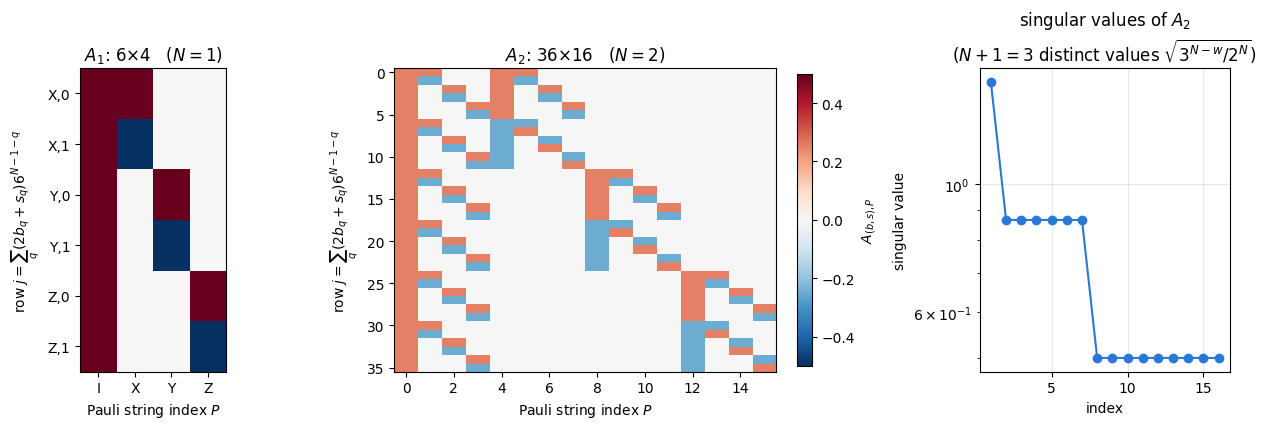

In [9]:
# ==============================================================================
# FIGURE: the design matrices A_1 (6 x 4) and A_2 (36 x 16), and the singular values of A_2
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.4), gridspec_kw={"width_ratios": [0.7, 2.0, 1.2]})
for ax, N in zip(axes[:2], (1, 2)):
    A = np.asarray(design_matrix(N))
    im = ax.imshow(A, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto", interpolation="nearest")
    ax.set_title(rf"$A_{N}$: {A.shape[0]}$\times${A.shape[1]}   ($N={N}$)")
    ax.set_xlabel("Pauli string index $P$")
    ax.set_ylabel(r"row $j=\sum_q(2b_q+s_q)6^{N-1-q}$")
    ax.grid(False)
    if N == 1:
        ax.set_xticks(range(4)); ax.set_xticklabels(pauli_labels(1))
        ax.set_yticks(range(6)); ax.set_yticklabels([f"{BASIS_CHARS[b]},{s}" for b in range(3) for s in range(2)])
fig.colorbar(im, ax=axes[1], fraction=0.035, label=r"$A_{(b,s),P}$")

sv = np.linalg.svd(np.asarray(design_matrix(2)), compute_uv=False)
axes[2].semilogy(np.arange(1, 17), sv, "o-", color=PALETTE[0])
axes[2].set_xlabel("index"); axes[2].set_ylabel("singular value")
axes[2].set_title(r"singular values of $A_2$" + "\n" + r"($N+1=3$ distinct values $\sqrt{3^{N-w}/2^N}$)")
fig.tight_layout(); plt.show()

The block structure of $A_2$ is the Kronecker product at work: nine blocks of four rows (one per setting and outcome pair), each
touching only the columns whose Pauli letters are compatible with that setting, and one column (the identity, $P=0$) that is filled
for every row. The singular values take only **$N+1=3$ distinct values**, a direct consequence of Eq. (6) — the next section explains
why, and why it makes the whole estimation problem trivial to solve.

## 7. Linear-regression tomography II: ordinary least squares

### 7.1 The normal equations

The least-squares estimator minimises the sum of squared residuals

$$\hat r_{\rm OLS}=\arg\min_r\ \lVert f-Ar\rVert^2 .$$

Setting the gradient to zero gives the **normal equations** $A^{\mathsf T}A\,\hat r=A^{\mathsf T}f$, whose solution is
$\hat r=(A^{\mathsf T}A)^{-1}A^{\mathsf T}f=A^{+}f$ with $A^{+}$ the Moore–Penrose pseudo-inverse. (Derivation: expand
$\lVert f-Ar\rVert^2=f^{\mathsf T}f-2r^{\mathsf T}A^{\mathsf T}f+r^{\mathsf T}A^{\mathsf T}Ar$ and differentiate with respect to $r$.)

Now use Eq. (6). The **Gram matrix** factorises,

$$A_N^{\mathsf T}A_N=\big(A_1^{\mathsf T}A_1\big)^{\otimes N},\qquad
  A_1^{\mathsf T}A_1=\frac14\,\mathrm{diag}(6,2,2,2)=\mathrm{diag}\!\left(\tfrac32,\tfrac12,\tfrac12,\tfrac12\right),$$

which is **diagonal**. Therefore $A^{\mathsf T}A$ is diagonal too, with entries depending only on the weight $w(P)$ (number of
non-identity letters):

$$\big(A^{\mathsf T}A\big)_{PP}=\left(\tfrac32\right)^{N-w(P)}\left(\tfrac12\right)^{w(P)}=\frac{3^{\,N-w(P)}}{2^N} . \tag{7}$$

No matrix has to be inverted: the normal equations decouple into $4^N$ independent scalar equations. (This also explains the
singular-value plot: $A^{\mathsf T}A$ has eigenvalues $3^{N-w}/2^N$, so $A$ has $N+1$ distinct singular values $\sqrt{3^{N-w}/2^N}$.)

### 7.2 Least squares *is* direct inversion of Pauli expectation values

Write out $\hat r_P=(A^{\mathsf T}f)_P/(A^{\mathsf T}A)_{PP}$ using Eq. (4):

$$\big(A^{\mathsf T}f\big)_P=\frac{1}{2^N}\sum_{b\ \text{compatible with}\ P}\ \sum_{s}(-1)^{m_P\cdot s}f(s\vert b),$$

where $m_P$ is the indicator of the support of $P$ and "compatible" means $b_q=p_q$ on the support. Dividing by Eq. (7),

$$\boxed{\ \hat r_P=\frac{1}{3^{\,N-w(P)}}\sum_{b\ \text{compatible}}\ \underbrace{\sum_s(-1)^{m_P\cdot s}f(s\vert b)}_{\textstyle \widehat{\langle P\rangle}_b}\ } \tag{8}$$

— and $\widehat{\langle P\rangle}_b$ is nothing but the **empirical average of the product of the measured signs** $(-1)^{s_q}$ over the
support of $P$: the textbook estimator of $\langle P\rangle$ from setting $b$. Equation (8) therefore says:

> **Ordinary least squares on the linear model is exactly "estimate every Pauli expectation value by averaging the corresponding
> products of outcomes, using all $3^{N-w}$ settings that can see it, with equal weight, and plug the result into
> $\rho=2^{-N}\sum_Pr_PP$".**

The two pictures that textbooks present as different methods — "linear regression" and "direct inversion" — are the same estimator.
The weighting of the $3^{N-w}$ compatible settings is the *uniform* average, and that is exactly what the code below computes:
because $A^{\mathsf T}A$ is diagonal, every compatible setting enters $\hat r_P$ with the same coefficient $1/3^{N-w}$,
irrespective of how the other letters of $b$ are chosen. Two more consequences:

* $\hat r_{I\ldots I}=1$ **exactly**, for any data: the identity column of $A$ is constant, and the frequencies of each setting sum to one.
  So the estimate always has unit trace. It is only positivity that will fail.
* Equation (8) needs no matrix at all — just sums over $3^N$ settings and $2^N$ outcomes. This is the **matrix-free general-$N$
  implementation**, and it is what we use from $N=3$ on.

In [10]:
# ==============================================================================
# STEP 4: three implementations of the same estimator -- lstsq, closed-form normal equations, matrix-free Eq. (8)
# ==============================================================================
def pauli_weight_table(N):
    """Weight w(P) (number of non-identity letters) of every Pauli string, as an int array (4^N,)."""
    return jnp.asarray([sum(ch != "I" for ch in lab) for lab in pauli_labels(N)], dtype=jnp.int32)


def gram_diagonal(N):
    """Diagonal of A^T A, Eq. (7):  3^{N-w(P)} / 2^N."""
    return 3.0 ** (N - pauli_weight_table(N)) / 2 ** N


def sign_table(N):
    """SIGN[P, s] = prod_{q in supp(P)} (-1)^{s_q}  -- the sign with which outcome s contributes to <P>. Shape (4^N, 2^N)."""
    labs = pauli_labels(N)
    s_bits = np.array(list(itertools.product((0, 1), repeat=N)))
    supp = np.array([[ch != "I" for ch in lab] for lab in labs], dtype=float)
    return jnp.asarray((-1.0) ** (s_bits[None, :, :] * supp[:, None, :]).sum(-1), dtype=RDTYPE)


def compat_table(N):
    """COMPAT[P, b] = 1 if setting b can measure P (b_q = p_q on the support of P), else 0.  Shape (4^N, 3^N)."""
    labs = pauli_labels(N)
    b_codes = np.array(list(itertools.product(range(3), repeat=N)))
    out = np.ones((4 ** N, 3 ** N))
    for pi, lab in enumerate(labs):
        for q, ch in enumerate(lab):
            if ch != "I":
                out[pi] *= (b_codes[:, q] == BASIS_CHARS.index(ch))
    return jnp.asarray(out, dtype=RDTYPE)


def linear_inversion(counts, SIGN, COMPAT):
    """Matrix-free ordinary least squares = direct Pauli inversion, Eq. (8).  Returns the Pauli vector r_hat (4^N,).

    MATH   r_hat_P = 3^{-(N-w)} sum_{b compatible} sum_s (-1)^{m_P.s} f(s|b)
    EINSUM "ps,bs->pb" contracts the outcome index: E[P,b] = the estimate of <P> obtained from setting b alone;
           the compatible settings are then averaged with the mask COMPAT.
    COST   O(4^N 2^N + 4^N 3^N) -- no 6^N x 4^N matrix, nothing to invert.
    JAX    pure function of `counts` -> vmap-able over data sets and bootstrap resamples.
    """
    freq = counts / jnp.sum(counts, axis=1, keepdims=True)
    E = jnp.einsum("ps,bs->pb", SIGN, freq)                # estimate of <P> from each setting separately
    return jnp.sum(COMPAT * E, axis=1) / jnp.sum(COMPAT, axis=1)


# --- CHECKPOINT: the three routes give the same Pauli vector --------------------------------------------
N = 2
A2 = design_matrix(N)
SIGN2, COMPAT2 = sign_table(N), compat_table(N)
f_demo = rows_from_counts(counts_demo, N)

r_lstsq = jnp.linalg.lstsq(A2, f_demo, rcond=None)[0]                          # generic least squares
r_normal = (A2.T @ f_demo) / gram_diagonal(N)                                  # closed-form normal equations, Eq. (7)
r_direct = linear_inversion(counts_demo, SIGN2, COMPAT2)                       # matrix-free Eq. (8)
gram_err = max_abs(A2.T @ A2 - jnp.diag(gram_diagonal(N)))
print(f"CHECKPOINT Gram matrix is diagonal with entries 3^(N-w)/2^N:  max error = {gram_err:.1e}")
print(f"CHECKPOINT lstsq   vs closed-form normal equations : {max_abs(r_lstsq - r_normal):.1e}")
print(f"CHECKPOINT lstsq   vs matrix-free direct inversion : {max_abs(r_lstsq - r_direct):.1e}")
print(f"CHECKPOINT identity coefficient r[II] = {float(r_direct[0]):.15f}  (exactly 1 -> the estimate has unit trace)")
assert gram_err < 1e3 * TOL and max_abs(r_lstsq - r_normal) < 1e3 * TOL and max_abs(r_lstsq - r_direct) < 1e3 * TOL

print(f"\n{'P':>4s} {'true <P>':>10s} {'estimate':>10s} {'error':>9s}   (Bell state, 200 shots per setting)")
r_true = pauli_vector(dm_matrix(rho_bell), N)
for i, lab in enumerate(pauli_labels(N)):
    print(f"{lab:>4s} {float(r_true[i]):10.3f} {float(r_direct[i]):10.3f} {float(r_direct[i] - r_true[i]):+9.3f}")

CHECKPOINT Gram matrix is diagonal with entries 3^(N-w)/2^N:  max error = 0.0e+00
CHECKPOINT lstsq   vs closed-form normal equations : 4.4e-16
CHECKPOINT lstsq   vs matrix-free direct inversion : 4.4e-16
CHECKPOINT identity coefficient r[II] = 1.000000000000000  (exactly 1 -> the estimate has unit trace)

   P   true <P>   estimate     error   (Bell state, 200 shots per setting)
  II      1.000      1.000    +0.000
  IX      0.000      0.010    +0.010
  IY      0.000     -0.043    -0.043
  IZ      0.000     -0.010    -0.010
  XI      0.000      0.040    +0.040
  XX      1.000      1.000    +0.000
  XY      0.000     -0.030    -0.030
  XZ      0.000     -0.090    -0.090
  YI      0.000      0.003    +0.003
  YX      0.000      0.060    +0.060
  YY     -1.000     -1.000    -0.000
  YZ      0.000     -0.060    -0.060
  ZI      0.000     -0.010    -0.010
  ZX      0.000     -0.010    -0.010
  ZY      0.000     -0.020    -0.020
  ZZ      1.000      1.000    +0.000


The three implementations agree to machine precision, confirming the algebra of Section 7.2. The estimated Pauli vector reproduces
the Bell-state signature $\langle ZZ\rangle=\langle XX\rangle=+1$, $\langle YY\rangle=-1$, everything else zero, with errors of a few
percent. The errors of the weight-1 strings (such as $XI$, $IY$) are on average smaller than those of the *non-stabiliser*
weight-2 strings ($XZ$, $YX$, $YZ$): the former are averaged over $3^{N-1}=3$ settings, the latter come from a single setting.
The three stabiliser strings $XX$, $YY$, $ZZ$ are the exception — their errors are exactly zero, because every shot of those
settings returns the same sign. Section 8 makes both statements quantitative.

### 7.3 Checkpoint: the infinite-shot limit

The sharpest test of an estimator is to feed it *exact* probabilities instead of frequencies — the $M\to\infty$ limit. An
informationally complete, correctly implemented linear inversion must then return the true state to machine precision.

In [11]:
# ==============================================================================
# CHECKPOINT: with exact probabilities (M -> infinity) linear inversion is EXACT
# ==============================================================================
print(f"{'state':>26s} {'N':>2s} {'max |r_hat - r_true|':>21s} {'|rho_hat - rho|_F':>18s}")
cases = [("Bell |Phi+>", to_dm(bell_state("phi+"))),
         ("GHZ_3", to_dm(ghz_state(3))),
         ("W_3", to_dm(w_state(3))),
         ("random pure, N=3", to_dm(haar_state(jax.random.PRNGKey(5), 3))),
         ("random mixed, N=2", dm_tensor(rdm(haar_state(jax.random.PRNGKey(6), 4), (0, 1)), 2)),
         ("noisy GHZ_3 (p=0.2)", None)]
rho_noisy = to_dm(ghz_state(3))
for q in range(3):
    rho_noisy = apply_kraus_dm(rho_noisy, kraus_depolarizing(0.2), [q])
cases[-1] = ("noisy GHZ_3 (p=0.2)", rho_noisy)

for name, rho in cases:
    n = rho.ndim // 2
    probs = all_setting_probs(rho, all_settings(n))
    r_hat = linear_inversion(probs, sign_table(n), compat_table(n))            # "counts" = exact probabilities
    rho_hat = rho_from_pauli_vector(r_hat, n)
    e_r = max_abs(r_hat - pauli_vector(dm_matrix(rho), n))
    e_rho = float(jnp.linalg.norm(rho_hat - dm_matrix(rho)))
    print(f"{name:>26s} {n:2d} {e_r:21.2e} {e_rho:18.2e}")
    assert e_r < 1e3 * TOL and e_rho < 1e3 * TOL

                     state  N  max |r_hat - r_true|  |rho_hat - rho|_F


               Bell |Phi+>  2              2.22e-16           2.22e-16


                     GHZ_3  3              2.22e-16           2.22e-16
                       W_3  3              2.22e-16           3.01e-16
          random pure, N=3  3              3.33e-16           2.37e-16
         random mixed, N=2  2              1.67e-16           1.28e-16
       noisy GHZ_3 (p=0.2)  3              6.66e-16           4.49e-16


Exact, for pure and mixed states alike, up to $N=3$. **The estimator has no systematic error**, so every deviation we see from now on
is statistical. This is the single most useful test in the whole notebook: before worrying about noise, check that your
reconstruction is exact when there is none.

## 8. Statistical errors: the accuracy of $\hat r$

### 8.1 Error propagation, analytically

Equation (8) makes the error analysis elementary. Fix a Pauli string $P$ of weight $w$ and a compatible setting $b$. In each shot
the quantity $(-1)^{m_P\cdot s}$ is a random variable taking the values $\pm1$ with mean $\langle P\rangle=r_P$; its variance is
therefore $\mathbb{E}[(\pm1)^2]-r_P^2=1-r_P^2$. Averaging $M$ independent shots divides the variance by $M$, and averaging the
$3^{N-w}$ *independent* settings divides it again:

$$\mathrm{Var}(\hat r_P)=\frac{1-r_P^2}{M\,3^{\,N-w(P)}} . \tag{9}$$

Two lessons hide in this innocent formula.

* **High-weight strings are expensive.** A weight-$N$ string such as $XXXX$ is seen by exactly one setting, so its variance is
  $3^N$ times larger than that of a single-qubit string measured with the same total budget. The *many-body* coordinates of the
  state are precisely the badly determined ones.
* **Saturated expectation values are cheap.** If $r_P=\pm1$ (a stabiliser of the state) the variance vanishes: every shot gives the
  same sign. This is why GHZ-type states are easier to certify than generic ones.

Summing the errors of all coordinates gives the expected reconstruction error in Frobenius norm. Using
$\lVert P\rVert_F^2=\mathrm{Tr}(P^2)=2^N$ and the orthogonality of the Pauli basis,

$$\mathbb{E}\big\lVert\hat\rho-\rho\big\rVert_F^2=\frac{1}{4^N}\sum_P\mathrm{Var}(\hat r_P)\,\lVert P\rVert_F^2
 =\frac{1}{2^N}\sum_{P\neq I}\frac{1-r_P^2}{M\,3^{\,N-w(P)}} . \tag{10}$$

Equation (10) contains *only* variances although the estimates $\hat r_P$ are in general correlated: two strings measured by the
same setting — say $XI$ and $XX$, both visible in the setting $XX$ — are built from the same shots. Those correlations are not
small (for the mixed state used below the largest is $0.31$), but they drop out of the Frobenius norm, because the cross-terms
come with $\mathrm{Tr}(PP')=2^N\delta_{PP'}$: the Pauli basis is orthogonal, so only the diagonal of $\mathrm{Cov}(\hat r)$
survives. For any other quadratic figure of merit the full covariance matrix of Section 8.2 is needed.

### 8.2 The covariance matrix of the estimate

For the full covariance, propagate Eq. (5) through the linear estimator $\hat r=A^+f$:

$$\mathrm{Cov}(\hat r)=A^{+}\,\mathrm{Cov}(f)\,\big(A^{+}\big)^{\mathsf T},$$

with $\mathrm{Cov}(f)$ the block-diagonal multinomial covariance. Its diagonal must reproduce Eq. (9) (it does; the cross-terms
$-p\,p^{\mathsf T}$ of the multinomial are exactly what removes the identity direction). We verify both formulas against a
Monte-Carlo experiment with many independent data sets — the only direct way to check an error bar.

In [12]:
# ==============================================================================
# CHECKPOINT: analytic error propagation vs 400 independent repetitions of the experiment
# ==============================================================================
N, M_ERR, N_REP = 2, 200, 300
rho_err = dm_tensor(rdm(haar_state(jax.random.PRNGKey(6), 4), (0, 1)), N)      # a generic MIXED state: no saturated r_P
set2, SIGN2, COMPAT2 = all_settings(N), sign_table(N), compat_table(N)
r_true = pauli_vector(dm_matrix(rho_err), N)
p_true = all_setting_probs(rho_err, set2)

# (a) Monte Carlo: N_REP independent experiments, vmapped over master keys
run_one = jax.jit(jax.vmap(lambda k: linear_inversion(counts_from_probs(k, p_true, M_ERR), SIGN2, COMPAT2)))
r_mc = run_one(jax.random.split(jax.random.PRNGKey(21), N_REP))                # (N_REP, 4^N)
var_mc = jnp.var(r_mc, axis=0, ddof=1)

# (b) the analytic formula, Eq. (9)
var_analytic = (1 - r_true ** 2) / (M_ERR * 3.0 ** (N - pauli_weight_table(N)))

# (c) full covariance propagation through the pseudo-inverse
A = design_matrix(N)
Aplus = jnp.linalg.pinv(A)
cov_f = jnp.zeros((6 ** N, 6 ** N))
rows = np.asarray(row_index(N))
for b in range(3 ** N):                                                        # one multinomial block per setting
    p = p_true[b]
    blk = (jnp.diag(p) - jnp.outer(p, p)) / M_ERR
    idx = jnp.asarray(rows[b])
    cov_f = cov_f.at[jnp.ix_(idx, idx)].set(blk)
cov_r = Aplus @ cov_f @ Aplus.T
var_prop = jnp.diag(cov_r)

print(f"{'P':>4s} {'r_true':>8s} {'std MC':>9s} {'std Eq.(9)':>11s} {'std A+CovA+':>12s}")
for i, lab in enumerate(pauli_labels(N)):
    print(f"{lab:>4s} {float(r_true[i]):8.3f} {float(jnp.sqrt(var_mc[i])):9.4f} "
          f"{float(jnp.sqrt(var_analytic[i])):11.4f} {float(jnp.sqrt(var_prop[i])):12.4f}")
err_prop = max_abs(var_prop[1:] - var_analytic[1:])
ratio = float(jnp.max(jnp.abs(jnp.sqrt(var_mc[1:] / var_analytic[1:]) - 1)))
var_wrong = (1 - r_true ** 2) / M_ERR            # CONTROL: Eq. (9) without the factor 3^(N-w) (each setting counted once)
ratio_wrong = float(jnp.max(jnp.abs(jnp.sqrt(var_mc[1:] / var_wrong[1:]) - 1)))
print(f"\nCHECKPOINT Eq.(9) vs full covariance propagation: max |Delta Var| = {err_prop:.2e}")
print(f"CHECKPOINT Monte Carlo vs Eq.(9): largest relative deviation of the standard deviations = {ratio:.1%} "
      f"(expected ~ 1/sqrt(2 x {N_REP}) = {1 / np.sqrt(2 * N_REP):.1%})")
print(f"CONTROL    the same test with the factor 3^(N-w) dropped from Eq.(9): largest deviation = {ratio_wrong:.1%} -> detected")
assert err_prop < 1e3 * TOL and ratio < 0.20 and ratio_wrong > 0.20

fro_mc = float(jnp.mean(jax.vmap(lambda r: jnp.linalg.norm(rho_from_pauli_vector(r, N) - dm_matrix(rho_err)) ** 2)(r_mc)))
fro_pred = float(jnp.sum(var_analytic[1:]) / 2 ** N)
fro_wrong = float(jnp.sum(var_wrong[1:]) / 2 ** N)
print(f"CHECKPOINT Eq.(10): E||rho_hat - rho||_F^2 = {fro_mc:.3e} (measured)  vs  {fro_pred:.3e} (predicted), "
      f"ratio {fro_mc / fro_pred:.3f}")
print(f"CONTROL    Eq.(10) built from the wrong variances: ratio {fro_mc / fro_wrong:.3f} -> detected")
assert abs(fro_mc / fro_pred - 1) < 0.15 and abs(fro_mc / fro_wrong - 1) > 0.15

   P   r_true    std MC  std Eq.(9)  std A+CovA+
  II    1.000    0.0000      0.0000       0.0000
  IX    0.166    0.0400      0.0403       0.0403
  IY    0.279    0.0376      0.0392       0.0392
  IZ   -0.121    0.0391      0.0405       0.0405
  XI    0.304    0.0406      0.0389       0.0389
  XX   -0.135    0.0675      0.0701       0.0701
  XY    0.504    0.0620      0.0611       0.0611
  XZ   -0.248    0.0689      0.0685       0.0685
  YI   -0.124    0.0412      0.0405       0.0405
  YX    0.005    0.0755      0.0707       0.0707
  YY   -0.255    0.0695      0.0684       0.0684
  YZ   -0.154    0.0688      0.0699       0.0699
  ZI    0.102    0.0394      0.0406       0.0406
  ZX    0.466    0.0625      0.0626       0.0626
  ZY   -0.200    0.0723      0.0693       0.0693
  ZZ    0.023    0.0674      0.0707       0.0707

CHECKPOINT Eq.(9) vs full covariance propagation: max |Delta Var| = 1.73e-18
CHECKPOINT Monte Carlo vs Eq.(9): largest relative deviation of the standard deviations =

CHECKPOINT Eq.(10): E||rho_hat - rho||_F^2 = 1.290e-02 (measured)  vs  1.280e-02 (predicted), ratio 1.008
CONTROL    Eq.(10) built from the wrong variances: ratio 0.733 -> detected


The three columns agree: the elementary per-string argument, the full covariance propagation through the pseudo-inverse, and the
brute-force Monte Carlo. The weight-1 strings ($XI$, $IX$, ...) have standard deviations about $\sqrt3$ smaller than the weight-2
ones, exactly as Eq. (9) predicts, and the total Frobenius error matches Eq. (10) within the Monte-Carlo uncertainty. The two
control lines repeat both tests with the factor $3^{N-w}$ dropped from Eq. (9), the most likely derivation error, and both fail.

> **Numerical practice.** Never quote a tomography result without an error bar, and never trust an error bar you have not tested
> against repetitions or a bootstrap. Formula (9) is easy to mis-derive by a factor $3^{N-w}$ — the Monte Carlo is what catches that.

## 9. Weighted least squares

Ordinary least squares treats every residual as equally important. But Eq. (5) says the residuals have very different variances:
an outcome with $p\approx0$ has variance $p(1-p)/M\approx0$, so its residual carries much more information than one with $p\approx1/2$.
The Gauss–Markov theorem says the minimum-variance unbiased linear estimator uses **inverse-variance weights**,

$$\hat r_{\rm WLS}=\big(A^{\mathsf T}WA\big)^{-1}A^{\mathsf T}Wf,\qquad W=\mathrm{diag}\!\left(\frac{M}{p(s\vert b)\big(1-p(s\vert b)\big)}\right).$$

There is a chicken-and-egg problem: the weights need $p$, which is what we are estimating. The standard fix is **feasible
(two-step) generalised least squares**: run OLS first, clip every Pauli coordinate to $[-1,1]$ (a crude stand-in for a physical state; the projection
of Section 11 is the alternative), compute the predicted probabilities from it, and use those as weights. We also have to regularise: a predicted probability of exactly $0$ would give an
infinite weight, so we floor the *variance factor* $p(1-p)$ at `floor` $=10^{-3}$, i.e. the weight of any single residual is
capped at $10^3M$ instead of diverging. (A predicted $p=1/2$ carries weight $4M$, so the cap is a factor $250$ above it.)

Three caveats, all of which we confirm numerically:

* with **estimated** weights the estimator is no longer exactly unbiased, and the Gauss–Markov guarantee is only asymptotic;
* because every setting here has the *same* number of shots and the design is highly symmetric, the gain over OLS is modest —
  it shows up mainly for states with near-deterministic outcomes, where OLS wastes information;
* WLS **loses the exact unit trace of Section 7.2**. That argument used the fact that the identity column of $A$ is constant
  *and* that all residuals of a setting enter with the same weight; with unequal weights $\hat r_{I\ldots I}\neq1$ and the
  reconstructed matrix has a trace that is only approximately one. The cell below prints how large the violation is.

In [13]:
# ==============================================================================
# STEP 5: weighted least squares with two-step (feasible) weights
# ==============================================================================
def weighted_least_squares(counts, N, p_model, floor=1e-3):
    """WLS estimate of the Pauli vector with inverse-variance weights from a model probability vector.

    MATH   r_hat = (A^T W A)^{-1} A^T W f,   W = diag( M / max(p(1-p), floor) )
    IMPL   `p_model` is a (3^N, 2^N) table of predicted probabilities (from a first-pass physical estimate).
    COST   O(24^N) for the Gram matrix -- fine for N <= 3; OLS stays matrix-free.
    """
    A = design_matrix(N)
    f = rows_from_counts(counts, N)
    M = jnp.sum(counts[0])
    var = jnp.clip(p_model * (1 - p_model), floor, None) / M
    w = jnp.zeros(6 ** N, dtype=RDTYPE).at[row_index(N).reshape(-1)].set((1.0 / var).reshape(-1))
    G = A.T @ (w[:, None] * A)
    return jnp.linalg.solve(G, A.T @ (w * f))


def physical_from_counts(counts, N, SIGN, COMPAT):
    """First pass: OLS + clipping of the Pauli vector to the unit ball of each coordinate (a crude but safe model)."""
    r = linear_inversion(counts, SIGN, COMPAT)
    return jnp.clip(r, -1.0, 1.0).at[0].set(1.0)

We compare OLS and WLS on two states with very different outcome statistics: the Bell state (many probabilities equal to $0$ or
$1/2$ — the regime where weighting should help) and a generic mixed state (all probabilities near $1/4$ — where it should not).
In between sits the Werner state of visibility $v$, written here with the singlet, $v\,\vert\Psi^-\rangle\langle\Psi^-\vert+(1-v)\,\mathbb 1/4$;
it differs from the $\vert\Phi^+\rangle$ form $\rho_W(v)$ of
[notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb), Section 11, by the local unitary
$\mathbb 1\otimes(-iY)$ and has the same spectrum and purity. The figure of merit is the root-mean-square Frobenius error over
$N_{\rm rep}$ independent data sets.

In [14]:
# ==============================================================================
# EXPERIMENT: OLS vs WLS on three states, many independent data sets each
# ==============================================================================
N, M_W, N_REP_W = 2, 100, 200
set2, SIGN2, COMPAT2 = all_settings(N), sign_table(N), compat_table(N)
states_w = {"Bell |Phi+>": to_dm(bell_state("phi+")),
            "Werner v=0.6": dm_tensor(mixed_with_identity(dm_matrix(to_dm(bell_state("psi-"))), 0.6), N),
            "random mixed": dm_tensor(rdm(haar_state(jax.random.PRNGKey(6), 4), (0, 1)), N)}

print(f"{'state':>16s} {'rms ||rho_hat-rho||_F  OLS':>28s} {'WLS':>10s} {'gain':>7s} {'max |Tr rho_WLS - 1|':>21s}")
for name, rho in states_w.items():
    p_true = all_setting_probs(rho, set2)
    rho_m = dm_matrix(rho)

    def both(k):
        c = counts_from_probs(k, p_true, M_W)
        r_ols = linear_inversion(c, SIGN2, COMPAT2)
        p_model = all_setting_probs(dm_tensor(rho_from_pauli_vector(physical_from_counts(c, N, SIGN2, COMPAT2), N), N), set2)
        r_wls = weighted_least_squares(c, N, p_model)
        e = lambda r: jnp.linalg.norm(rho_from_pauli_vector(r, N) - rho_m) ** 2
        return jnp.stack([e(r_ols), e(r_wls), jnp.abs(r_wls[0] - 1.0)])       # r[0] = Tr rho_hat

    errs = jax.jit(jax.vmap(both))(jax.random.split(jax.random.PRNGKey(31), N_REP_W))
    errs = np.asarray(errs)
    rms = np.sqrt(errs[:, :2].mean(0))
    print(f"{name:>16s} {rms[0]:28.4f} {rms[1]:10.4f} {rms[0] / rms[1]:6.2f}x {errs[:, 2].max():21.2e}")

           state   rms ||rho_hat-rho||_F  OLS        WLS    gain  max |Tr rho_WLS - 1|


     Bell |Phi+>                       0.1393     0.1328   1.05x              3.48e-03


    Werner v=0.6                       0.1538     0.1521   1.01x              3.17e-03


    random mixed                       0.1605     0.1557   1.03x              8.56e-03


The measured gain is a **few per cent** in root-mean-square error, largest for the Bell state (whose outcome distributions are far
from uniform, so the weights differ most) and smallest for the Werner state. The gain is small because there is almost nothing to
win, even with perfect weights. The Gauss–Markov theorem gives the variance of the *best possible* linear unbiased estimator,
$\mathrm{Cov}=\big(A^{\mathsf T}C^{-1}A\big)^{-1}$ with $C$ the exact block covariance of Eq. (5), and that bound can be evaluated
in closed form for each of these states. At $M=100$ it sits only $5.4\%$ below OLS for the Bell state, $1.0\%$ for the Werner state
and $5.6\%$ for the random mixed state — so the simple diagonal weights above already capture essentially the whole available gain.
With equal shots in every setting and a design matrix as symmetric as Eq. (6), ordinary least squares is close to optimal, and the
within-setting *correlations* that a diagonal $W$ ignores are worth almost nothing. (Exercise 4 asks you to reproduce these numbers.)

The gain also costs us the matrix-free form — WLS has to build and invert a $4^N\times4^N$ Gram matrix — the estimated weights
introduce a mild bias, and the estimate is no longer exactly unit-trace (the last column: up to about $1\%$ at $M=100$).
**For the rest of the notebook we therefore stay with
plain OLS**, whose matrix-free form, Eq. (8), scales to larger $N$; the real accuracy problem is elsewhere, as the next section shows.

## 10. Unphysical estimates from linear inversion

Linear inversion is unbiased, it needs no iteration, and it is exact in the infinite-shot limit. It has one fatal flaw:
**nothing in it enforces $\hat\rho\succeq0$.** The estimate is constructed from noisy numbers $\hat r_P$ that fluctuate freely in
$\mathbb{R}^{4^N-1}$, whereas physical states occupy only a convex body inside it. If the true state is *inside* that body and the
error bars are small, the estimate is very likely physical. If the true state sits *on the boundary* — and every pure state does —
then roughly half of the fluctuations push the estimate straight out of the set.

A one-qubit picture shows the mechanism. A pure state has a Bloch vector $\vec r$ of length exactly 1, and each component $r_a$ is
estimated from its own setting with variance $(1-r_a^2)/M$ (Eq. (9) with $N=w=1$). Writing $\hat r_a=r_a+\delta_a$,
$\lvert\hat{\vec r}\rvert^2=1+2\,\vec r\cdot\vec\delta+\lvert\vec\delta\rvert^2$: for a generic direction the linear term, of size
$O(1/\sqrt M)$ and symmetric about zero, dominates, and the estimated length exceeds 1 slightly more than half of the time; for a
Bloch vector along a measurement axis the linear term vanishes ($\delta_a=0$ for the saturated component) and the length exceeds 1
in almost every experiment. A Bloch vector longer than 1 corresponds to a matrix with a negative eigenvalue. For $N$ qubits the effect is much worse, because there are $4^N-1$
fluctuating directions all pushing outwards and only a thin shell of physical states to stay inside.

Let us measure it: the distribution of $\lambda_{\min}(\hat\rho)$ over many independent experiments, for a pure state (Bell) and
for the maximally mixed state (deep in the interior).

In [15]:
# ==============================================================================
# EXPERIMENT: how often is the linear-inversion estimate unphysical?  (N = 2, many data sets per point)
# ==============================================================================
N, N_REP_U = 2, 250
set2, SIGN2, COMPAT2 = all_settings(N), sign_table(N), compat_table(N)
SHOT_LIST_U = (50, 200, 1000, 5000)
states_u = {"Bell (pure, on the boundary)": to_dm(bell_state("phi+")),
            "Werner v=0.5": dm_tensor(mixed_with_identity(dm_matrix(to_dm(bell_state("psi-"))), 0.5), N),
            "maximally mixed (deep inside)": dm_tensor(jnp.eye(4, dtype=CDTYPE) / 4, N)}


def lmin_batch(key, p_true, shots, n_rep):
    """Smallest eigenvalue of the linear-inversion estimate for `n_rep` independent experiments."""
    def one(k):
        r = linear_inversion(counts_from_probs(k, p_true, shots), SIGN2, COMPAT2)
        return jnp.linalg.eigvalsh(rho_from_pauli_vector(r, N))[0]
    return jax.vmap(one)(jax.random.split(key, n_rep))


lmin_data = {}
print(f"{'state':>30s} " + " ".join(f"{'M=' + str(m):>16s}" for m in SHOT_LIST_U))
for si, (name, rho) in enumerate(states_u.items()):
    p_true = all_setting_probs(rho, set2)
    row = []
    for mi, shots in enumerate(SHOT_LIST_U):
        key_u = jax.random.PRNGKey(400 + 10 * si + mi)                     # fixed seed per (state, M): reproducible builds
        lmin = np.asarray(jax.jit(partial(lmin_batch, shots=shots, n_rep=N_REP_U))(key_u, p_true))
        lmin_data[(name, shots)] = lmin
        row.append(f"{np.mean(lmin < 0):6.1%} ({np.mean(lmin):+.3f})")
    print(f"{name:>30s} " + " ".join(f"{c:>16s}" for c in row))
print("\n(entries: fraction of experiments with a NEGATIVE eigenvalue, and the mean of lambda_min)")

                         state             M=50            M=200           M=1000           M=5000


  Bell (pure, on the boundary)  100.0% (-0.095)  100.0% (-0.046)  100.0% (-0.021)  100.0% (-0.009)


                  Werner v=0.5   35.6% (+0.013)    0.0% (+0.069)    0.0% (+0.101)    0.0% (+0.114)


 maximally mixed (deep inside)    0.0% (+0.100)    0.0% (+0.175)    0.0% (+0.216)    0.0% (+0.235)

(entries: fraction of experiments with a NEGATIVE eigenvalue, and the mean of lambda_min)


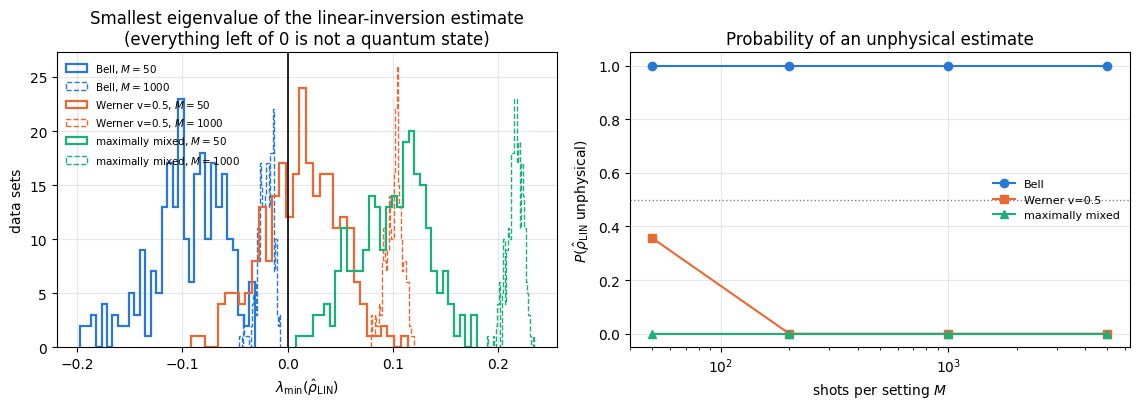

In [16]:
# ==============================================================================
# FIGURE: distribution of lambda_min and the probability of an unphysical estimate
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for i, (name, _) in enumerate(states_u.items()):
    for j, shots in enumerate((50, 1000)):
        axes[0].hist(lmin_data[(name, shots)], bins=32, histtype="step", lw=1.6 if j == 0 else 1.0,
                     ls="-" if j == 0 else "--", color=PALETTE[i],
                     label=f"{name.split(' (')[0]}, $M={shots}$")
axes[0].axvline(0, color="k", lw=1.2)
axes[0].set_xlabel(r"$\lambda_{\min}(\hat\rho_{\rm LIN})$"); axes[0].set_ylabel("data sets")
axes[0].set_title("Smallest eigenvalue of the linear-inversion estimate\n(everything left of 0 is not a quantum state)")
axes[0].legend(fontsize=7.5)

for i, (name, _) in enumerate(states_u.items()):
    frac = [np.mean(lmin_data[(name, m)] < 0) for m in SHOT_LIST_U]
    axes[1].semilogx(SHOT_LIST_U, frac, MARKERS[i] + "-", color=PALETTE[i], label=name.split(" (")[0])
axes[1].axhline(0.5, color="0.5", ls=":", lw=1)
axes[1].set_xlabel("shots per setting $M$"); axes[1].set_ylabel(r"$P(\hat\rho_{\rm LIN}\ \mathrm{unphysical})$")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Probability of an unphysical estimate")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

For the **Bell state** the linear-inversion estimate has a negative eigenvalue in essentially *every*
experiment, at every shot number: more shots shrink $\vert\lambda_{\min}\vert$ but do not reduce the probability of going negative,
because the true state sits exactly on the boundary and the fluctuations are symmetric around it. For the **maximally mixed state**
the estimate is physical as soon as the error bars are smaller than the distance $1/4$ to the boundary. The Werner state at $v=0.5$
sits in between.

> **Common pitfall.** A negative eigenvalue of this size is a statistical effect of order $1/\sqrt M$, far above rounding level,
> and clipping it away without further thought breaks everything downstream: entropies become complex, fidelities are ill-defined ($\sqrt{\hat\rho}$ does not exist), and negativity or
> concurrence report entanglement that is not there. This is exactly the objection Hradil raised in 1997 when he introduced
> maximum-likelihood tomography.

There are two standard cures, and we implement both: **project** the unphysical estimate onto the physical set (cheap, Section 11),
or **constrain the estimation itself** so that only physical states are ever considered (maximum likelihood, Sections 12–15).

## 11. Projection onto the physical set (Smolin–Gambetta–Smith)

### 11.1 The problem and its solution

Given a Hermitian $\hat\rho$ with $\mathrm{Tr}\,\hat\rho=1$ but possibly negative eigenvalues, find the physical state closest in
Frobenius (2-)norm:

$$\rho_\star=\arg\min_{\sigma\succeq0,\ \mathrm{Tr}\sigma=1}\lVert\hat\rho-\sigma\rVert_F^2 .$$

Smolin, Gambetta and Smith (2012) observed that this problem has a *closed-form* solution, derived below in three steps plus a
certificate. The title of their paper calls $\rho_\star$ the maximum-likelihood state for additive Gaussian noise. That
identification needs the noise on the matrix elements to be Gaussian **with the same variance in every direction**, because only then
is the log-likelihood a multiple of $-\lVert\hat\rho-\sigma\rVert_F^2$. Linear-inversion noise is not isotropic: by Eq. (9) the
variance of $\hat r_P$ is $(1-r_P^2)/(M\,3^{N-w(P)})$, which differs between coordinates by up to a factor $3^{N-1}$ through the
weight and vanishes for saturated coordinates. So $\rho_\star$ (LIN+proj below) is a projection and in general *not* the
maximum-likelihood state of the multinomial data; Sections 15–16 show the two differ measurably.

**Step 1: the eigenvectors are unchanged.** Write $\hat\rho=V\,\mathrm{diag}(\lambda)\,V^\dagger$. For any unit-trace
$\sigma\succeq0$, the Hoffman–Wielandt inequality gives
$\lVert\hat\rho-\sigma\rVert_F^2\ge\sum_i(\lambda_i-\mu_i)^2$ where $\lambda$ and $\mu$ are the two spectra sorted in the same order,
with equality when $\sigma$ has the same eigenvectors as $\hat\rho$. So we may keep $V$ and only fix the eigenvalues.

**Step 2: the eigenvalue problem is a projection onto the simplex.** We must find $\mu$ with $\mu_i\ge0$, $\sum_i\mu_i=1$,
minimising $\sum_i(\lambda_i-\mu_i)^2$. Introducing a Lagrange multiplier $-\nu$ for the trace and the
Karush–Kuhn–Tucker (KKT) conditions (Lagrange multipliers for inequality constraints) for $\mu_i\ge0$ gives
$\mu_i=\max(\lambda_i+\nu,\,0)$, with $\nu$ fixed by $\sum_i\max(\lambda_i+\nu,0)=1$. The left-hand side is
continuous and strictly increasing in $\nu$ wherever it is non-zero, so $\nu$ is unique.

**Step 3: the algorithm.** Sort $\lambda$ in *descending* order. The set of indices with $\mu_i>0$ is a prefix of that order, so we
only need its length $k$: take the largest $k$ such that $\lambda_{(k)}+\big(1-\sum_{i\le k}\lambda_{(i)}\big)/k>0$, then
$\nu=\big(1-\sum_{i\le k}\lambda_{(i)}\big)/k$. In the equivalent "sweep" formulation of the original paper one starts from the
smallest eigenvalue, sets it to zero, and redistributes its (negative) value equally over the remaining ones, repeating until all
are non-negative. Both cost $O(d\log d)$ after the $O(d^3)$ eigen-decomposition.

**Step 4: an exact optimality certificate.** Because the physical states form a convex set $\mathcal{S}$ and $\rho_\star$ is the
Euclidean projection of $\hat\rho$ onto it, the variational inequality

$$\mathrm{Tr}\big[(\hat\rho-\rho_\star)(\sigma-\rho_\star)\big]\le0\qquad\text{for every }\sigma\in\mathcal{S}$$

holds, and is *sufficient* as well as necessary. The left-hand side is maximised over $\sigma$ by the eigenvector of
$\hat\rho-\rho_\star$ with the largest eigenvalue, so the whole family of inequalities collapses to one scalar test, the
**optimality certificate**

$$\lambda_{\max}\big(\hat\rho-\rho_\star\big)\ \le\ \mathrm{Tr}\big[(\hat\rho-\rho_\star)\,\rho_\star\big] .$$

We implement the vectorised version (jit- and vmap-friendly) and the literal sweep (as a readable reference), and then check both
the certificate and — for illustration only — the distance to a cloud of random physical states.

> **Numerical practice.** The random-state comparison is the test one writes first and it is nearly worthless: the Hilbert–Schmidt
> measure puts its mass far from the boundary, so even $2\cdot10^5$ random states never come within $40\%$ of the projection
> distance, and a *wrong* projection (for instance the popular "clip the negative eigenvalues and rescale", which is on average
> $3\%$ farther away than $\rho_\star$ in the run below) passes it every single time. The certificate catches that same wrong projection every
> single time. A checkpoint is only worth writing if it can fail for the error it exists to catch.

In [17]:
# ==============================================================================
# STEP 6: projection of a Hermitian unit-trace matrix onto the physical states
# ==============================================================================
def project_physical(rho_mat):
    """Closest positive semi-definite unit-trace matrix in Frobenius norm (Smolin, Gambetta & Smith 2012).

    MATH   rho = V diag(lambda) V^dag  ->  mu_i = max(lambda_i + nu, 0)  with nu fixed by sum_i mu_i = 1.
    IMPL   sort descending, cumulative sums, pick the largest admissible prefix length k -- no Python loop,
           no branching on values -> jit/vmap-able.
    COST   O(d^3) for eigh, O(d log d) for the projection.
    """
    lam, V = jnp.linalg.eigh(jnp.asarray(rho_mat, dtype=CDTYPE))     # ascending eigenvalues
    d = lam.shape[0]
    u = lam[::-1]                                                    # descending
    css = jnp.cumsum(u)
    k_all = jnp.arange(1, d + 1, dtype=lam.dtype)
    ok = u + (1.0 - css) / k_all > 0                                 # prefix condition of step 3
    k = jnp.sum(ok)                                                  # number of surviving eigenvalues
    nu = (1.0 - css[k - 1]) / k
    mu = jnp.clip(lam + nu, 0.0, None)
    return (V * mu) @ V.conj().T


def projection_slack(rho_hat, rho_star):
    """Optimality certificate of Section 11.1: lambda_max(rho_hat - rho_star) - Tr[(rho_hat - rho_star) rho_star].

    MATH   rho_star = argmin_{sigma in S} ||rho_hat - sigma||_F  <=>  Tr[(rho_hat-rho_star)(sigma-rho_star)] <= 0 for all
           physical sigma.  The maximum of Tr[H sigma] over the state space is lambda_max(H), so the whole family of
           inequalities is equivalent to  lambda_max(H) <= Tr[H rho_star]  with H = rho_hat - rho_star.
    NOTE   This is necessary AND sufficient: a non-positive slack certifies optimality outright.
    """
    Hm = jnp.asarray(rho_hat, dtype=CDTYPE) - jnp.asarray(rho_star, dtype=CDTYPE)
    return float(jnp.linalg.eigvalsh(Hm)[-1] - jnp.real(jnp.trace(Hm @ jnp.asarray(rho_star, dtype=CDTYPE))))


def project_clip_rescale(rho_mat):
    """DELIBERATELY WRONG projection, used only as a control for the checkpoint below:
    clip the negative eigenvalues to zero and rescale the rest to unit trace. Physical, but NOT the closest state."""
    lam, V = jnp.linalg.eigh(jnp.asarray(rho_mat, dtype=CDTYPE))
    mu = jnp.clip(lam, 0.0, None)
    return (V * (mu / jnp.sum(mu))) @ V.conj().T


def project_physical_sweep(rho_mat):
    """The same projection written as the literal sweep of the original paper (NumPy, readable reference).
    Start from the smallest eigenvalue, zero it, spread its value over the remaining ones, repeat."""
    lam, V = np.linalg.eigh(np.asarray(rho_mat))
    lam = lam[::-1].copy()                                           # descending
    V = np.asarray(V)[:, ::-1]
    a, i = 0.0, len(lam)
    while i > 0 and lam[i - 1] + a / i < 0:
        a += lam[i - 1]
        lam[i - 1] = 0.0
        i -= 1
    lam[:i] += a / i
    return (V * lam) @ V.conj().T


# --- CHECKPOINT: the two implementations agree; the result is physical; and it really is the closest state ----
key = jax.random.PRNGKey(77)
worst_impl, worst_trace, worst_neg, n_better = 0.0, 0.0, 0.0, 0
worst_slack, worst_slack_wrong, n_better_wrong, excess = -np.inf, -np.inf, 0, []
for trial in range(40):
    k1, k2 = jax.random.split(jax.random.fold_in(key, trial))
    rho_true = dm_tensor(rdm(haar_state(k1, 4), (0, 1)), 2)
    c = counts_from_probs(k2, all_setting_probs(rho_true, all_settings(2)), 40)   # very few shots -> very unphysical
    rho_hat = rho_from_pauli_vector(linear_inversion(c, sign_table(2), compat_table(2)), 2)
    rho_p = project_physical(rho_hat)
    worst_impl = max(worst_impl, max_abs(rho_p - project_physical_sweep(rho_hat)))
    worst_trace = max(worst_trace, abs(float(jnp.real(jnp.trace(rho_p))) - 1))
    worst_neg = min(worst_neg, float(jnp.linalg.eigvalsh(rho_p)[0]))
    # optimality (i): the exact certificate -- slack must be <= 0
    worst_slack = max(worst_slack, projection_slack(rho_hat, rho_p))
    # optimality (ii): the weak test -- no random physical state is closer
    dist = float(jnp.linalg.norm(rho_hat - rho_p))
    ks = jax.random.split(jax.random.fold_in(k1, 999), 200)
    T = jax.vmap(lambda kk: jax.random.normal(kk, (4, 4)) + 1j * jax.random.normal(jax.random.fold_in(kk, 1), (4, 4)))(ks)
    sig = jax.vmap(lambda t: (t.conj().T @ t) / jnp.trace(t.conj().T @ t).real)(T)
    n_better += int(jnp.sum(jax.vmap(lambda s: jnp.linalg.norm(rho_hat - s))(sig) < dist - 1e-12))
    # CONTROL: the same two tests applied to a deliberately WRONG projection
    rho_w = project_clip_rescale(rho_hat)
    dist_w = float(jnp.linalg.norm(rho_hat - rho_w))
    excess.append(dist_w / dist)
    worst_slack_wrong = max(worst_slack_wrong, projection_slack(rho_hat, rho_w))
    n_better_wrong += int(jnp.sum(jax.vmap(lambda s: jnp.linalg.norm(rho_hat - s))(sig) < dist_w - 1e-12))
print(f"CHECKPOINT vectorised projection vs the literal sweep : max difference = {worst_impl:.1e}")
print(f"CHECKPOINT projected state: |Tr - 1| = {worst_trace:.1e},  lambda_min = {worst_neg:+.1e}")
print(f"CHECKPOINT optimality certificate: worst slack over 40 cases = {worst_slack:+.2e}  (must be <= 0)")
print(f"CHECKPOINT weak test: out of 40 x 200 random physical states, {n_better} were closer than the projection")
print(f"\nCONTROL -- the same tests on 'clip the negatives and rescale', which is NOT the closest physical state:")
print(f"   it is on average {np.mean(excess):.3f}x farther from rho_hat than the projection (worst {max(excess):.2f}x)")
print(f"   optimality certificate: worst slack = {worst_slack_wrong:+.2e}  -> positive, so the certificate DETECTS it")
print(f"   weak random-state test: {n_better_wrong} of 40 x 200 random states were closer  -> NOT detected")
assert worst_impl < 1e3 * TOL and worst_trace < 1e3 * TOL and worst_neg > -1e3 * TOL and n_better == 0
assert worst_slack < 1e3 * TOL                     # the certificate holds for our projection ...
assert worst_slack_wrong > 1e-6                    # ... and fails for the wrong one: the test has teeth

CHECKPOINT vectorised projection vs the literal sweep : max difference = 8.9e-16
CHECKPOINT projected state: |Tr - 1| = 1.3e-15,  lambda_min = -1.3e-16
CHECKPOINT optimality certificate: worst slack over 40 cases = +8.67e-16  (must be <= 0)
CHECKPOINT weak test: out of 40 x 200 random physical states, 0 were closer than the projection

CONTROL -- the same tests on 'clip the negatives and rescale', which is NOT the closest physical state:
   it is on average 1.033x farther from rho_hat than the projection (worst 1.35x)
   optimality certificate: worst slack = +2.71e-02  -> positive, so the certificate DETECTS it
   weak random-state test: 0 of 40 x 200 random states were closer  -> NOT detected


The two implementations coincide, the output is a legitimate density matrix, and the certificate holds to machine precision, so the
projection is optimal in the 2-norm, as advertised. The control shows why the certificate was worth deriving: the naive
"clip and rescale" recipe is measurably farther from $\hat\rho$, yet the random-state comparison cannot tell the two apart.

### 11.2 What the projection does to the estimate

The projection is a *non-linear* map, so it destroys unbiasedness: it always moves the estimate *towards* the interior, which makes
the reconstructed state **less pure** at the eigenvalue level and therefore **lowers** the fidelity with a pure target. It is
nevertheless the better estimate: it is closer to the truth in both the Frobenius and the trace norm, and the fidelity it reports is
a number computed from an actual quantum state, whereas the raw value is not. Let us look at one concrete case, where we can
see all the eigenvalues at once.

In [18]:
# ==============================================================================
# EXAMPLE: one Bell-state experiment, before and after projection
# ==============================================================================
rho_hat_demo = rho_from_pauli_vector(linear_inversion(counts_demo, sign_table(2), compat_table(2)), 2)
rho_proj_demo = project_physical(rho_hat_demo)
bell_mat = dm_matrix(rho_bell)
print("eigenvalues:")
print("   true  |Phi+>    :", np.round(np.asarray(jnp.linalg.eigvalsh(bell_mat)), 4))
print("   linear inversion:", np.round(np.asarray(jnp.linalg.eigvalsh(rho_hat_demo)), 4))
print("   after projection:", np.round(np.asarray(jnp.linalg.eigvalsh(rho_proj_demo)), 4))
psi_bell = jnp.asarray(bell_state("phi+")).reshape(-1)
F_lin = float(jnp.real(jnp.vdot(psi_bell, rho_hat_demo @ psi_bell)))
F_prj = float(jnp.real(jnp.vdot(psi_bell, rho_proj_demo @ psi_bell)))
print(f"\nfidelity with |Phi+>:  linear inversion {F_lin:.4f}   projected {F_prj:.4f}")
print(f"trace distance      :  linear inversion {float(trace_distance(rho_hat_demo, bell_mat)):.4f}   "
      f"projected {float(trace_distance(rho_proj_demo, bell_mat)):.4f}")
print(f"purity Tr(rho^2)    :  linear inversion {float(purity(rho_hat_demo)):.4f}   "
      f"projected {float(purity(rho_proj_demo)):.4f}   (true 1.0000)")

eigenvalues:
   true  |Phi+>    : [0. 0. 0. 1.]
   linear inversion: [-0.0308 -0.0118  0.0414  1.0012]
   after projection: [-0.      0.      0.0201  0.9799]

fidelity with |Phi+>:  linear inversion 1.0000   projected 0.9787
trace distance      :  linear inversion 0.0626   projected 0.0438
purity Tr(rho^2)    :  linear inversion 1.0051   projected 0.9605   (true 1.0000)


The raw estimate has a clearly negative eigenvalue; the projection zeroes it and redistributes the weight, which reduces the trace
distance to the true state. **The projection can only help in 2-norm** (it is a projection onto a convex set containing the truth),
and in practice it helps in trace distance too. The fidelity, by contrast, *drops* from the raw $1.0000$ to $0.9787$ — and the raw
$1.0000$ was never a fidelity, since $\hat\rho_{\rm LIN}$ has a negative eigenvalue; $\langle\Phi^+\vert\hat\rho\vert\Phi^+\rangle$
is merely a number that happens to be close to one. Section 15.1 explains why it is close to one *by construction* for this state.
The projection is one `eigh` per estimate, so there is no reason ever to report a raw
linear-inversion state. From here on "LIN" means raw linear inversion and "LIN+proj" the projected version.

## 12. Maximum-likelihood tomography I: the likelihood

### 12.1 The multinomial likelihood

Projection repairs the *estimate*. Maximum likelihood instead poses the constrained problem from the start: it looks for
**the physical state that makes the observed data most probable**.

The data are the counts $n_{b,s}$: setting $b$ was run $M$ times and outcome $s$ was seen $n_{b,s}$ times. For a fixed setting the
counts are multinomial, and different settings are independent, so

$$\mathcal{L}(\rho)=\prod_b\frac{M!}{\prod_sn_{b,s}!}\prod_s\,p(s\vert b)^{\,n_{b,s}},\qquad p(s\vert b)=\mathrm{Tr}(\rho\,\Pi_{b,s}).$$

The combinatorial prefactors do not depend on $\rho$, so we maximise the **log-likelihood**

$$\log L(\rho)=\sum_{b,s}n_{b,s}\,\log\mathrm{Tr}\!\left(\rho\,\Pi_{b,s}\right)=\sum_jn_j\log p_j(\rho) \tag{11}$$

over the *physical* set $\{\rho\succeq0,\ \mathrm{Tr}\rho=1\}$, where $j=(b,s)$ runs over all $6^N$ POVM elements.
Two structural facts make this problem pleasant:

* $p_j(\rho)$ is **linear** in $\rho$ and $\log$ is concave, so $\log L$ is a **concave** function on a **convex** set: there are no
  local maxima to get trapped in. (The maximiser need not be unique if the data are degenerate, but the maximal value is.)
* each $\Pi_j$ is a **rank-one projector**, $\Pi_j=\vert\phi_j\rangle\langle\phi_j\vert$, where $\vert\phi_j\rangle$ is the joint
  eigenvector of the measured Paulis. So $p_j=\langle\phi_j\vert\rho\vert\phi_j\rangle$, and the whole likelihood needs only a
  matrix $\Phi$ of $6^N$ vectors of length $d$ — one einsum, `"ja,ab,jb->j"`, gives all $6^N$ probabilities at once.

The vectors are easy to write down: $\Pi_{b,s}=U_b^\dagger\vert s\rangle\langle s\vert U_b$ with the same $U_b$ used for sampling,
so $\vert\phi_{b,s}\rangle=U_b^\dagger\vert s\rangle$ — the $s$-th column of $U_b^\dagger$.

In [19]:
# ==============================================================================
# STEP 7: the POVM as a stack of vectors, and the log-likelihood
# ==============================================================================
def povm_vectors(N):
    """All 6^N POVM elements as rank-one projectors Pi_j = |phi_j><phi_j|; returns PHI of shape (6^N, 2^N).

    MATH   Pi_{b,s} = U_b^dag |s><s| U_b  =>  |phi_{b,s}> = U_b^dag |s> = column s of U_b^dag.
    ORDER  row j is the design-matrix row index of Section 6.3, so PHI and the frequency vector f use ONE ordering.
    """
    settings, rows, d = np.asarray(all_settings(N)), np.asarray(row_index(N)), 2 ** N
    rot = [np.asarray(_BASIS_ROT[c]) for c in BASIS_CHARS]
    PHI = np.zeros((6 ** N, d), dtype=complex)
    for bi, codes in enumerate(settings):
        U = np.ones((1, 1), dtype=complex)
        for q in range(N):
            U = np.kron(U, rot[int(codes[q])])
        Udag = U.conj().T
        for si in range(d):
            PHI[rows[bi, si]] = Udag[:, si]
    return jnp.asarray(PHI, dtype=CDTYPE)


def counts_vector(counts, N):
    """Arrange the (3^N, 2^N) table of counts into the 6^N-long vector n_j used by the likelihood."""
    return jnp.zeros(6 ** N, dtype=counts.dtype).at[row_index(N).reshape(-1)].set(counts.reshape(-1))


def povm_probs(rho_mat, PHI):
    """All 6^N Born probabilities p_j = <phi_j|rho|phi_j>  --  ONE einsum "ja,ab,jb->j"."""
    return jnp.real(jnp.einsum("ja,ab,jb->j", jnp.conj(PHI), rho_mat, PHI))


def log_likelihood(rho_mat, n_vec, PHI):
    """Eq. (11):  log L = sum_j n_j log p_j.  Zero counts contribute nothing even where p_j -> 0."""
    p = povm_probs(rho_mat, PHI)
    return jnp.sum(n_vec * jnp.log(jnp.clip(p, 1e-300, None)))


# --- CHECKPOINT: the POVM stack reproduces the sampler and sums to 3^N x identity ----------------------
for N in (1, 2, 3):
    PHI = povm_vectors(N)
    rho_t = dm_tensor(rdm(haar_state(jax.random.PRNGKey(30 + N), N + 2), tuple(range(N))), N)
    p_povm = povm_probs(dm_matrix(rho_t), PHI)
    p_sim = rows_from_counts(all_setting_probs(rho_t, all_settings(N)), N)     # exact probs through the sampler path
    S = jnp.einsum("ja,jb->ab", PHI, jnp.conj(PHI))                            # sum_j Pi_j
    e_p = max_abs(p_povm - p_sim)
    e_S = max_abs(S - 3 ** N * jnp.eye(2 ** N))
    print(f"N={N}: |p(POVM) - p(sampler)| = {e_p:.1e};  |sum_j Pi_j - 3^N x 1| = {e_S:.1e};  "
          f"PHI has shape {tuple(PHI.shape)}")
    assert e_p < 1e3 * TOL and e_S < 1e3 * TOL

N=1: |p(POVM) - p(sampler)| = 3.3e-16;  |sum_j Pi_j - 3^N x 1| = 4.4e-16;  PHI has shape (6, 2)
N=2: |p(POVM) - p(sampler)| = 1.7e-16;  |sum_j Pi_j - 3^N x 1| = 1.8e-15;  PHI has shape (36, 4)


N=3: |p(POVM) - p(sampler)| = 2.8e-16;  |sum_j Pi_j - 3^N x 1| = 7.1e-15;  PHI has shape (216, 8)


## 13. Maximum-likelihood tomography II: the extremal equation $R\rho R=\rho$

We now derive the condition satisfied by the maximiser. Hradil (1997) obtained it from the inequality between geometric and
arithmetic means; a shorter route parametrises the positivity constraint away:
write $\rho=T^\dagger T$ with an arbitrary complex $d\times d$ matrix $T$ — every positive semi-definite matrix can be written this
way — and impose the trace with a Lagrange multiplier $\lambda$:

$$\mathcal{F}(T,T^\dagger)=\sum_jn_j\log\mathrm{Tr}\!\left(T^\dagger T\,\Pi_j\right)-\lambda\,\mathrm{Tr}\!\left(T^\dagger T\right).$$

Treat $T$ and $T^\dagger$ as independent (Wirtinger calculus: $\partial\,\mathrm{Tr}(T^\dagger TA)/\partial T^\dagger=TA$) and set
the derivative with respect to $T^\dagger$ to zero:

$$\sum_j\frac{n_j}{p_j}\,T\,\Pi_j-\lambda\,T=0\qquad\Longleftrightarrow\qquad T\,R=\lambda\,T,\qquad
  R\equiv\sum_j\frac{n_j}{p_j}\,\Pi_j . \tag{12}$$

Multiply Eq. (12) from the left by $T^\dagger$ and use $\rho=T^\dagger T$:

$$\rho\,R=\lambda\,\rho,\qquad\text{and by taking the adjoint}\qquad R\,\rho=\lambda\,\rho .$$

The multiplier follows from the trace: $\mathrm{Tr}(R\rho)=\sum_j(n_j/p_j)\,\mathrm{Tr}(\rho\Pi_j)=\sum_jn_j=N_{\rm tot}$, the total
number of shots, so $\lambda=N_{\rm tot}$. Defining the normalised operator $\tilde R=R/N_{\rm tot}$ we obtain the
**extremal equation**

$$\tilde R\,\rho=\rho\qquad\Longrightarrow\qquad \tilde R\,\rho\,\tilde R=\rho . \tag{13}$$

The symmetric form on the right is the useful one: it preserves Hermiticity and positivity, since
$\tilde R\rho\tilde R=(\tilde R T^\dagger)(T\tilde R)^{\vphantom{\dagger}}$ is manifestly of the form $B^\dagger B$.

Equation (13) is *necessary* for a maximum but, on its own, not sufficient. If the maximiser is rank deficient — which, as
Sections 15 and 17 show, is the normal situation for a state near the boundary — the full first-order condition of the concave
problem is $\tilde R\rho=\rho$ **together with** $\tilde R\preceq\mathbb 1$: the eigenvalue of $\tilde R$ equals $1$ on the support
of $\rho$ and is strictly smaller on its kernel, so that no probability can profitably be moved into the kernel. (Section 13.3
prints the spectrum of the converged $\tilde R$ for its Bell data set and checks $\tilde R\preceq\mathbb 1$.) The residual
$\lVert\tilde R\rho-\rho\rVert$ that we monitor is therefore only a convergence diagnostic; together with
$\lambda_{\max}(\tilde R)\le1$ it certifies the maximum, because $\log L$ is concave.

Equation (13) suggests the fixed-point iteration

$$\rho_{k+1}=\frac{\tilde R(\rho_k)\;\rho_k\;\tilde R(\rho_k)}{\mathrm{Tr}\!\left[\tilde R(\rho_k)\,\rho_k\,\tilde R(\rho_k)\right]} \tag{14}$$

— the **$R\rho R$ algorithm**, as Řeháček, Hradil, Knill and Lvovsky (2007) call it, crediting it to earlier work of Hradil,
Řeháček, Fiurášek and Ježek (in the Paris–Řeháček collection listed in the references). Each step (i) computes the $6^N$ probabilities, (ii) assembles $R$, (iii) sandwiches and renormalises.
Starting from the maximally mixed state $\rho_0=\mathbb 1/d$, positivity and unit trace hold at every step *by construction*.

**Two caveats, both important.**

1. The derivation assumed nothing about $\sum_j\Pi_j$, but the iteration behaves well only when that sum is proportional to the
   identity. For our POVM it is: $\sum_j\Pi_j=3^N\mathbb 1$, as verified above. For a general (unbalanced) POVM one replaces
   $R$ by $G^{-1}R$ with $G=\sum_j\Pi_j$.
2. Equation (14) is a *fixed-point* iteration: it has the right fixed points but is **not guaranteed** to
   increase the likelihood at every step, and it can fail to converge. Řeháček, Hradil, Knill and Lvovsky (2007) fixed this with a
   **diluted** step that interpolates towards the identity map,

$$\rho_{k+1}\ \propto\ \left(\mathbb 1+\epsilon\tilde R\right)\rho_k\left(\mathbb 1+\epsilon\tilde R\right), \tag{15}$$

which for small enough $\epsilon>0$ provably increases $\log L$ at every step and has exactly the same fixed points
(at a fixed point $\tilde R\rho=\rho$, so the right-hand side is $(1+\epsilon)^2\rho$, i.e. $\rho$ after normalisation).
Large $\epsilon$ recovers Eq. (14). The theorem covers *sufficiently small* $\epsilon$ only; for $\epsilon$ of order one — and
for the plain step — monotonicity has to be checked on the data at hand. (Řeháček et al. give a one-qubit example, three
detections in a single basis, on which the plain step cycles with period two and lowers the likelihood every second step.)
The cell below performs that check, and for these data sets nothing ever decreases (see also Exercise 5).

### 13.1 From formula to code

Every ingredient is one einsum on the rank-one POVM stack:

* probabilities: `p = einsum("ja,ab,jb->j", conj(PHI), rho, PHI)` (Section 12);
* the operator $R$: $R=\sum_j w_j\vert\phi_j\rangle\langle\phi_j\vert$ with $w_j=n_j/p_j$, i.e.
  `R = einsum("j,ja,jb->ab", w, PHI, conj(PHI))` — the sum over $6^N$ POVM elements happens *inside* the einsum, no Python loop;
* the update: two matrix products and a trace.

The whole iteration is a `lax.scan` whose carry is the current $\rho$ and whose per-step output is the log-likelihood — so we get
a convergence history for free and can *check* monotonicity instead of hoping for it.

In [20]:
# ==============================================================================
# STEP 8: the RrhoR algorithm and its diluted variant, as a lax.scan
# ==============================================================================
def r_operator(rho_mat, n_vec, PHI):
    """R/N_tot = (1/N_tot) sum_j (n_j/p_j) |phi_j><phi_j|  --  einsum "j,ja,jb->ab" over all 6^N POVM elements."""
    p = jnp.clip(povm_probs(rho_mat, PHI), 1e-12, None)
    w = n_vec / p
    R = jnp.einsum("j,ja,jb->ab", w.astype(CDTYPE), PHI, jnp.conj(PHI))
    return R / jnp.sum(n_vec)


def _renormalise(M):
    """Hermitise and rescale to unit trace (guards against round-off drift of the iteration)."""
    M = (M + M.conj().T) / 2
    return M / jnp.real(jnp.trace(M))


def mle_rrhor(n_vec, PHI, n_iter=250, eps=None, rho0=None):
    """Maximum-likelihood state by the (diluted) RrhoR iteration, Eqs. (14)-(15).

    MATH   eps = None : rho <- N[ R rho R ]   (R normalised by N_tot; extremal equation of Hradil 1997)
           eps > 0    : rho <- N[ (1 + eps R) rho (1 + eps R) ]   (diluted; Rehacek et al. 2007)
    IMPL   lax.scan over a FIXED number of iterations; the per-step output is log L, so the convergence
           history comes for free and monotonicity can be asserted.
    JAX    pure function of (n_vec) -> vmap-able over data sets / bootstrap resamples.
    COST   O(n_iter * (6^N d^2 + d^3)).
    """
    d = PHI.shape[1]
    rho = jnp.eye(d, dtype=CDTYPE) / d if rho0 is None else rho0

    def step(rho, _):
        R = r_operator(rho, n_vec, PHI)
        G = R if eps is None else (jnp.eye(d, dtype=CDTYPE) + eps * R)
        rho_new = _renormalise(G @ rho @ G.conj().T)
        return rho_new, log_likelihood(rho_new, n_vec, PHI)

    rho, hist = lax.scan(step, rho, None, length=n_iter)
    return rho, hist

### 13.2 Checkpoint: the infinite-shot limit and the extremal equation

As for linear inversion, the sharpest test uses exact probabilities as "counts": the maximum-likelihood state must then be the true
state. We also check the extremal equation itself, $\lVert\tilde R\rho-\rho\rVert\to0$, which is a sharper convergence criterion
than a likelihood that stops changing (that may just mean tiny steps).

In [21]:
# ==============================================================================
# CHECKPOINT: MLE with exact probabilities returns the true state and satisfies R rho = rho
# ==============================================================================
print(f"{'state':>22s} {'N':>2s} {'|rho_MLE - rho_true|_F':>23s} {'|R rho - rho|_F':>17s}")
for name, rho in [("Bell |Phi+>", to_dm(bell_state("phi+"))),
                  ("Werner v=0.7", dm_tensor(mixed_with_identity(dm_matrix(to_dm(bell_state("psi-"))), 0.7), 2)),
                  ("random mixed N=2", dm_tensor(rdm(haar_state(jax.random.PRNGKey(6), 4), (0, 1)), 2)),
                  ("GHZ_3", to_dm(ghz_state(3)))]:
    n = rho.ndim // 2
    PHI = povm_vectors(n)
    n_vec = counts_vector(all_setting_probs(rho, all_settings(n)) * 1000.0, n)   # exact probabilities x 1000
    rho_mle, hist = mle_rrhor(n_vec, PHI, n_iter=400, eps=None)
    e_rho = float(jnp.linalg.norm(rho_mle - dm_matrix(rho)))
    e_ext = float(jnp.linalg.norm(r_operator(rho_mle, n_vec, PHI) @ rho_mle - rho_mle))
    print(f"{name:>22s} {n:2d} {e_rho:23.2e} {e_ext:17.2e}")
    assert e_rho < 2e-6 and e_ext < 2e-6

                 state  N  |rho_MLE - rho_true|_F   |R rho - rho|_F


           Bell |Phi+>  2                1.37e-16          1.80e-49
          Werner v=0.7  2                1.34e-16          3.76e-18
      random mixed N=2  2                4.07e-12          1.15e-13


                 GHZ_3  3                2.94e-16          9.22e-18


With noiseless data the maximum-likelihood state converges to the true state (to $4\cdot10^{-12}$ or better in Frobenius norm after
$400$ iterations) and the extremal equation is satisfied to $10^{-13}$ or better. The slowest case is the full-rank random mixed
state; the *pure* states, whose optimum sits on the boundary, converge to round-off. (The assertion threshold $2\cdot10^{-6}$ only
guards against gross failure.)

### 13.3 Convergence with real (noisy) data, and monotonicity

Now the interesting case: finite statistics. We run the plain and the diluted iteration on a new Bell data set and on a Werner data
set, both with $500$ shots per setting, and monitor (i) the log-likelihood per shot, (ii) the residual of the extremal equation, and
(iii) for the Bell state, how far the estimate is from the exact state and whether it satisfies the full optimality condition
$\tilde R\preceq\mathbb 1$. The quantity plotted is $\log L_{\max}-\log L_k$ on a logarithmic axis, so "converged" means "falls off the plot".

In [22]:
# ==============================================================================
# EXPERIMENT: convergence of the RrhoR iteration -- plain vs diluted
# ==============================================================================
N, M_MLE, N_IT = 2, 500, 300
set2, PHI2 = all_settings(N), povm_vectors(N)
conv_states = {"Bell |Phi+> (pure)": to_dm(bell_state("phi+")),
               "Werner v=0.7 (mixed)": dm_tensor(mixed_with_identity(dm_matrix(to_dm(bell_state("psi-"))), 0.7), N)}
variants = [("plain $R\\rho R$", None), (r"diluted $\epsilon=1$", 1.0), (r"diluted $\epsilon=0.2$", 0.2)]
conv = {}
print(f"{'state':>22s} {'variant':>22s} {'log L / shot':>13s} {'|R rho - rho|':>14s} {'max decrease of log L':>22s}")
for sname, rho in conv_states.items():
    counts = simulate_experiment(jax.random.PRNGKey(55), rho, set2, M_MLE)
    n_vec = counts_vector(counts, N)
    for vname, eps in variants:
        rho_mle, hist = mle_rrhor(n_vec, PHI2, n_iter=N_IT, eps=eps)
        hist = np.asarray(hist)
        drop = float(np.min(np.diff(hist)))                    # negative => the likelihood went DOWN at some step
        res = float(jnp.linalg.norm(r_operator(rho_mle, n_vec, PHI2) @ rho_mle - rho_mle))
        conv[(sname, vname)] = (hist, rho_mle)
        print(f"{sname:>22s} {vname:>22s} {hist[-1] / float(jnp.sum(n_vec)):13.6f} {res:14.2e} {drop:22.2e}")
        assert drop > -1e-9 * abs(hist[-1])   # monotone to round-off: a theorem for small eps, an observation otherwise

# --- is the Bell maximum-likelihood estimate the exact Bell state?  (Section 13.3) ---------------------
rho_bell_mle = conv[("Bell |Phi+> (pure)", "plain $R\\rho R$")][1]
p_mle = povm_probs(rho_bell_mle, PHI2)
p_zero = np.asarray(p_mle)[np.asarray(rows_from_counts(all_setting_probs(conv_states["Bell |Phi+> (pure)"], set2), N)) < 1e-12]
print("\nBell maximum-likelihood estimate vs the exact Bell state:")
for lab in ("XX", "YY", "ZZ"):
    i = pauli_labels(N).index(lab)
    v = float(pauli_vector(rho_bell_mle, N)[i])
    print(f"   <{lab}>_MLE = {v:+.6f}   (exact {float(pauli_vector(bell_mat, N)[i]):+.0f};  deficit {abs(abs(v) - 1):.1e})")
print(f"   largest probability assigned to an outcome that was NEVER observed: {p_zero.max():.2e}  (exact state: 0)")
print(f"   rank of the estimate: {int(np.sum(np.asarray(jnp.linalg.eigvalsh(rho_bell_mle)) > 1e-9))}"
      f"   fidelity with |Phi+>: {float(jnp.real(jnp.vdot(psi_bell, rho_bell_mle @ psi_bell))):.6f}")
assert p_zero.max() > 1e-6 and abs(float(pauli_vector(rho_bell_mle, N)[pauli_labels(N).index("XX")]) - 1) > 1e-6

# --- full optimality condition at a rank-deficient maximum: R~ rho = rho AND lambda_max(R~) <= 1 (Section 13) ---
c_bell = simulate_experiment(jax.random.PRNGKey(55), conv_states["Bell |Phi+> (pure)"], set2, M_MLE)   # the same Bell data
n_bell = counts_vector(c_bell, N)
ev_R = np.asarray(jnp.linalg.eigvalsh(r_operator(rho_bell_mle, n_bell, PHI2)))
# CONTROL: the projected linear-inversion state of the SAME data is physical but not the maximiser -> the test must fail for it
rho_bell_prj = project_physical(rho_from_pauli_vector(linear_inversion(c_bell, SIGN2, COMPAT2), N))
ev_R_prj = np.asarray(jnp.linalg.eigvalsh(r_operator(rho_bell_prj, n_bell, PHI2)))
print(f"   spectrum of R~ at the MLE      : {np.round(ev_R, 3)}   (= 1 on the support, < 1 on the kernel)")
print(f"   CONTROL, R~ at LIN+proj (same data): lambda_max = {ev_R_prj[-1]:.3f}  > 1 -> correctly NOT certified as the maximum")
assert ev_R[-1] < 1 + 1e-8 and ev_R_prj[-1] > 1 + 1e-3

                 state                variant  log L / shot  |R rho - rho|  max decrease of log L


    Bell |Phi+> (pure)        plain $R\rho R$     -1.155108       1.07e-16              -1.82e-12
    Bell |Phi+> (pure)   diluted $\epsilon=1$     -1.155108       1.39e-16              -9.09e-13
    Bell |Phi+> (pure) diluted $\epsilon=0.2$     -1.155108       8.08e-11               2.16e-08


  Werner v=0.7 (mixed)        plain $R\rho R$     -1.294787       1.18e-11              -2.73e-12
  Werner v=0.7 (mixed)   diluted $\epsilon=1$     -1.294787       7.23e-08               3.72e-10
  Werner v=0.7 (mixed) diluted $\epsilon=0.2$     -1.294787       2.67e-05               1.64e-05

Bell maximum-likelihood estimate vs the exact Bell state:
   <XX>_MLE = +0.999919   (exact +1;  deficit 8.1e-05)
   <YY>_MLE = -0.999755   (exact -1;  deficit 2.4e-04)
   <ZZ>_MLE = +0.999835   (exact +1;  deficit 1.7e-04)
   largest probability assigned to an outcome that was NEVER observed: 1.15e-04  (exact state: 0)
   rank of the estimate: 1   fidelity with |Phi+>: 0.999877


   spectrum of R~ at the MLE      : [0.764 0.778 0.791 1.   ]   (= 1 on the support, < 1 on the kernel)
   CONTROL, R~ at LIN+proj (same data): lambda_max = 1.002  > 1 -> correctly NOT certified as the maximum


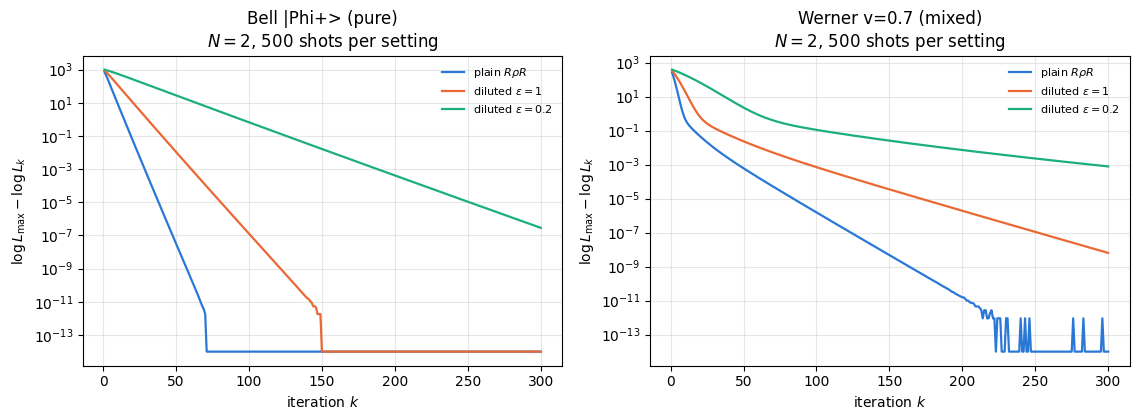

In [23]:
# ==============================================================================
# FIGURE: convergence of the log-likelihood, plain vs diluted
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for i, (sname, rho) in enumerate(conv_states.items()):
    best = max(conv[(sname, v)][0][-1] for v, _ in variants)
    for k, (vname, _) in enumerate(variants):
        hist = conv[(sname, vname)][0]
        axes[i].semilogy(np.arange(1, len(hist) + 1), np.clip(best - hist, 1e-14, None),
                         color=PALETTE[k], lw=1.6, label=vname)
    axes[i].set_xlabel("iteration $k$")
    axes[i].set_ylabel(r"$\log L_{\max}-\log L_k$")
    axes[i].set_title(f"{sname}\n$N=2$, {M_MLE} shots per setting")
    axes[i].legend(fontsize=8)
fig.tight_layout(); plt.show()

Both variants climb the same hill and reach the same summit (identical $\log L$ per shot to six decimals). The plain $R\rho R$ step
is by far the fastest — for these data it never decreased the likelihood by more than round-off, as the printed "max decrease"
column shows — while the diluted steps trade speed for the *guarantee* of monotonicity, and the smaller $\epsilon$ is, the slower
and the safer: after 300 iterations the Werner residual $\lVert\tilde R\rho-\rho\rVert$ is still $\sim10^{-5}$ at $\epsilon=0.2$,
against $\sim10^{-11}$ for the plain step.

The two panels also differ in speed: the **Bell** data converge in about $70$ plain iterations, the **Werner** data need roughly
$200$, although the Bell state sits on the boundary of the state space. The reason
is the stabiliser structure of $\vert\Phi^+\rangle$. In the settings $XX$, $YY$ and $ZZ$ two of the four outcomes never occur, so
their counts are exactly zero. A zero count contributes $0\cdot\log p_j=0$ to Eq. (11) and therefore imposes no penalty by itself —
but the *other* two outcomes of that setting contribute $\sim M\log p$, and since the four probabilities of a setting sum to one,
every unit of probability placed on an unobserved outcome is taken away from the observed ones and costs $\sim M$ in log-likelihood.
The six unobserved outcomes span the whole orthogonal complement of $\vert\Phi^+\rangle$, so the likelihood pushes hard against all
three of the "wrong" directions at once. Section 17 shows the consequence: for data like these the maximum-likelihood estimate comes
out **rank one** in every experiment.

It does *not* come out equal to $\vert\Phi^+\rangle$, and the distinction matters. Pushing the six unobserved probabilities exactly
to zero would force $\langle XX\rangle=1$, $\langle YY\rangle=-1$, $\langle ZZ\rangle=1$ simultaneously, which singles out
$\vert\Phi^+\rangle$ and would make the reconstruction exact at any $M$. The optimum stops short of that, because tilting the state
slightly also improves the fit to the six *mismatched* settings, whose frequencies fluctuate. The trade-off is $\sim M\delta^2$ lost
against $\sim\delta\sqrt M$ gained for a tilt of angle $\delta$, so the maximiser sits at $\delta\sim1/\sqrt M$. The diagnostics
printed below the convergence table make this concrete: the converged Bell estimate has stabiliser expectation values close to but
*not equal to* $\pm1$, and unobserved probabilities that are small but non-zero. The last two printed lines check the full
optimality condition of Section 13: $\tilde R$ has the eigenvalue $1$ on the support of the rank-one estimate and eigenvalues
between $0.76$ and $0.79$ on its kernel, so no direction of the state space increases $\log L$; the projected linear-inversion state
of the same data, physical but not the maximiser, fails the same test ($\lambda_{\max}(\tilde R)=1.002$, a small excess but far
above the round-off level of the converged maximum). Section 15 turns the balance between the two terms into a
quantitative law for the infidelity.

> **Numerical practice.** Use the plain iteration by default, but *monitor*: store $\log L_k$, check that it never decreases, and
> check the residual $\lVert\tilde R\rho-\rho\rVert$ at the end. If either misbehaves, switch to a diluted step. Never use "the
> likelihood stopped changing" alone as a convergence criterion.

## 14. Maximum-likelihood tomography III: gradient ascent with `jax.grad` and Adam

The $R\rho R$ iteration is a special-purpose algorithm: it exists because the likelihood of a *linear* model has
that particular structure. A modern alternative works for any differentiable cost: **parametrise the constraint away and use
automatic differentiation**.

### 14.1 The Cholesky (Cholesky-like) parametrisation

Take an arbitrary complex matrix $T\in\mathbb{C}^{d\times d}$ — in this notebook a full matrix, though a lower-triangular one with
real diagonal (the Cholesky factor, as in James, Kwiat, Munro and White 2001) has exactly the right number of parameters — and set

$$\rho(T)=\frac{T^\dagger T}{\mathrm{Tr}\!\left(T^\dagger T\right)} . \tag{16}$$

Then $\rho\succeq0$ automatically ($\langle v\vert T^\dagger T\vert v\rangle=\lVert Tv\rVert^2\ge0$) and $\mathrm{Tr}\rho=1$
automatically: **both constraints are gone**, and we may optimise the unconstrained real parameters
$\theta=(\mathrm{Re}\,T,\mathrm{Im}\,T)\in\mathbb{R}^{2d^2}$ with any method we like. We minimise the *negative log-likelihood per shot*

$$C(\theta)=-\frac{1}{N_{\rm tot}}\sum_jn_j\log\big\langle\phi_j\big\vert\rho(\theta)\big\vert\phi_j\big\rangle$$

with `jax.value_and_grad` (reverse-mode differentiation straight through the einsum and the normalisation) and the Adam optimiser we
built in the engine. Dividing by $N_{\rm tot}$ only makes the printed cost a number per shot: Adam divides each gradient component
by the square root of its running mean square, so a constant factor in the cost leaves the step unchanged (up to the regulariser
$10^{-8}$ in that denominator). The parametrisation is redundant ($T$ and $UT$ give the same $\rho$ for unitary $U$, and the overall scale
drops out), which is harmless for a first-order method.

> **JAX practice.** JAX differentiates *real* functions of real arrays. We therefore carry $\theta$ as one real array of shape
> $(2,d,d)$ and assemble $T=\theta_0+i\theta_1$ inside the cost. The whole training loop is a `lax.scan`, so it compiles once instead
> of unrolling 2000 Python iterations, and it can be `vmap`-ed over data sets like everything else.

In [24]:
# ==============================================================================
# STEP 9: maximum likelihood by gradient ascent (jax.grad + Adam, Cholesky parametrisation)
# ==============================================================================
def rho_of_theta(theta):
    """Eq. (16):  T = theta[0] + i theta[1];  rho = T^dag T / Tr(T^dag T).  Positive and unit-trace by construction."""
    T = theta[0] + 1j * theta[1]
    G = T.conj().T @ T
    return G / jnp.real(jnp.trace(G))


def mle_gradient(n_vec, PHI, n_steps=2000, lr=0.05, decay=0.998, theta0=None):
    """Maximum-likelihood state by Adam on the unconstrained parametrisation of Eq. (16).

    MATH   minimise C(theta) = -(1/N_tot) sum_j n_j log <phi_j| rho(theta) |phi_j>
    IMPL   geometric learning-rate schedule lr_k = lr * decay^k: with a constant step size Adam can keep oscillating
           around an optimum on the boundary of the state space; the decay lets it settle.
    JAX    value_and_grad through one einsum; lax.scan over the Adam steps, with the per-step learning rate as
           the scanned input (compile once); `adam_init` / `adam_update` are the engine's optimiser.
    """
    d = PHI.shape[1]
    Ntot = jnp.sum(n_vec)
    theta = jnp.stack([jnp.eye(d), jnp.zeros((d, d))]).astype(RDTYPE) if theta0 is None else theta0

    def cost(th):
        p = povm_probs(rho_of_theta(th), PHI)
        return -jnp.sum(n_vec * jnp.log(jnp.clip(p, 1e-12, None))) / Ntot

    def step(carry, lr_k):
        th, st = carry
        c, g = jax.value_and_grad(cost)(th)
        th, st = adam_update(th, g, st, lr=lr_k)
        return (th, st), -c * Ntot                       # report log L, not the cost

    lrs = lr * decay ** jnp.arange(n_steps, dtype=RDTYPE)
    (theta, _), hist = lax.scan(step, (theta, adam_init(theta)), lrs)
    return rho_of_theta(theta), hist

### 14.2 The two maximum-likelihood algorithms compared

They solve the *same* concave problem, so they must — but only if both have converged. This is a genuine cross-validation of two
completely independent implementations: a fixed-point iteration with a hand-derived update versus automatic differentiation plus a
generic optimiser.

In [25]:
# ==============================================================================
# CHECKPOINT: RrhoR vs gradient ascent -- same log-likelihood, same state
# ==============================================================================
N, M_CMP = 2, 500
PHI2, set2 = povm_vectors(N), all_settings(N)
cmp_states = {"Bell |Phi+>": to_dm(bell_state("phi+")),
              "Werner v=0.7": dm_tensor(mixed_with_identity(dm_matrix(to_dm(bell_state("psi-"))), 0.7), N),
              "random mixed": dm_tensor(rdm(haar_state(jax.random.PRNGKey(6), 4), (0, 1)), N)}
grad_hist, L_scores = {}, {}
print(f"{'state':>14s} {'logL/shot RrhoR':>16s} {'logL/shot Adam':>15s} {'difference':>12s} "
      f"{'F(rho_RrhoR, rho_Adam)':>23s} {'|Delta rho|_F':>14s}")
for sname, rho in cmp_states.items():
    n_vec = counts_vector(simulate_experiment(jax.random.PRNGKey(66), rho, set2, M_CMP), N)
    Ntot = float(jnp.sum(n_vec))
    rho_a, hist_a = mle_rrhor(n_vec, PHI2, n_iter=400, eps=None)
    rho_b, hist_b = jax.jit(partial(mle_gradient, PHI=PHI2, n_steps=2000, lr=0.05, decay=0.998))(n_vec)
    grad_hist[sname] = (np.asarray(hist_a), np.asarray(hist_b))
    La, Lb = float(hist_a[-1]) / Ntot, float(hist_b[-1]) / Ntot
    F = float(fidelity_dm(rho_a, rho_b))
    dF = float(jnp.linalg.norm(rho_a - rho_b))
    print(f"{sname:>14s} {La:16.8f} {Lb:15.8f} {La - Lb:12.2e} {F:23.8f} {dF:14.2e}")
    assert abs(La - Lb) < 1e-6 and F > 1 - 1e-6 and dF < 1e-5
    # the same data scored by the TRUE state, and the per-shot value the true state attains for infinite data
    p_t = povm_probs(dm_matrix(rho), PHI2)
    L_true = float(log_likelihood(dm_matrix(rho), n_vec, PHI2)) / Ntot
    L_inf = float(jnp.sum(jnp.where(p_t > 0, p_t * jnp.log(jnp.clip(p_t, 1e-300, None)), 0.0))) / 3 ** N
    L_scores[sname] = (La, L_true, L_inf)
    assert L_true <= La + 1e-12                       # the maximiser scores at least as well as the truth on its own data

print(f"\n{'state':>14s} {'logL/shot MLE':>14s} {'true state':>11s} {'true state, M->inf':>19s}")
for sname, (La, Lt, Li) in L_scores.items():
    print(f"{sname:>14s} {La:14.6f} {Lt:11.6f} {Li:19.6f}")

         state  logL/shot RrhoR  logL/shot Adam   difference  F(rho_RrhoR, rho_Adam)  |Delta rho|_F


   Bell |Phi+>      -1.15473853     -1.15473853    -2.22e-16              1.00000002       3.42e-16


  Werner v=0.7      -1.30358760     -1.30358760    -2.22e-16              1.00000000       4.40e-13


  random mixed      -1.32679152     -1.32679152     0.00e+00              1.00000000       2.64e-14

         state  logL/shot MLE  true state  true state, M->inf
   Bell |Phi+>      -1.154739   -1.155245           -1.155245
  Werner v=0.7      -1.303588   -1.305400           -1.296148
  random mixed      -1.326792   -1.329579           -1.309416


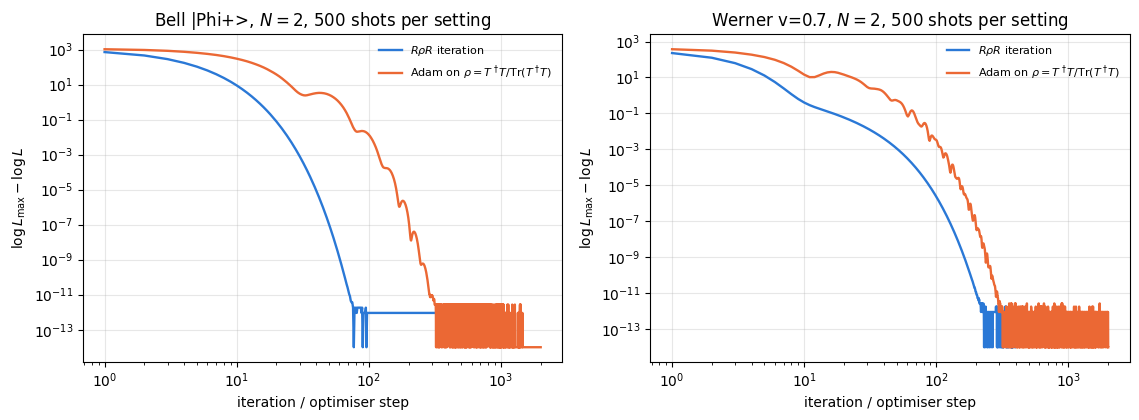

In [26]:
# ==============================================================================
# FIGURE: the two maximum-likelihood optimisers side by side
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for i, sname in enumerate(["Bell |Phi+>", "Werner v=0.7"]):
    ha, hb = grad_hist[sname]
    best = max(ha[-1], hb[-1])
    axes[i].semilogy(np.arange(1, len(ha) + 1), np.clip(best - ha, 1e-14, None), color=PALETTE[0], lw=1.7,
                     label=r"$R\rho R$ iteration")
    axes[i].semilogy(np.arange(1, len(hb) + 1), np.clip(best - hb, 1e-14, None), color=PALETTE[1], lw=1.7,
                     label="Adam on $\\rho=T^\\dagger T/\\mathrm{Tr}(T^\\dagger T)$")
    axes[i].set_xlabel("iteration / optimiser step"); axes[i].set_ylabel(r"$\log L_{\max}-\log L$")
    axes[i].set_title(f"{sname}, $N=2$, {M_CMP} shots per setting")
    axes[i].set_xscale("log"); axes[i].legend(fontsize=8)
fig.tight_layout(); plt.show()

The two algorithms reach the same maximum of the likelihood and the *same density matrix*: for these data sets the Frobenius
difference lies between $10^{-16}$ and $10^{-12}$, i.e. they agree to (nearly) machine precision. A hand-derived fixed-point
iteration and a generic automatic-differentiation optimiser, written independently, produce the same answer, which is about as strong
a validation as one can get without an analytic solution.

Per *step* the $R\rho R$ iteration is the more efficient of the two here: it reaches round-off in about $80$ (Bell) and $250$
(Werner) iterations, whereas Adam needs a few hundred steps on a decaying learning-rate schedule (the run budgets $2000$). With
`decay=1.0` the Adam fit of the Bell data keeps oscillating around the optimum on the boundary instead of settling; re-run the cell
to see it. The gradient route wins on *generality*: change the cost (add a prior, a regulariser, a different noise model, process
instead of state tomography) and the same three lines still work, because `jax.grad` does not care what the cost is.

> **Physics insight.** The second table scores the same data with the *true* state. It always does worse than the maximiser (the
> assertion checks this), because the maximiser is fitted to the data, fluctuations included. For the same reason the maximal
> $\log L$ per shot says nothing about how close the estimate is to the truth: it can even lie *above* the value $\sum_jp_j\log p_j/3^N$
> that the true state attains for infinite data (compare the last two columns). How far the estimate is from the truth has to be
> measured with a distance between states, which is the subject of the next sections.

## 15. Assessment I: accuracy versus the number of shots, with bootstrap error bars

We now have three estimators and compare them on the same data:

| label | definition | physical? | unbiased? |
|---|---|---|---|
| LIN | ordinary least squares, Eq. (8) | no | yes |
| LIN+proj | LIN followed by the 2-norm projection of Section 11 | yes | no |
| MLE | maximiser of Eq. (11), by $R\rho R$ | yes | no |

### 15.1 Figures of merit

* **Trace distance** $D(\hat\rho,\rho)=\tfrac12\lVert\hat\rho-\rho\rVert_1$ — the operationally meaningful distance: it bounds the
  difference of *any* measurement probability on the two states. It is a norm of the error, so it decreases like $1/\sqrt M$.
* **Fidelity** $F=\langle\psi\vert\hat\rho\vert\psi\rangle$ for a pure target. This is a **linear** functional of
  $\hat\rho$, and LIN is unbiased, so $\mathbb{E}[F_{\rm LIN}]=1$ *exactly*, for any number of shots — the fidelity of the raw
  linear-inversion estimate fluctuates around 1 and is frequently larger than 1 (and for the Bell state, as we shall see, it is
  pinned to exactly 1). The projected and maximum-likelihood estimates are restricted to physical states, where $F\le1$, so their
  *average* fidelity is strictly below 1: a bias that vanishes only as $M\to\infty$. Reporting "the fidelity of the reconstructed
  state" without saying which estimator produced it is meaningless.

### 15.2 The bootstrap

In a real experiment there is only **one** data set, so error bars cannot come from repetitions. The bootstrap replaces the unknown
true distribution by the observed one: treat the measured frequencies $\hat p(s\vert b)=n_{b,s}/M$ as if they were the truth, draw
$B$ new synthetic data sets of the same size from them, re-run the *entire* estimation pipeline on each, and use the spread of the
resulting estimates as the error bar. It is nothing but Monte-Carlo error propagation through a pipeline that is too complicated
(a projection, an iterative fit) to differentiate by hand — and in JAX it is one `vmap`.

We first do what only a simulation can do — many *independent* experiments — and then check that the bootstrap,
which a laboratory can actually perform, reproduces the same error bar.

In [27]:
# ==============================================================================
# EXPERIMENT: trace distance and fidelity vs shots, three estimators, 16 independent data sets per point
# ==============================================================================
N, N_SETS, MLE_IT = 2, 64, 400
SHOTS_SCAN = (20, 60, 200, 600, 2000, 6000)
set2, PHI2, SIGN2, COMPAT2 = all_settings(N), povm_vectors(N), sign_table(N), compat_table(N)
rho_scan = to_dm(bell_state("phi+"))
rho_scan_m = dm_matrix(rho_scan)
psi_scan = jnp.asarray(bell_state("phi+")).reshape(-1)
p_scan = all_setting_probs(rho_scan, set2)


def estimate_three(counts):
    """LIN, LIN+proj and MLE from one table of counts. Returns a (3, d, d) stack of density matrices."""
    rho_lin = rho_from_pauli_vector(linear_inversion(counts, SIGN2, COMPAT2), N)
    rho_prj = project_physical(rho_lin)
    rho_mle = mle_rrhor(counts_vector(counts, N), PHI2, n_iter=MLE_IT, eps=None)[0]
    return jnp.stack([rho_lin, rho_prj, rho_mle])


def metrics(rhos):
    """(trace distance, fidelity with the pure target) for each of the three estimates."""
    D = jax.vmap(lambda r: trace_distance(r, rho_scan_m))(rhos)
    F = jax.vmap(lambda r: jnp.real(jnp.vdot(psi_scan, r @ psi_scan)))(rhos)
    return jnp.stack([D, F])


@partial(jax.jit, static_argnums=1)
def scan_shots(key, shots):
    """N_SETS independent experiments at `shots` shots per setting -> metrics of shape (N_SETS, 2, 3)."""
    return jax.vmap(lambda k: metrics(estimate_three(counts_from_probs(k, p_scan, shots))))(
        jax.random.split(key, N_SETS))


labels3 = ["LIN", "LIN+proj", "MLE"]
res = {}
print(f"{'M':>6s} " + " ".join(f"{l + ' D':>16s}" for l in labels3) + "   " + " ".join(f"{l + ' F':>16s}" for l in labels3))
for shots in SHOTS_SCAN:
    out = np.asarray(scan_shots(jax.random.PRNGKey(1000 + shots), shots))       # (N_SETS, 2, 3)
    res[shots] = out
    mD, sD = out[:, 0, :].mean(0), out[:, 0, :].std(0, ddof=1) / np.sqrt(N_SETS)
    mF, sF = out[:, 1, :].mean(0), out[:, 1, :].std(0, ddof=1) / np.sqrt(N_SETS)
    print(f"{shots:6d} " + " ".join(f"{mD[i]:8.4f}+-{sD[i]:<6.4f}" for i in range(3)) + "   "
          + " ".join(f"{mF[i]:8.4f}+-{sF[i]:<6.4f}" for i in range(3)))

# local slopes d log(error) / d log M between neighbouring budgets: -1/2 for a 1/sqrt(M) law, -1 for a 1/M law
lM = np.log(np.array(SHOTS_SCAN, dtype=float))
curves = {f"D {labels3[i]}": [res[m][:, 0, i].mean() for m in SHOTS_SCAN] for i in range(3)}
curves.update({f"1-F {labels3[i]}": [1 - res[m][:, 1, i].mean() for m in SHOTS_SCAN] for i in (1, 2)})
print("\nlocal slopes between neighbouring M:")
for name, v in curves.items():
    print(f"   {name:>13s}: " + "  ".join(f"{x:+.2f}" for x in np.diff(np.log(v)) / np.diff(lM)))

     M            LIN D       LIN+proj D            MLE D              LIN F       LIN+proj F            MLE F


    20   0.2703+-0.0067   0.1712+-0.0047   0.1103+-0.0039     1.0000+-0.0000   0.9208+-0.0028   0.9869+-0.0009


    60   0.1511+-0.0045   0.0993+-0.0028   0.0598+-0.0022     1.0000+-0.0000   0.9564+-0.0018   0.9961+-0.0003


   200   0.0807+-0.0022   0.0553+-0.0016   0.0329+-0.0011     1.0000+-0.0000   0.9769+-0.0010   0.9988+-0.0001


   600   0.0483+-0.0013   0.0340+-0.0009   0.0201+-0.0007     1.0000+-0.0000   0.9871+-0.0005   0.9996+-0.0000


  2000   0.0261+-0.0008   0.0181+-0.0005   0.0105+-0.0004     1.0000+-0.0000   0.9927+-0.0003   0.9999+-0.0000


  6000   0.0160+-0.0005   0.0111+-0.0004   0.0064+-0.0002     1.0000+-0.0000   0.9956+-0.0002   1.0000+-0.0000

local slopes between neighbouring M:
           D LIN: -0.53  -0.52  -0.47  -0.51  -0.45
      D LIN+proj: -0.50  -0.49  -0.44  -0.53  -0.44
           D MLE: -0.56  -0.50  -0.45  -0.54  -0.45
    1-F LIN+proj: -0.54  -0.53  -0.53  -0.48  -0.46
         1-F MLE: -1.11  -1.01  -0.89  -1.08  -0.89


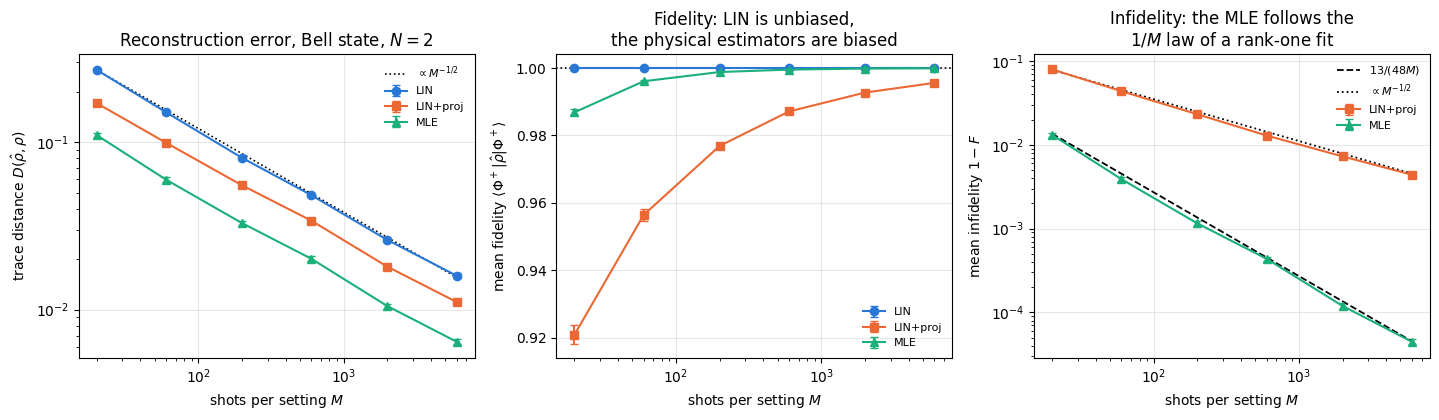

In [28]:
# ==============================================================================
# FIGURE: 1/sqrt(M) scaling of the trace distance, the fidelity bias, and the 1/M law of the MLE
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))
Ms = np.array(SHOTS_SCAN, dtype=float)
for i, lab in enumerate(labels3):
    mD = np.array([res[m][:, 0, i].mean() for m in SHOTS_SCAN])
    sD = np.array([res[m][:, 0, i].std(ddof=1) / np.sqrt(N_SETS) for m in SHOTS_SCAN])
    axes[0].errorbar(Ms, mD, yerr=sD, fmt=MARKERS[i] + "-", color=PALETTE[i], capsize=3, label=lab)
ref = res[SHOTS_SCAN[0]][:, 0, 0].mean() * np.sqrt(Ms[0] / Ms)
axes[0].plot(Ms, ref, "k:", lw=1.2, label=r"$\propto M^{-1/2}$")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("shots per setting $M$"); axes[0].set_ylabel(r"trace distance $D(\hat\rho,\rho)$")
axes[0].set_title(r"Reconstruction error, Bell state, $N=2$"); axes[0].legend(fontsize=8)

for i, lab in enumerate(labels3):
    mF = np.array([res[m][:, 1, i].mean() for m in SHOTS_SCAN])
    sF = np.array([res[m][:, 1, i].std(ddof=1) / np.sqrt(N_SETS) for m in SHOTS_SCAN])
    axes[1].errorbar(Ms, mF, yerr=sF, fmt=MARKERS[i] + "-", color=PALETTE[i], capsize=3, label=lab)
axes[1].axhline(1.0, color="k", ls=":", lw=1.2)
axes[1].set_xscale("log")
axes[1].set_xlabel("shots per setting $M$"); axes[1].set_ylabel(r"mean fidelity $\langle\Phi^+\vert\hat\rho\vert\Phi^+\rangle$")
axes[1].set_title("Fidelity: LIN is unbiased,\nthe physical estimators are biased")
axes[1].legend(fontsize=8, loc="lower right")

# panel 3: the same information as infidelity, where the 1/M law of the MLE becomes visible
C_MLE = 13 / 48                                          # asymptotic constant derived in the text below
for i in (1, 2):
    mI = np.array([1 - res[m][:, 1, i].mean() for m in SHOTS_SCAN])
    sI = np.array([res[m][:, 1, i].std(ddof=1) / np.sqrt(N_SETS) for m in SHOTS_SCAN])
    axes[2].errorbar(Ms, mI, yerr=sI, fmt=MARKERS[i] + "-", color=PALETTE[i], capsize=3, label=labels3[i])
axes[2].plot(Ms, C_MLE / Ms, "k--", lw=1.3, label=r"$13/(48M)$")
axes[2].plot(Ms, 0.35 / np.sqrt(Ms), "k:", lw=1.3, label=r"$\propto M^{-1/2}$")
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_xlabel("shots per setting $M$"); axes[2].set_ylabel(r"mean infidelity $1-F$")
axes[2].set_title("Infidelity: the MLE follows the\n$1/M$ law of a rank-one fit")
axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

In [29]:
# ==============================================================================
# CHECKPOINT: the CONSTANT of the 1/M law, measured with many more data sets
# ==============================================================================
# The six points of the figure carry only N_SETS = 64 experiments each: enough to show the 1/M slope, far too few
# to pin a constant to a few per cent (their own scatter is +-6%). We therefore re-measure it at two shot numbers
# with R_LAW independent data sets each, which is the only way this prediction can actually be falsified.
R_LAW = 1500


@partial(jax.jit, static_argnums=1)
def mle_infidelity_batch(key, shots):
    """1 - <Phi+|rho_MLE|Phi+> for R_LAW independent experiments at `shots` shots per setting."""
    def one(k):
        rm = mle_rrhor(counts_vector(counts_from_probs(k, p_scan, shots), N), PHI2, n_iter=MLE_IT)[0]
        return 1.0 - jnp.real(jnp.vdot(psi_scan, rm @ psi_scan))
    return jax.vmap(one)(jax.random.split(key, R_LAW))


print(f"{'M':>6s} {'data sets':>10s} {'M (1 - F_MLE)':>22s}")
law_val, law_se = [], []
for shots in (200, 1000):
    a = np.asarray(mle_infidelity_batch(jax.random.PRNGKey(8000 + shots), shots))
    law_val.append(shots * a.mean())
    law_se.append(shots * a.std(ddof=1) / np.sqrt(R_LAW))
    print(f"{shots:6d} {R_LAW:10d} {law_val[-1]:14.4f} +- {law_se[-1]:.4f}")
law_val, law_se = np.array(law_val), np.array(law_se)
pooled = float(np.sum(law_val / law_se ** 2) / np.sum(1 / law_se ** 2))
pooled_se = float(1 / np.sqrt(np.sum(1 / law_se ** 2)))
print(f"\nCHECKPOINT measured constant = {pooled:.4f} +- {pooled_se:.4f}")
print(f"           predicted 13/48   = {C_MLE:.4f}   -> {abs(pooled - C_MLE) / pooled_se:4.1f} sigma away")
print(f"           (a naive 1/4      = {0.25:.4f}   -> {abs(pooled - 0.25) / pooled_se:4.1f} sigma away: the "
      f"6-point scan above cannot tell these apart, this measurement can)")
assert abs(pooled - C_MLE) < 3 * pooled_se         # the derived constant passes ...
assert abs(pooled - 0.25) > 3 * pooled_se           # ... and the wrong control 1/4 must FAIL: the test has teeth

     M  data sets          M (1 - F_MLE)


   200       1500         0.2744 +- 0.0041


  1000       1500         0.2699 +- 0.0042

CHECKPOINT measured constant = 0.2722 +- 0.0029
           predicted 13/48   = 0.2708   ->  0.5 sigma away
           (a naive 1/4      = 0.2500   ->  7.6 sigma away: the 6-point scan above cannot tell these apart, this measurement can)


All three panels behave as the theory of Sections 8 and 15.1 predicts.

* The trace distance of all three estimators falls like $M^{-1/2}$ (the dotted reference line): the printed local slopes between
  neighbouring budgets lie between $-0.44$ and $-0.56$ and scatter around $-1/2$ without a trend. The two *physical* estimators are
  uniformly better than raw linear inversion, because the positivity constraint is information about the state. At every budget the
  ordering is MLE $<$ LIN+proj $<$ LIN; the ratio LIN/LIN+proj falls from $1.58$ to $1.44$ and the ratio LIN+proj/MLE grows from
  $1.55$ to $1.73$ across the scan.
* The fidelity of LIN is exactly $1.0000$ at every shot number, with *zero* scatter. That is the extreme case of unbiasedness:
  $F_{\rm LIN}=\tfrac14\big(1+\hat r_{XX}-\hat r_{YY}+\hat r_{ZZ}\big)$, and $XX$, $YY$, $ZZ$ are stabilisers of $\vert\Phi^+\rangle$
  with $r_P=\pm1$, so by Eq. (9) their estimates carry no shot noise whatsoever — every single shot of those settings gives the
  same sign. Meanwhile LIN+proj and MLE report fidelities **below** 1 that creep upwards as the statistics improve: for a device
  that really does prepare a perfect Bell pair, a projected tomography with $M=200$ shots per setting reports $F\approx0.977$. The
  infidelity of LIN+proj falls like $M^{-1/2}$ (local slopes $-0.46$ to $-0.54$, dotted line in the third panel).
* The maximum-likelihood curve follows a $1/M$ law over the whole range (local slopes $-0.89$ to $-1.11$ around $-1$, without a
  trend), *faster* than the $1/\sqrt M$ of the trace distance, and
  the constant is fixed by theory. Section 13.3 gave the mechanism: the six unobserved outcomes pin the estimate to a **rank-one** state,
  which has only $2(2^N-1)=6$ real parameters instead of $15$; moving that pure state by an angle $\delta$ costs $\sim M\delta^2$
  in log-likelihood while the random pull of the six mismatched settings gains $\sim\delta\sqrt M$, so $\delta\sim1/\sqrt M$ and
  $1-F=\delta^2\sim1/M$. The **constant** follows from the standard local analysis of a maximum-likelihood estimator on that
  six-dimensional manifold. Write the estimate as $\vert\psi(\theta)\rangle\propto\vert\Phi^+\rangle+\sum_{k=1}^{3}(x_k+iy_k)\vert
  e_k\rangle$ with $\theta=(x_1,y_1,\dots,y_3)$, so that $1-F=\lvert\theta\rvert^2$ to leading order. Expanding
  $\log L=\sum_{j:\,n_j>0}n_j\log p_j(\theta)$ around $\theta=0$ gives a score with covariance $M\,\mathcal{I}$ and an expected
  curvature $M(\mathcal{I}+\mathcal{Q})$, where $\mathcal{I}$ is the classical Fisher information per shot summed over the nine
  settings (restricted, as the likelihood is, to the outcomes that actually occur) and $\mathcal{Q}$ is the curvature of the total
  *unobserved* probability $\sum_{\rm forb}p_j(\theta)$, which is what keeps the optimum from running away. The two pieces are
  simultaneously diagonal here: $\mathcal{Q}=4\,\mathbb 1_6$, and $\mathcal{I}$ has eigenvalues $20,20,20,8,8,8$ (the first triple
  are the three directions that the deterministic settings can see to first order). Hence

$$\mathbb{E}\big[1-F\big]\ \simeq\ \frac{1}{M}\,\mathrm{Tr}\Big[(\mathcal{I}+\mathcal{Q})^{-1}\mathcal{I}\,(\mathcal{I}+\mathcal{Q})^{-1}\Big]
  =\frac{1}{M}\sum_i\frac{\mathcal{I}_i}{(\mathcal{I}_i+4)^2}=\frac{1}{M}\left(\frac{3\cdot20}{24^2}+\frac{3\cdot8}{12^2}\right)
  =\frac{13}{48\,M}\approx\frac{0.2708}{M}.$$

  That is the dashed line of the third panel. The checkpoint printed under the figure measures the constant properly — with
  $1500$ data sets instead of $64$, because the six points of the scan cannot separate $13/48$ from, say, $1/4$, and a reference
  line that nobody tests is decoration. The contrast with a *generic* pure
  state is sharp: there the unconstrained maximum-likelihood estimate of a boundary state has infidelity $O(M^{-1/2})$, not
  $O(M^{-1})$, because infidelity is *linear* rather than quadratic in the error along a direction with a zero eigenvalue
  (Mahler et al. 2013). The stabiliser state escapes that fate because its deterministic outcomes make the estimation error along
  exactly those directions vanish at the same rate. Section 17 shows both regimes side by side.

### 15.3 Bootstrap error bars from a single data set

Now the laboratory version: one data set, $B$ bootstrap resamples, and the claim that the spread over resamples estimates the spread
over experiments. We test the claim on two states — one **inside** the physical set (a Werner state) and one **on its boundary**
(the Bell state) — for three quantities a laboratory really reports: the trace distance to the target, the fidelity with the target,
and the purity of the reconstruction. The reference "true" spread comes from $150$ independent simulated experiments, which only a
simulation can produce.

In [30]:
# ==============================================================================
# EXPERIMENT: bootstrap error bars vs the true (across-experiment) error bars
# ==============================================================================
B_BOOT, M_BOOT, N_TRUE, B_WRONG = 250, 200, 150, 100
boot_states = {"Werner v=0.6 (interior)": dm_tensor(mixed_with_identity(dm_matrix(to_dm(bell_state("psi-"))), 0.6), N),
               "Bell |Phi+> (boundary)": to_dm(bell_state("phi+"))}
QNAMES = ["trace distance", "fidelity", "purity"]
EST2 = ["LIN+proj", "MLE"]


def lab_report(counts, rho_target_m):
    """What a laboratory quotes: (trace distance, fidelity, purity) for the two PHYSICAL estimators. Shape (3, 2)."""
    rl = rho_from_pauli_vector(linear_inversion(counts, SIGN2, COMPAT2), N)
    st = jnp.stack([project_physical(rl), mle_rrhor(counts_vector(counts, N), PHI2, n_iter=MLE_IT)[0]])
    return jnp.stack([jax.vmap(lambda r: trace_distance(r, rho_target_m))(st),
                      jax.vmap(lambda r: fidelity_dm(rho_target_m, r))(st),
                      jax.vmap(purity)(st)])


boot_sd, wrong_sd = {}, {}
for sname, rho in boot_states.items():
    rho_m, p_true = dm_matrix(rho), all_setting_probs(rho, set2)
    run = jax.jit(jax.vmap(lambda k, p: lab_report(counts_from_probs(k, p, M_BOOT), rho_m), in_axes=(0, None)))
    true_out = np.asarray(run(jax.random.split(jax.random.PRNGKey(4242), N_TRUE), p_true))        # (N_TRUE, 3, 2)
    counts_one = counts_from_probs(jax.random.PRNGKey(99), p_true, M_BOOT)                        # THE single experiment
    p_hat = counts_one / jnp.sum(counts_one, axis=1, keepdims=True)
    boot_out = np.asarray(run(jax.random.split(jax.random.PRNGKey(5150), B_BOOT), p_hat))         # (B_BOOT, 3, 2)
    # CONTROL: a WRONG bootstrap that resamples 3^N M shots per setting (the total budget instead of the per-setting one)
    run_wrong = jax.jit(jax.vmap(lambda k, p: lab_report(counts_from_probs(k, p, 3 ** N * M_BOOT), rho_m), in_axes=(0, None)))
    wrong_out = np.asarray(run_wrong(jax.random.split(jax.random.PRNGKey(5151), B_WRONG), p_hat))   # (B_WRONG, 3, 2)
    point = np.asarray(lab_report(counts_one, rho_m))
    print(f"{sname}:  one experiment, M = {M_BOOT} shots per setting, {B_BOOT} bootstrap resamples, "
          f"{N_TRUE} independent experiments for reference")
    print(f"{'quantity':>16s} {'estimator':>10s} {'point value':>12s} {'bootstrap sd':>14s} {'true sd':>10s} {'ratio':>7s}")
    for qi, qn in enumerate(QNAMES):
        for ei, en in enumerate(EST2):
            sb, st_ = float(boot_out[:, qi, ei].std(ddof=1)), float(true_out[:, qi, ei].std(ddof=1))
            boot_sd[(sname, qn, en)] = (sb, st_)
            wrong_sd[(sname, qn, en)] = (float(wrong_out[:, qi, ei].std(ddof=1)), st_)
            rat = f"{sb / st_:7.2f}" if max(sb, st_) > 1e-9 else "    n/a"   # n/a: BOTH spreads vanish (see below)
            print(f"{qn:>16s} {en:>10s} {point[qi, ei]:12.4f} {sb:14.4f} {st_:10.4f} {rat}")
    print()

ratios = {k: s[0] / s[1] for k, s in boot_sd.items() if max(s) > 1e-9}
degenerate = [k for k, s in boot_sd.items() if max(s) <= 1e-9]
worst = max(max(r, 1 / r) for r in ratios.values())
print(f"CHECKPOINT over the {len(ratios)} non-degenerate combinations of state, quantity and estimator, every bootstrap "
      f"standard deviation is within a factor {worst:.2f} of the across-experiment one.")
print(f"({len(degenerate)} combination(s) had zero spread in BOTH samples: {degenerate})")
assert worst < 2.0
ratios_w = [s[0] / s[1] for s in wrong_sd.values() if max(s) > 1e-9]
worst_w = max(max(r, 1 / r) for r in ratios_w)
print(f"CONTROL a bootstrap that resamples {3 ** N * M_BOOT} instead of {M_BOOT} shots per setting: ratios "
      f"{min(ratios_w):.2f} to {max(ratios_w):.2f}, worst factor {worst_w:.2f} -> fails the factor-2 test, as it must")
assert worst_w > 2.0

Werner v=0.6 (interior):  one experiment, M = 200 shots per setting, 250 bootstrap resamples, 150 independent experiments for reference
        quantity  estimator  point value   bootstrap sd    true sd   ratio
  trace distance   LIN+proj       0.0909         0.0226     0.0195    1.16
  trace distance        MLE       0.0860         0.0227     0.0197    1.15
        fidelity   LIN+proj       0.9871         0.0265     0.0148    1.79
        fidelity        MLE       0.9896         0.0235     0.0142    1.66
          purity   LIN+proj       0.5375         0.0318     0.0291    1.09
          purity        MLE       0.5349         0.0316     0.0294    1.07



Bell |Phi+> (boundary):  one experiment, M = 200 shots per setting, 250 bootstrap resamples, 150 independent experiments for reference
        quantity  estimator  point value   bootstrap sd    true sd   ratio
  trace distance   LIN+proj       0.0343         0.0155     0.0131    1.18
  trace distance        MLE       0.0217         0.0123     0.0095    1.30
        fidelity   LIN+proj       0.9757         0.0095     0.0079    1.20
        fidelity        MLE       0.9995         0.0011     0.0007    1.46
          purity   LIN+proj       0.9532         0.0180     0.0153    1.18
          purity        MLE       1.0000         0.0000     0.0000     n/a

CHECKPOINT over the 11 non-degenerate combinations of state, quantity and estimator, every bootstrap standard deviation is within a factor 1.79 of the across-experiment one.
(1 combination(s) had zero spread in BOTH samples: [('Bell |Phi+> (boundary)', 'purity', 'MLE')])
CONTROL a bootstrap that resamples 1800 instead of 200 shots per se

The bootstrap works. Every error bar obtained from the *single* data set reproduces the across-experiment one within a factor of
about $1.8$, and the comparison is itself noisy, since $150$ experiments determine a standard deviation only to $\pm6\%$ and the
bootstrap sample is drawn around one particular $\hat\rho$. The agreement is tightest for the trace distance and the purity and
loosest for the Uhlmann fidelity of the Werner state (ratios $1.79$ and $1.66$). All eleven ratios are *above* one. They come from
a single data set per state and are therefore strongly correlated, so this run alone does not establish a systematic
over-estimate; resampling around a $\hat p$ that is itself noisy and the non-smoothness of the estimators at the boundary are the
two mechanisms that can produce one. The control line shows that the factor-2 test has discriminating power: a bootstrap with the
per-setting shot number replaced by the total budget, a plausible coding slip, gives error bars two to five times too small and
fails it. All three quantities are **non-linear**
functionals of $\hat\rho$ obtained after a projection or an iterative fit: their error bars could not have been produced by
propagating Eq. (9) by hand. This is the practical recipe: **quote $\hat\rho$ together with a bootstrap error bar on every number
you derive from it.**

The table also previews two effects that Section 17 explains. For the Werner state the reconstructed **purity** comes out above the
true value $0.52$ for both estimators. One data set cannot separate bias from noise here (the spread is $0.03$), but a bias of
that sign is expected: for the unbiased LIN estimate $\mathbb E\,\mathrm{Tr}\hat\rho^2=\mathrm{Tr}\rho^2+\mathbb E\lVert\hat\rho-\rho\rVert_F^2$,
and Eq. (10) gives $0.012$ for this state at $M=200$. For the Bell state the maximum-likelihood purity is exactly $1$ in every
single resample, with *zero* spread (hence the "n/a" in the ratio column: there is nothing to compare). That is the stabiliser
phenomenon of Section 13.3: the deterministic outcomes pin the estimate to a **rank-one** state — a state whose *direction* still
fluctuates, as the non-zero spread of its fidelity shows, but whose spectrum does not.

> **Common pitfall.** The bootstrap estimates the *statistical* spread only. It is blind to systematic errors (miscalibrated
> rotations, cross-talk, drifts) and it inherits the bias of the estimator: a bootstrap around a biased estimate gives a tight error
> bar around a slightly wrong value. It is also a large-sample tool derived for *smooth* models, and a parameter sitting on the
> boundary of its domain — every nearly pure state — is the textbook example of a non-smooth one, so treat bootstrap intervals for
> high-purity states as indicative rather than exact.

## 16. Assessment II: estimators across state families

A single state makes a poor benchmark. We now run the full pipeline on a zoo: pure states on the boundary (Bell, GHZ, W), mixed states in the
interior (Werner, depolarised GHZ), and a random mixed state, for $N=2$ and $N=3$, at a fixed budget of $M$ shots per setting.
For the mixed states we use the Uhlmann fidelity $F(\rho,\hat\rho)$; because it requires $\sqrt\rho$ we always put the *true*
(physical) state inside the square roots, so that the square root always exists. That makes the expression computable for a
non-physical $\hat\rho$, but it no longer measures anything: the engine's `fidelity_dm` clips the negative eigenvalues of
$\sqrt\rho\,\hat\rho\sqrt\rho$ before taking square roots, so the number it returns for an unphysical estimate can exceed $1$.
**The F entries of the LIN column below are therefore diagnostics only.**

In [31]:
# ==============================================================================
# EXPERIMENT: LIN vs LIN+proj vs MLE on six states, 8 independent data sets each
# ==============================================================================
M_ZOO, N_SETS_ZOO, MLE_IT_ZOO = 500, 8, 250


def build_zoo():
    """A small zoo of two- and three-qubit states: pure, mixed and random."""
    bell = to_dm(bell_state("phi+"))
    werner = dm_tensor(mixed_with_identity(dm_matrix(to_dm(bell_state("psi-"))), 0.7), 2)
    rand2 = dm_tensor(rdm(haar_state(jax.random.PRNGKey(6), 4), (0, 1)), 2)
    ghz, w3 = to_dm(ghz_state(3)), to_dm(w_state(3))
    noisy = to_dm(ghz_state(3))
    for q in range(3):
        noisy = apply_kraus_dm(noisy, kraus_depolarizing(0.10), [q])
    return [("Bell |Phi+>", bell), ("Werner v=0.7", werner), ("random mixed", rand2),
            ("GHZ_3", ghz), ("W_3", w3), ("GHZ_3 + depol. 0.10", noisy)]


def run_zoo_state(rho, shots, n_sets, mle_it, seed):
    """Mean trace distance, fidelity and min-eigenvalue for the three estimators on `n_sets` data sets."""
    n = rho.ndim // 2
    sett, PHI, SIGN, COMPAT = all_settings(n), povm_vectors(n), sign_table(n), compat_table(n)
    p_true, rho_m = all_setting_probs(rho, sett), dm_matrix(rho)

    def one(k):
        c = counts_from_probs(k, p_true, shots)
        rl = rho_from_pauli_vector(linear_inversion(c, SIGN, COMPAT), n)
        rp = project_physical(rl)
        rm = mle_rrhor(counts_vector(c, n), PHI, n_iter=mle_it, eps=None)[0]
        st = jnp.stack([rl, rp, rm])
        D = jax.vmap(lambda r: trace_distance(r, rho_m))(st)
        F = jax.vmap(lambda r: fidelity_dm(rho_m, r))(st)          # true state inside the square roots
        L = jax.vmap(lambda r: jnp.linalg.eigvalsh(r)[0])(st)
        return jnp.stack([D, F, L])

    return jax.jit(jax.vmap(one))(jax.random.split(jax.random.PRNGKey(seed), n_sets))


print(f"{M_ZOO} shots per setting, {N_SETS_ZOO} independent data sets, mean +- standard error\n")
print(f"{'state':>21s} {'N':>2s} " + " ".join(f"{l:>28s}" for l in labels3))
print(f"{'':>21s} {'':>2s} " + " ".join(f"{'D          F      lmin':>28s}" for _ in labels3))
zoo_out = {}
for si, (name, rho) in enumerate(build_zoo()):
    out = np.asarray(run_zoo_state(rho, M_ZOO, N_SETS_ZOO, MLE_IT_ZOO, 700 + si))   # (n_sets, 3, 3)
    zoo_out[name] = out
    m, s = out.mean(0), out.std(0, ddof=1) / np.sqrt(N_SETS_ZOO)
    cells = [f"{m[0, i]:.4f} {m[1, i]:8.4f} {m[2, i]:+8.4f}" for i in range(3)]
    print(f"{name:>21s} {rho.ndim // 2:2d} " + " ".join(f"{c:>28s}" for c in cells))
print("\n(D = trace distance, F = Uhlmann fidelity with the true state, lmin = smallest eigenvalue of the estimate)")

500 shots per setting, 8 independent data sets, mean +- standard error

                state  N                          LIN                     LIN+proj                          MLE
                               D          F      lmin       D          F      lmin       D          F      lmin


          Bell |Phi+>  2     0.0514   1.0000  -0.0295     0.0355   0.9858  -0.0000     0.0217   0.9995  -0.0000


         Werner v=0.7  2     0.0645   0.9894  +0.0433     0.0645   0.9894  +0.0433     0.0632   0.9903  +0.0456


         random mixed  2     0.0612   0.9905  +0.0252     0.0612   0.9905  +0.0252     0.0596   0.9904  +0.0240


                GHZ_3  3     0.1028   1.0000  -0.0406     0.0438   0.9785  -0.0000     0.0203   0.9996  -0.0000


                  W_3  3     0.1070   1.0024  -0.0444     0.0449   0.9788  -0.0000     0.0216   0.9995  -0.0000


  GHZ_3 + depol. 0.10  3     0.1138   0.9448  -0.0083     0.1101   0.9352  +0.0001     0.1007   0.9553  +0.0013

(D = trace distance, F = Uhlmann fidelity with the true state, lmin = smallest eigenvalue of the estimate)


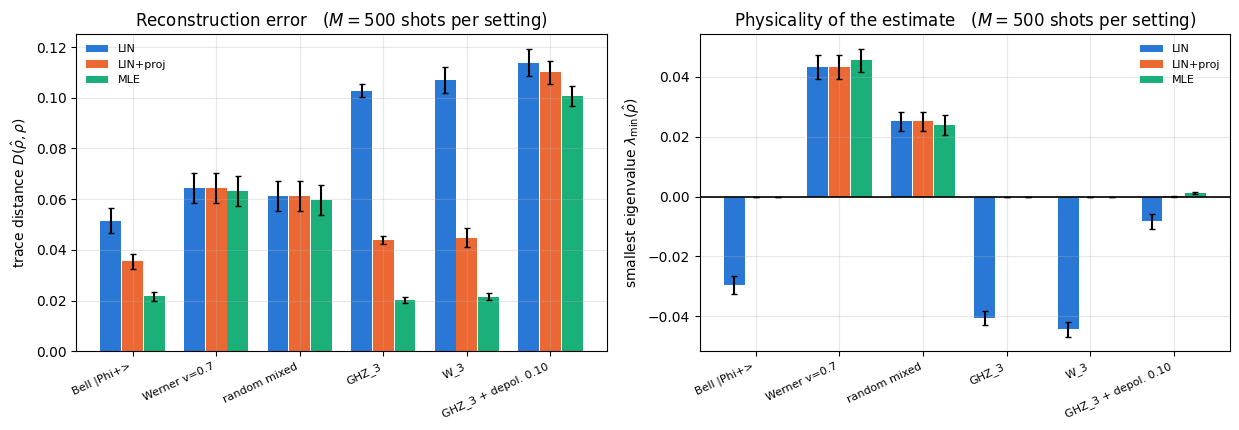

In [32]:
# ==============================================================================
# FIGURE: reconstruction error and physicality per state and estimator
# ==============================================================================
names = list(zoo_out)
x = np.arange(len(names))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for i, lab in enumerate(labels3):
    D = np.array([zoo_out[n][:, 0, i].mean() for n in names])
    Ds = np.array([zoo_out[n][:, 0, i].std(ddof=1) / np.sqrt(N_SETS_ZOO) for n in names])
    L = np.array([zoo_out[n][:, 2, i].mean() for n in names])
    Ls = np.array([zoo_out[n][:, 2, i].std(ddof=1) / np.sqrt(N_SETS_ZOO) for n in names])
    axes[0].bar(x + (i - 1) * 0.26, D, width=0.25, yerr=Ds, capsize=2, color=PALETTE[i], label=lab)
    axes[1].bar(x + (i - 1) * 0.26, L, width=0.25, yerr=Ls, capsize=2, color=PALETTE[i], label=lab)
axes[1].axhline(0.0, color="k", lw=1.2)
for ax, ylab, ttl in ((axes[0], r"trace distance $D(\hat\rho,\rho)$", "Reconstruction error"),
                      (axes[1], r"smallest eigenvalue $\lambda_{\min}(\hat\rho)$", "Physicality of the estimate")):
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel(ylab); ax.set_title(ttl + f"   ($M={M_ZOO}$ shots per setting)")
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

Reading the table and the figure:

* The **raw LIN** estimate has a negative eigenvalue for every pure state (right panel) and is the worst reconstruction in trace
  distance for every state in the zoo. There is no state family for which it wins. Its fidelity, by contrast, can exceed 1
  ($F=1.0024$ for $W_3$): the Uhlmann formula defines a fidelity only between two states.
* For the **Werner** and **random mixed** states the three estimators are nearly indistinguishable: the raw estimate is already
  physical (positive $\lambda_{\min}$), so the projection does nothing at all and the maximum-likelihood fit has almost no room to
  improve. The **depolarised GHZ** state is mixed as well, but its six smallest eigenvalues are only $0.031$, so at this budget the
  raw estimate still goes negative (mean $\lambda_{\min}=-0.008$) and the two physical estimators improve on it slightly. The action
  is at and near the boundary.
* For the **pure** states the ordering is large and systematic. For the three-qubit states the projection more than halves the trace
  distance of LIN and maximum likelihood halves it again: $0.103\to0.044\to0.020$ for $\mathrm{GHZ}_3$ and $0.107\to0.045\to0.022$
  for $W_3$; for the Bell state the two factors are $1.45$ and $1.6$. So *how* positivity is enforced matters here: the gain of
  maximum likelihood over the projection costs no extra data, and its infidelity is forty to fifty times smaller.
* At a fixed number of shots per setting, the LIN error doubles from the two-qubit Bell state to the three-qubit GHZ state
  ($0.051\to0.103$), even though three times as many settings are measured: the number of parameters it must fit, $4^N-1$, grows
  faster than the amount of data, and Section 18.1 turns this into a law for the shot cost. Maximum likelihood does not degrade at all here ($0.022\to0.020$) — because for these pure
  states it returns a nearly rank-one estimate, and a rank-one state has only $2(2^N-1)$ parameters ($14$ for $N=3$) instead of
  $4^N-1=63$. Constraints buy accuracy. This is the cost wall of Section 18 seen from the accuracy side.
* The depolarised GHZ state is the hardest of the six for every estimator: it has no saturated Pauli expectations at all, and
  Eq. (9) says the variance of $\hat r_P$ is proportional to $1-r_P^2$.

## 17. Assessment III: the bias of maximum likelihood at the boundary

We saw the fidelity bias in Section 15. Its mechanism is worth making explicit, because it is the main criticism levelled at
maximum-likelihood tomography.

Consider a true state that is **pure**, i.e. has eigenvalues $(1,0,0,\dots)$ — on the boundary of the state space. Noise scatters the
raw estimate in all directions, including outwards. LIN follows the noise faithfully and produces negative eigenvalues; MLE and the
projection cannot, so they **pile up probability at zero**: their smallest eigenvalues come out exactly $0$ (rank deficiency), and,
since the trace is fixed, the largest eigenvalue must come out *below* 1. The result is a state whose fidelity with the true state is
systematically below 1.

For a state deep in the **interior** the estimators are all essentially unbiased as matrices, but the *eigenvalues* are still biased:
the largest is pushed up and the smallest down, because the eigenvalues of a noisy matrix spread out (the same phenomenon that makes
sample-covariance eigenvalues biased in classical statistics).

A third case has appeared twice already and gets its own panel: a **stabiliser** state such as
$\vert\Phi^+\rangle$. Its data contain *deterministic* outcomes (Section 13.3), which push the maximum-likelihood estimate onto the
rank-one manifold — a set with far fewer parameters, where the estimator is much more accurate. This does not contradict the
paragraph above; it says that the *geometry of the data*, not only the position of the true state, decides how a constrained
estimator behaves.

We therefore measure the average estimated spectrum over $120$ independent experiments for three representative states: a
Haar-random **pure** state (generic boundary), the **Bell** state (stabiliser boundary) and the **maximally mixed** state (interior).

In [33]:
# ==============================================================================
# EXPERIMENT: average estimated eigenvalue spectrum -- generic boundary, stabiliser boundary, interior
# ==============================================================================
N, M_BIAS, N_SETS_BIAS, MLE_IT_BIAS = 2, 200, 120, 1500   # 1500: the generic pure state needs far more iterations than the Bell state
set2, PHI2, SIGN2, COMPAT2 = all_settings(N), povm_vectors(N), sign_table(N), compat_table(N)
bias_states = {"Haar-random pure (generic boundary)": to_dm(haar_state(jax.random.PRNGKey(12), 2)),
               "Bell (stabiliser boundary)": to_dm(bell_state("phi+")),
               "maximally mixed (interior)": dm_tensor(jnp.eye(4, dtype=CDTYPE) / 4, N)}


def spectra_purity_fidelity(rho, shots, n_sets, seed):
    """Eigenvalue spectrum, purity and fidelity of the three estimators over `n_sets` independent experiments."""
    p_true, rho_m = all_setting_probs(rho, set2), dm_matrix(rho)

    def one(k):
        c = counts_from_probs(k, p_true, shots)
        rl = rho_from_pauli_vector(linear_inversion(c, SIGN2, COMPAT2), N)
        st = jnp.stack([rl, project_physical(rl), mle_rrhor(counts_vector(c, N), PHI2, n_iter=MLE_IT_BIAS)[0]])
        return (jax.vmap(jnp.linalg.eigvalsh)(st), jax.vmap(purity)(st),
                jax.vmap(lambda r: fidelity_dm(rho_m, r))(st))

    return jax.jit(jax.vmap(one))(jax.random.split(jax.random.PRNGKey(seed), n_sets))


bias_out = {}
for si, (name, rho) in enumerate(bias_states.items()):
    ev, pu, fi = map(np.asarray, spectra_purity_fidelity(rho, M_BIAS, N_SETS_BIAS, 900 + si))
    bias_out[name] = (ev, pu, fi, np.asarray(jnp.linalg.eigvalsh(dm_matrix(rho))))
    print(f"{name}  (true eigenvalues {np.round(bias_out[name][3], 3)}, true purity {float(purity(dm_matrix(rho))):.3f})")
    for i, lab in enumerate(labels3):
        print(f"   {lab:>9s}: mean spectrum {np.round(ev[:, i, :].mean(0), 4)}   "
              f"purity {pu[:, i].mean():.4f}+-{pu[:, i].std(ddof=1) / np.sqrt(N_SETS_BIAS):.4f}   "
              f"fidelity {fi[:, i].mean():.4f}+-{fi[:, i].std(ddof=1) / np.sqrt(N_SETS_BIAS):.4f}   "
              f"P(rank deficient) = {np.mean(ev[:, i, 0] < 1e-9):3.0%}")
    print()

Haar-random pure (generic boundary)  (true eigenvalues [-0.  0.  0.  1.], true purity 1.000)
         LIN: mean spectrum [-4.48e-02 -3.00e-04  4.52e-02  1.00e+00]   purity 1.0052+-0.0038   fidelity 0.9973+-0.0019   P(rank deficient) = 100%
    LIN+proj: mean spectrum [-0.000e+00  9.000e-04  2.270e-02  9.764e-01]   purity 0.9544+-0.0028   fidelity 0.9739+-0.0015   P(rank deficient) = 100%
         MLE: mean spectrum [-0.000e+00  3.000e-04  1.280e-02  9.869e-01]   purity 0.9743+-0.0017   fidelity 0.9851+-0.0009   P(rank deficient) = 100%



Bell (stabiliser boundary)  (true eigenvalues [0. 0. 0. 1.], true purity 1.000)
         LIN: mean spectrum [-4.6800e-02  2.0000e-04  4.3700e-02  1.0029e+00]   purity 1.0105+-0.0005   fidelity 1.0000+-0.0000   P(rank deficient) = 100%
    LIN+proj: mean spectrum [-0.      0.      0.0204  0.9796]   purity 0.9602+-0.0014   fidelity 0.9768+-0.0007   P(rank deficient) = 100%
         MLE: mean spectrum [-0.  0.  0.  1.]   purity 1.0000+-0.0000   fidelity 0.9985+-0.0001   P(rank deficient) = 100%



maximally mixed (interior)  (true eigenvalues [0.25 0.25 0.25 0.25], true purity 0.250)
         LIN: mean spectrum [0.1748 0.2283 0.2728 0.3241]   purity 0.2632+-0.0005   fidelity 0.9864+-0.0006   P(rank deficient) =  0%
    LIN+proj: mean spectrum [0.1748 0.2283 0.2728 0.3241]   purity 0.2632+-0.0005   fidelity 0.9864+-0.0006   P(rank deficient) =  0%
         MLE: mean spectrum [0.1747 0.2282 0.2728 0.3243]   purity 0.2632+-0.0005   fidelity 0.9863+-0.0006   P(rank deficient) =  0%



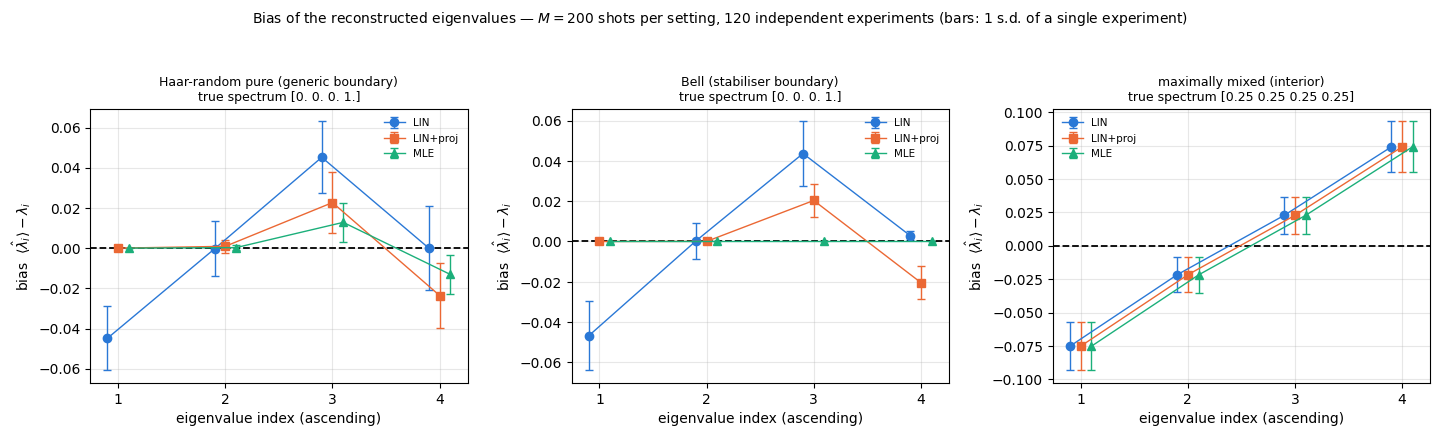

In [34]:
# ==============================================================================
# FIGURE: BIAS of the estimated spectrum (mean estimate minus truth), three regimes
# ==============================================================================
# Plotting the eigenvalues themselves would be useless: the 0-0-0-1 spectrum of a pure state dwarfs every
# deviation. We therefore plot the DEVIATION from the true spectrum, which is exactly the bias we are after.
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
for a, (name, (ev, pu, fi, true_ev)) in zip(axes, bias_out.items()):
    idx = np.arange(1, 5)
    for i, lab in enumerate(labels3):
        a.errorbar(idx + (i - 1) * 0.10, ev[:, i, :].mean(0) - true_ev, yerr=ev[:, i, :].std(0, ddof=1),
                   fmt=MARKERS[i] + "-", lw=1.0, color=PALETTE[i], capsize=3, label=lab)
    a.axhline(0, color="k", lw=1.3, ls="--")
    a.set_xticks(idx); a.set_xlabel("eigenvalue index (ascending)")
    a.set_ylabel(r"bias  $\langle\hat\lambda_i\rangle-\lambda_i$")
    a.set_title(f"{name}\ntrue spectrum {np.round(true_ev + 0.0, 2) + 0.0}", fontsize=9)
    a.legend(fontsize=7.5)
fig.suptitle(f"Bias of the reconstructed eigenvalues — $M={M_BIAS}$ shots per setting, "
             f"{N_SETS_BIAS} independent experiments (bars: 1 s.d. of a single experiment)", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

The figure plots the **bias** of each reconstructed eigenvalue, $\langle\hat\lambda_i\rangle-\lambda_i$, because the eigenvalues
themselves ($0,0,0,1$ for a pure state) would hide every deviation. The three panels separate three genuinely different situations.

* **Generic boundary (Haar-random pure).** This is the textbook picture. LIN scatters the three zero eigenvalues symmetrically
  around zero, so about half of them are negative. The physical estimators cannot go below zero, so their smallest eigenvalues are
  pinned at $0$ in **every** experiment (the printed rank-deficiency probability) and the extra weight has to come out of the
  largest eigenvalue, which lands visibly **below** 1. The mean infidelity of the maximum-likelihood estimate falls only like
  $M^{-1/2}$ here, slower than the $M^{-1}$ of the stabiliser state, because at a zero eigenvalue the infidelity is *linear* rather
  than quadratic in the reconstruction error — the point of Mahler et al. (2013), who also show that one adaptive re-measurement
  in the estimated eigenbasis restores the $M^{-1}$ law. The consequence is the systematic fidelity deficit in the printed table:
  maximum likelihood reports a state that is less pure and slightly rotated away from the truth, and no amount of averaging over
  experiments removes it, because it is a bias. This is the standard criticism of maximum-likelihood tomography: a reported
  "rank-2 state" may be an artefact of finite statistics rather than a physical statement.
* **Stabiliser boundary (Bell).** Here the maximum-likelihood spectrum is $(0,0,0,1)$ — the *exact* true spectrum, with zero spread
  and a purity of exactly 1 in every experiment. Three of the nine settings produce deterministic outcomes, and, as argued in
  Section 13.3, the likelihood then forces the estimate onto the rank-one manifold. Only its *direction* still fluctuates, which is
  why the mean fidelity is below 1 but, at this budget, an order of magnitude closer to it than for the generic pure state (compare
  the two printed fidelities). LIN and LIN+proj never look at the likelihood, do not benefit, and show the same boundary bias as in
  the left panel.

* **Interior (maximally mixed).** All three estimators agree on average and none of them is rank deficient, but the estimated spectra
  are clearly *spread out* relative to the flat true spectrum: the largest eigenvalue is biased up and the smallest down. Every
  quantity computed from the spectrum — purity, von Neumann entropy, entanglement measures — inherits this bias, which is why the
  measured purity comes out above the true $1/4$ for all three estimators. For the unbiased LIN estimate the size of the purity bias
  is predicted: $\mathbb E\,\mathrm{Tr}\hat\rho^2-\mathrm{Tr}\rho^2=\mathbb E\lVert\hat\rho-\rho\rVert_F^2$, which Eq. (10) gives as
  $\tfrac14\big(\tfrac{6}{3M}+\tfrac{9}{M}\big)=0.01375$ at $M=200$ (all $r_P=0$), i.e. an expected purity $0.2638$ against the
  measured $0.2632\pm0.0005$.

> **Numerical practice.** The rank-deficiency column is the one number in this notebook that depends on how long the iteration was
> run, because "rank deficient" means "an eigenvalue below $10^{-9}$" and the $R\rho R$ iteration approaches a rank-deficient
> optimum only geometrically. The Bell data converge in tens of iterations, but the generic pure state needs of order $10^3$: with
> the $250$ iterations used elsewhere in this notebook its residual $\lVert\tilde R\rho-\rho\rVert$ is still $\sim10^{-8}$ and the
> printed probability comes out near $97\%$ instead of $100\%$. The fidelities and purities are insensitive to this (they change in
> the fourth decimal), but a *rank* is a discontinuous function of the spectrum and must never be read off an unconverged fit.

> **Physics insight.** "We measured a fidelity of $0.97$" and "we measured a purity of $0.94$" are statements about an *estimator*
> applied to a finite data set as much as statements about the device. They should be reported with a bootstrap error bar, a statement
> of which estimator was used, and — best of all — a simulation like this one that calibrates the bias at the shot budget actually used.

## 18. The cost wall and the hand-over to classical shadows

### 18.1 Counting the cost

Collect the scalings of everything we have built:

| quantity | scaling | $N=4$ | $N=10$ |
|---|---|---|---|
| measurement settings | $3^N$ | 81 | 59049 |
| POVM elements / rows | $6^N$ | 1296 | $6.0\cdot10^7$ |
| parameters of $\rho$ | $4^N-1$ | 255 | $1.05\cdot10^6$ |
| shots at $M$ per setting | $M\,3^N$ | $81M$ | $59049M$ |
| memory for $\rho$ (complex128) | $16\cdot4^N$ bytes | 4.1 kB | 17 MB |
| one $R\rho R$ iteration | $O(6^N4^N)$ | $3\cdot10^5$ | $6\cdot10^{13}$ |

Three separate walls close in at once: the number of experimental configurations, the size of the object being estimated, and the
number of shots needed to determine that object to a given accuracy. The last one follows from Eq. (10). Write the total budget as
$T=3^NM$ and use $1-r_P^2\le1$:

$$\mathbb{E}\big\lVert\hat\rho_{\rm LIN}-\rho\big\rVert_F^2=\frac{1}{2^N\,T}\sum_{P\neq I}3^{\,w(P)}\big(1-r_P^2\big)
  \ \le\ \frac{1}{2^N\,T}\sum_{w=1}^{N}\binom{N}{w}3^w\cdot3^w=\frac{10^N-1}{2^N\,T}\ <\ \frac{5^N}{T}. \tag{17}$$

The sum counts the $\binom{N}{w}3^w$ Pauli strings of weight $w$, each weighted by $3^w$ because only $3^{N-w}$ of the $3^N$ settings
see it. The bound is attained by the maximally mixed state (all $r_P=0$). A pure state saturates some coordinates and does better,
but only by a lower-order term: for $\vert0\rangle^{\otimes N}$ the $4^N-1$ strings made of $I$ and $Z$ have $r_P=1$ and drop out,
and their weights sum to $\sum_w\binom{N}{w}3^w=4^N-1$, leaving $(10^N-4^N)/(2^NT)$. For a **fixed** Frobenius error the total number of shots therefore grows
like $5^N$, faster than the $4^N-1$ parameters and much faster than the $3^N$ settings: at a fixed number $M$ of shots per setting the
*squared* error itself grows by a factor of about $10/6=5/3$ per added qubit. The checkpoint below measures Eq. (17) at a fixed total budget and
asks whether the growth per qubit is $5$ or the $4$ that the parameter count would suggest.

In [35]:
# ==============================================================================
# CHECKPOINT: the 5^N shot law, Eq. (17), at a FIXED total budget T (maximally mixed state: the bound is attained)
# ==============================================================================
T_WALL, R_WALL = 8100, 200                                 # 8100 = 3^4 x 100, so M = T / 3^N is an integer for N <= 4
print(f"{'N':>2s} {'M':>5s} {'E||rho_hat-rho||_F^2 (MC)':>27s} {'Eq. (17)':>10s} {'ratio':>7s} {'growth per qubit':>17s}")
wall_mean, wall_se = [], []
for n in (1, 2, 3, 4):
    m_n = T_WALL // 3 ** n
    p_mm = all_setting_probs(dm_tensor(jnp.eye(2 ** n, dtype=CDTYPE) / 2 ** n, n), all_settings(n))
    SIGNn, COMPATn = sign_table(n), compat_table(n)
    err2 = jax.jit(jax.vmap(lambda k: jnp.sum(linear_inversion(counts_from_probs(k, p_mm, m_n), SIGNn, COMPATn)[1:] ** 2)
                            / 2 ** n))(jax.random.split(jax.random.PRNGKey(1700 + n), R_WALL))   # ||.||_F^2 = sum_P r_hat_P^2 / 2^N
    err2 = np.asarray(err2)
    wall_mean.append(err2.mean()); wall_se.append(err2.std(ddof=1) / np.sqrt(R_WALL))
    pred = (10 ** n - 1) / (2 ** n * T_WALL)
    grow = f"{wall_mean[-1] / wall_mean[-2]:8.2f} +- {wall_mean[-1] / wall_mean[-2] * np.hypot(wall_se[-1] / wall_mean[-1], wall_se[-2] / wall_mean[-2]):.2f}" if n > 1 else ""
    print(f"{n:2d} {m_n:5d} {wall_mean[-1]:18.4e} +- {wall_se[-1]:.1e} {pred:10.4e} {wall_mean[-1] / pred:7.3f} {grow:>17s}")
    assert abs(wall_mean[-1] - pred) < 4 * wall_se[-1]
g34 = wall_mean[3] / wall_mean[2]
g34_se = g34 * np.hypot(wall_se[3] / wall_mean[3], wall_se[2] / wall_mean[2])
print(f"\nCHECKPOINT growth N=3 -> 4 at fixed T: {g34:.2f} +- {g34_se:.2f};  Eq. (17): {9999 / 999 / 2:.3f}  "
      f"({abs(g34 - 9999 / 999 / 2) / g34_se:.1f} sigma)")
print(f"CONTROL    a 4^N law (growth 4 per qubit) is {abs(g34 - 4) / g34_se:.1f} sigma away -> rejected")
assert abs(g34 - 9999 / 999 / 2) < 4 * g34_se and abs(g34 - 4) > 4 * g34_se

 N     M   E||rho_hat-rho||_F^2 (MC)   Eq. (17)   ratio  growth per qubit


 1  2700         5.8625e-04 +- 3.5e-05 5.5556e-04   1.055                  


 2   900         2.9812e-03 +- 9.8e-05 3.0556e-03   0.976      5.09 +- 0.35


 3   300         1.5422e-02 +- 2.3e-04 1.5417e-02   1.000      5.17 +- 0.19


 4   100         7.7257e-02 +- 6.2e-04 7.7153e-02   1.001      5.01 +- 0.09

CHECKPOINT growth N=3 -> 4 at fixed T: 5.01 +- 0.09;  Eq. (17): 5.005  (0.1 sigma)
CONTROL    a 4^N law (growth 4 per qubit) is 11.8 sigma away -> rejected


Equation (17) holds at every $N$ within the Monte-Carlo error, and the growth per added qubit at a fixed total budget agrees with
$5$ and excludes the $4$ suggested by the parameter count. With $5^N$ in hand, the shot budget alone kills full tomography around $N\approx10$:
$5^{10}\approx10^7$, so even a Frobenius error of $0.1$ needs about $10^9$ runs of the machine. At a fixed $M=1000$ shots per
setting, $3^{10}M\approx6\cdot10^7$ runs give $\mathbb E\lVert\hat\rho-\rho\rVert_F^2$ up to $(10/6)^{10}/M\approx0.17$,
and the error of each weight-$N$ Pauli string, measured in one setting only, is still $\sim1/\sqrt M$.

### 18.2 Run time of the pipeline

Let us run the complete pipeline for $N=1,2,3,4$ on GHZ states and time every stage. (Timing rules as always: compile once, then
take the best of several runs; the first call, which includes compilation, is excluded.)

In [36]:
# ==============================================================================
# BENCHMARK: the full pipeline for N = 1..4 (GHZ_N, 300 shots per setting)
# ==============================================================================
M_COST, MLE_IT_COST = 300, 200


def timed(fn, *args, repeats=2):
    """(first call incl. compilation, best of `repeats` further calls) in seconds."""
    t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); first = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); best = min(best, time.perf_counter() - t0)
    return first, best


print(f"{'N':>2s} {'settings':>9s} {'params':>8s} {'shots':>8s} | "
      f"{'sample [ms]':>12s} {'LIN [ms]':>10s} {'proj [ms]':>10s} {'MLE [ms]':>10s} | {'D(LIN+proj)':>12s} {'D(MLE)':>9s} {'F(MLE)':>8s}")
cost_rows = []
for n in (1, 2, 3, 4):
    rho = to_dm(ghz_state(n))
    sett, PHI, SIGN, COMPAT = all_settings(n), povm_vectors(n), sign_table(n), compat_table(n)
    p_true, rho_m = all_setting_probs(rho, sett), dm_matrix(rho)
    sampler = jax.jit(partial(counts_from_probs, probs=p_true, shots=M_COST))
    t_s = timed(sampler, jax.random.PRNGKey(0))
    counts = sampler(jax.random.PRNGKey(3 * n))
    lin = jax.jit(partial(linear_inversion, SIGN=SIGN, COMPAT=COMPAT))
    t_l = timed(lin, counts)
    rho_lin = rho_from_pauli_vector(lin(counts), n)
    t_p = timed(jax.jit(project_physical), rho_lin)
    n_vec = counts_vector(counts, n)
    mle = jax.jit(partial(mle_rrhor, PHI=PHI, n_iter=MLE_IT_COST, eps=None))
    t_m = timed(mle, n_vec)
    rho_prj, rho_mle = project_physical(rho_lin), mle(n_vec)[0]
    D_p, D_m = float(trace_distance(rho_prj, rho_m)), float(trace_distance(rho_mle, rho_m))
    psi = jnp.asarray(ghz_state(n)).reshape(-1)
    F_m = float(jnp.real(jnp.vdot(psi, rho_mle @ psi)))
    cost_rows.append((n, 3 ** n, 4 ** n - 1, M_COST * 3 ** n, t_s[1], t_l[1], t_p[1], t_m[1], D_p, D_m, F_m))
    print(f"{n:2d} {3 ** n:9d} {4 ** n - 1:8d} {M_COST * 3 ** n:8d} | {t_s[1] * 1e3:12.2f} {t_l[1] * 1e3:10.2f} "
          f"{t_p[1] * 1e3:10.3f} {t_m[1] * 1e3:10.2f} | {D_p:12.4f} {D_m:9.4f} {F_m:8.4f}")
    assert D_m < 0.5

 N  settings   params    shots |  sample [ms]   LIN [ms]  proj [ms]   MLE [ms] |  D(LIN+proj)    D(MLE)   F(MLE)


 1         3        3      900 |         0.22       0.01      0.017       0.61 |       0.0301    0.0201   0.9996


 2         9       15     2700 |         0.50       0.03      0.019       1.07 |       0.0499    0.0227   0.9995


 3        27       63     8100 |         0.59       0.07      0.188       5.32 |       0.0619    0.0291   0.9992


 4        81      255    24300 |         1.92       0.04      0.101      59.91 |       0.0742    0.0266   0.9993


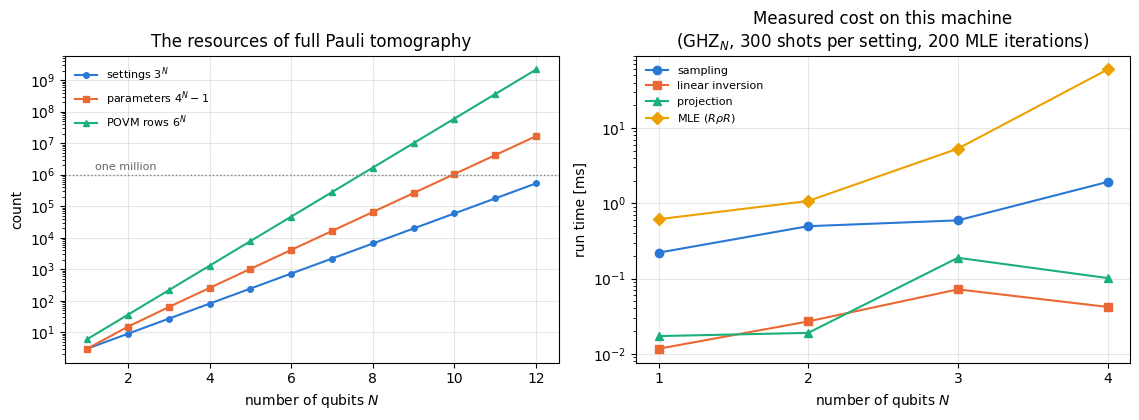

In [37]:
# ==============================================================================
# FIGURE: the exponential wall -- resource counts and measured runtime
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
Nax = np.arange(1, 13)
for k, (lab, vals) in enumerate((("settings $3^N$", 3.0 ** Nax), ("parameters $4^N-1$", 4.0 ** Nax - 1),
                                 ("POVM rows $6^N$", 6.0 ** Nax))):
    axes[0].semilogy(Nax, vals, MARKERS[k] + "-", color=PALETTE[k], ms=4, label=lab)
axes[0].axhline(1e6, color="0.5", ls=":", lw=1)
axes[0].text(1.2, 1.4e6, "one million", fontsize=8, color="0.4")
axes[0].set_xlabel("number of qubits $N$"); axes[0].set_ylabel("count")
axes[0].set_title("The resources of full Pauli tomography"); axes[0].legend(fontsize=8)

ns = np.array([r[0] for r in cost_rows])
for k, (lab, col) in enumerate((("sampling", 4), ("linear inversion", 5), ("projection", 6), (r"MLE ($R\rho R$)", 7))):
    axes[1].semilogy(ns, [r[col] * 1e3 for r in cost_rows], MARKERS[k] + "-", color=PALETTE[k], label=lab)
axes[1].set_xticks(ns); axes[1].set_xlabel("number of qubits $N$"); axes[1].set_ylabel("run time [ms]")
axes[1].set_title(f"Measured cost on this machine\n(GHZ$_N$, {M_COST} shots per setting, {MLE_IT_COST} MLE iterations)")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Every stage grows exponentially, and the maximum-likelihood iteration — $O(6^N)$ POVM terms times $O(4^N)$ matrix entries per
iteration — grows fastest. At these tiny sizes the measured factor per added qubit is still well below the asymptotic
$24=6\times4$ and varies from run to run, because fixed overheads (dispatch, the $O(d^3)$ pieces) still contribute; it approaches
$24$ only as $N$ grows. Extrapolating the measured $N=4$
time with the asymptotic factor puts a single $N=6$ reconstruction at tens of seconds and $N=8$ at hours on this machine, and that
is *after* collecting a data set of $3^{8}M\approx7\cdot10^6$ shots at $M=1000$ shots per setting.
A real example of that scale: the eight-ion W-state tomography of Häffner et al. (2005) measured all $3^8=6561$ bases with $100$
repetitions each, $656\,100$ runs and ten hours of measurement, and reconstructed $\rho$ with an iterative maximum-likelihood
procedure of the kind derived in Section 13.

### 18.3 Alternatives to full tomography

The way out is to notice that we almost never want *all* $4^N$ numbers. We usually want a handful of observables (energies,
correlators, a fidelity with one target state, an entanglement witness). Estimating $K$ specific observables should not cost
$4^N$ parameters' worth of data — and it does not. **Randomised measurements / classical shadows** replace the deterministic sweep
over $3^N$ settings by *random* single-qubit bases, and replace the reconstruction of $\rho$ by an unbiased estimator of any chosen
observable built directly from the snapshots. The number of snapshots needed grows with $\log K$ and with $3^{k}$ for $k$-local
observables — independently of $N$. That is the subject of the next notebook,
[24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb), which also compares the two approaches
at an *equal shot budget* on the very states we reconstructed here.

Two other standard escapes are worth naming: **compressed sensing** tomography, which exploits the fact that interesting states are
nearly low-rank and reconstructs them from $O(rd\log^2d)$ random Pauli expectations (Gross et al. 2010); and **tensor-network
tomography**, which parametrises $\rho$ as a matrix-product operator and therefore has only $O(N)$ parameters
(Baumgratz et al. 2013). Both start from the same linear model of
Section 6 — they just replace "solve for all $4^N$ coordinates" by "solve inside a smaller, physically motivated set".

## 19. Key takeaways

* **Tomography is linear regression with a positivity constraint.** The Pauli expansion $\rho=2^{-N}\sum_Pr_PP$ turns the state into
  a vector $r$ of $4^N-1$ real numbers; the Born rule, Eq. (3), turns the measurement into a linear map $p=Ar$ with a design matrix
  that is the $N$-th Kronecker power of one $6\times4$ block.
* **Ordinary least squares equals direct Pauli inversion**, Eq. (8): estimate each $\langle P\rangle$ by averaging the measured signs
  over all $3^{N-w(P)}$ compatible settings. The Gram matrix is diagonal, so nothing has to be inverted and the estimator is
  matrix-free at any $N$. Its error is $\mathrm{Var}(\hat r_P)=(1-r_P^2)/(M3^{N-w})$ — high-weight strings are the expensive ones.
* **Linear inversion is unbiased but unphysical.** For a state on the boundary (any pure state) the estimate has a negative
  eigenvalue in essentially every experiment, at every shot number. Never report it as a density matrix.
* **Projection** onto the physical set (Smolin–Gambetta–Smith) is one `eigh` plus a projection of the eigenvalues onto the simplex,
  and it never increases the 2-norm error. **Maximum likelihood** attacks the constrained problem directly: the concave
  log-likelihood of Eq. (11) is maximised by the extremal equation $\tilde R\rho\tilde R=\rho$, solved either by the $R\rho R$
  iteration (fast, monitor it; use the diluted form when it misbehaves) or by `jax.grad`+Adam on $\rho=T^\dagger T/\mathrm{Tr}(T^\dagger T)$
  (slower per step, but works for any cost function). Both find the same state.
* **Enforcing positivity is what matters most**, but for states near the boundary *how* you enforce it matters too: on our zoo the
  projection more than halved the trace distance of linear inversion for the three-qubit pure states, and maximum likelihood halved
  it again. For states well inside the physical set all three estimators coincide. Both physical estimators are **biased** near a generic boundary: they
  under-report fidelity and purity and produce rank-deficient estimates. Stabiliser states are the exception: their
  deterministic outcomes pin the maximum-likelihood estimate to the rank-one manifold, where for $\vert\Phi^+\rangle$ its infidelity
  falls like $13/(48M)$, against $M^{-1/2}$ for a generic pure state. Calibrate the bias by simulation at your shot budget, and quote
  **bootstrap** error bars.
* All errors scale as $1/\sqrt M$ in trace distance; the fidelity with a pure target is a *linear* functional and is therefore
  estimated without bias by linear inversion — one of the few things raw linear inversion is good for.
* **The method dies exponentially**: $3^N$ settings, $4^N$ parameters, $6^N$ likelihood terms, and a total shot budget that grows
  like $5^N$ at fixed Frobenius error, Eq. (17). Beyond $N\approx8$–$10$ one switches
  to randomised measurements (classical shadows), compressed sensing, or tensor-network ansätze.
* **Implementation**: one einsum per concept (`"ja,ab,jb->j"` for all Born probabilities, `"j,ja,jb->ab"` for $R$, `"ps,bs->pb"` for
  the Pauli estimates), `vmap` over settings / shots / data sets / bootstrap resamples, `lax.scan` for the iteration, and a validation
  ladder — exact probabilities, two derivations of the same estimator, monotone likelihood, two independent optimisers, and a wrong
  control for every statistical test — in which each check is built so that it can fail.

## 20. Exercises

1. ★ **Read the design matrix.** Using `design_matrix(1)`, write down by hand the least-squares estimate of $\langle Z\rangle$ for
   one qubit in terms of the six frequencies, and verify that it equals $f(0\vert Z)-f(1\vert Z)$, i.e. that the settings $X$ and $Y$
   contribute nothing to it. Then explain in one sentence why the Gram matrix of Eq. (7) is diagonal.
2. ★ **How many shots?** Use Eq. (9) to compute how many shots per setting are needed so that every weight-$N$ Pauli expectation of a
   three-qubit GHZ state is determined with a standard error of $0.01$. Check your answer with `linear_inversion` and a Monte-Carlo
   run of 200 experiments.
3. ★★ **A different informationally complete measurement (extend the code).** Replace the $3^N$ Pauli settings by the *tetrahedral*
   single-qubit POVM: four sub-normalised rank-one elements $\tfrac14(\mathbb 1+\hat n_i\cdot\vec\sigma)$ with the $\hat n_i$ pointing
   to the vertices of a regular tetrahedron. Build the new $4^N\times4^N$ design matrix, check that it is invertible, and compare the
   reconstruction error at the same *total* number of shots $T$ with the Pauli scheme. Which one is better, and why? Check value
   for $N=1$: $\mathbb E\Vert\hat\rho-\rho\Vert_F^2=(9-3\vert\vec r\vert^2)/(2T)$ (Pauli) and $(9-\vert\vec r\vert^2)/(2T)$
   (tetrahedral), i.e. equal for $\rho=\mathbb 1/2$ and $3/T$ versus $4/T$ for every pure state. (`setting_probs`
   cannot help here — a tetrahedral POVM is not a projective measurement, so compute $p_i=\mathrm{Tr}(\rho\,\Pi_i)$
   directly, as `povm_probs` does, and sample from the $4^N$ probabilities in one `categorical` draw.)
4. ★★ **Weighted least squares done right (extend the code).** Our `weighted_least_squares` uses a diagonal weight matrix, but
   Eq. (5) says the multinomial covariance is block-diagonal with full blocks. Evaluate the Gauss-Markov bound
   $\mathrm{Cov}=(A^{\mathsf T}C^{-1}A)^{-1}$ exactly and compare it with OLS and with diagonal WLS on the three states of
   Section 9. Two traps: each block of $C$ is singular because the frequencies of a setting sum to one (drop one outcome per
   setting and work with the remaining $2^N-1$), and for the Bell state further directions are singular because some probabilities
   are exactly zero (regularise $p\to\max(p,\eta)$ and take $\eta\to0$). A naive `pinv` of the full block gives a "bound" that is
   *worse* than OLS, which is how you know you have fallen into the first trap. Target answers at $M=100$: the bound lies
   $5.4\%$ below OLS for the Bell state, $1.0\%$ for the Werner state and $5.6\%$ for the random mixed state.
5. ★★ **Convergence of the diluted iteration.** For the Bell data set of Section 13, plot the number of iterations needed to reach
   $\lVert\tilde R\rho-\rho\rVert<10^{-6}$ as a function of $\epsilon\in\{0.05,0.1,0.2,0.5,1,2,5,10\}$ and of the plain step, and
   check at each $\epsilon$ whether $\log L$ ever decreases. You will find that the cost falls roughly like $1/\epsilon$ for small
   $\epsilon$, saturates at the plain step, and that monotonicity is **never** violated for these data — the guarantee of Eq. (15)
   buys you insurance you do not need here. Does the picture change at $M=50$ shots per setting?
6. ★★ **Priors and regularisation (extend the code).** Add a term $+\alpha\,\mathrm{Tr}(\rho\log\rho)$ (maximum-entropy prior) to the
   cost of `mle_gradient` and study how $\alpha$ trades the fidelity bias of Section 17 against the variance. This is a *maximum a
   posteriori* estimator; it does not fit the $R\rho R$ fixed-point structure, which relies on $\log L$ being a sum of logarithms of
   *linear* functions of $\rho$ — which is exactly why the gradient route is worth having. (Use
   `jnp.clip(jnp.linalg.eigvalsh(rho), 1e-12, None)` inside the entropy so the gradient stays finite.)
7. ★★★ **Tomography of a noisy circuit (physics).** Prepare a three-qubit GHZ state with the engine's gate sequence, apply dephasing
   of strength $p$ to every qubit, reconstruct the state with MLE from $M=2000$ shots per setting, and plot the reconstructed
   GHZ coherence $\vert\rho_{0\ldots0,1\ldots1}\vert$ and the negativity of the $1\vert23$ bipartition as functions of $p$. Compare
   with the exact values and with the bootstrap error bars, and determine the largest $p$ at which tomography still sees
   entanglement. (`negativity` accepts the reconstructed $8\times8$ matrix directly as well as a density tensor; the qubit list
   `[0]` selects the $1\vert23$ cut. For this state the exact negativity equals the coherence $\vert\rho_{0\ldots0,1\ldots1}\vert$.)
8. ★★★ **Rank-restricted tomography (extend the code).** Modify `mle_gradient` so that $T$ has shape $(k,d)$ with $k\ll d$, which
   constrains $\rho$ to rank $\le k$. Reconstruct a two-qubit pure state with $k=1$ and compare the number of shots needed for a
   given fidelity with the unconstrained MLE. This is the simplest form of compressed-sensing tomography: fewer parameters, fewer
   shots — at the price of an assumption about the state.

## References

* Z. Hradil, *Quantum-state estimation*, Phys. Rev. A **55**, R1561 (1997) — maximum-likelihood tomography, the positivity objection
  to linear inversion, and the extremal equation behind the $R\rho R$ iteration.
* D. F. V. James, P. G. Kwiat, W. J. Munro and A. G. White, *Measurement of qubits*, Phys. Rev. A **64**, 052312 (2001) — the
  standard reference for two-qubit tomography (with $4^n$ product projectors, $16$ for two qubits, rather than the $3^N$
  six-outcome Pauli settings used here) and the source of the parametrisation $T^\dagger T/\mathrm{Tr}(T^\dagger T)$ of Section 14.
* J. Řeháček, Z. Hradil, E. Knill and A. I. Lvovsky, *Diluted maximum-likelihood algorithm for quantum tomography*,
  Phys. Rev. A **75**, 042108 (2007) — the name "$R\rho R$ algorithm", a counterexample to its convergence, and the diluted iteration
  of Eq. (15) with its monotonicity for small $\epsilon$.
* H. Häffner, W. Hänsel, C. F. Roos, J. Benhelm, D. Chek-al-kar, M. Chwalla, T. Körber, U. D. Rapol, M. Riebe, P. O. Schmidt,
  C. Becher, O. Gühne, W. Dür and R. Blatt, *Scalable multiparticle entanglement of trapped ions*, Nature **438**, 643 (2005) —
  eight-qubit W-state tomography with $3^8$ bases (Section 18.2).
* J. A. Smolin, J. M. Gambetta and G. Smith, *Efficient method for computing the maximum-likelihood quantum state from measurements
  with additive Gaussian noise*, Phys. Rev. Lett. **108**, 070502 (2012) — the eigenvalue-truncation projection of Section 11.
* D. H. Mahler, L. A. Rozema, A. Darabi, C. Ferrie, R. Blume-Kohout and A. M. Steinberg, *Adaptive quantum state tomography improves
  accuracy quadratically*, Phys. Rev. Lett. **111**, 183601 (2013) — why the infidelity of a *generic* nearly pure state estimated
  from fixed Pauli settings falls only like $M^{-1/2}$, and how one adaptive step restores $M^{-1}$ (Sections 15 and 17).
* M. G. A. Paris and J. Řeháček (eds.), *Quantum State Estimation*, Lecture Notes in Physics **649** (Springer, 2004) — the standard
  collection of review articles on the whole subject.
* D. Gross, Y.-K. Liu, S. T. Flammia, S. Becker and J. Eisert, *Quantum state tomography via compressed sensing*,
  Phys. Rev. Lett. **105**, 150401 (2010) — the compressed-sensing route mentioned in Section 18.3.
* T. Baumgratz, D. Gross, M. Cramer and M. B. Plenio, *Scalable reconstruction of density matrices*,
  Phys. Rev. Lett. **111**, 020401 (2013) — matrix-product-operator (tensor-network) tomography, also Section 18.3.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000) — density
  matrices, the Bloch/Pauli expansion, fidelity and trace distance (Ch. 2, 8 and 9).
* H.-Y. Huang, R. Kueng and J. Preskill, *Predicting many properties of a quantum system from very few measurements*,
  Nature Physics **16**, 1050 (2020) — classical shadows, the subject of the next notebook.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/